In [338]:
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv("hotel_bookings.csv")

df.shape

(119390, 32)

In [3]:
df.shape

(119390, 32)

In [4]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [5]:
df.sample(5)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
88264,City Hotel,0,180,2016,May,19,2,1,1,2,...,No Deposit,3.0,NaN,0,Transient-Party,100.00,0,1,Check-Out,2016-05-04
74512,City Hotel,1,325,2015,September,37,7,1,1,2,...,Non Refund,1.0,NaN,0,Contract,62.00,0,0,Canceled,2015-01-01
102435,City Hotel,0,67,2016,November,48,25,2,2,2,...,No Deposit,28.0,NaN,0,Transient,75.00,0,0,Check-Out,2016-11-29
115427,City Hotel,0,200,2017,June,26,29,2,5,2,...,No Deposit,14.0,NaN,0,Transient,91.93,0,1,Check-Out,2017-07-06
17180,Resort Hotel,0,13,2015,September,40,28,1,0,2,...,No Deposit,241.0,NaN,0,Transient,56.98,0,1,Check-Out,2015-09-29


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [7]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

In [8]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [9]:
# Numerical Features
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Categorical Features
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

print("Number of Numerical Features :", len(numerical_columns))
print("Number of Categorical Features :", len(categorical_columns))

print("\nNumerical Features")
print(numerical_columns)

print("\nCategorical Features")
print(categorical_columns)

Number of Numerical Features : 20
Number of Categorical Features : 12

Numerical Features
['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical Features
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


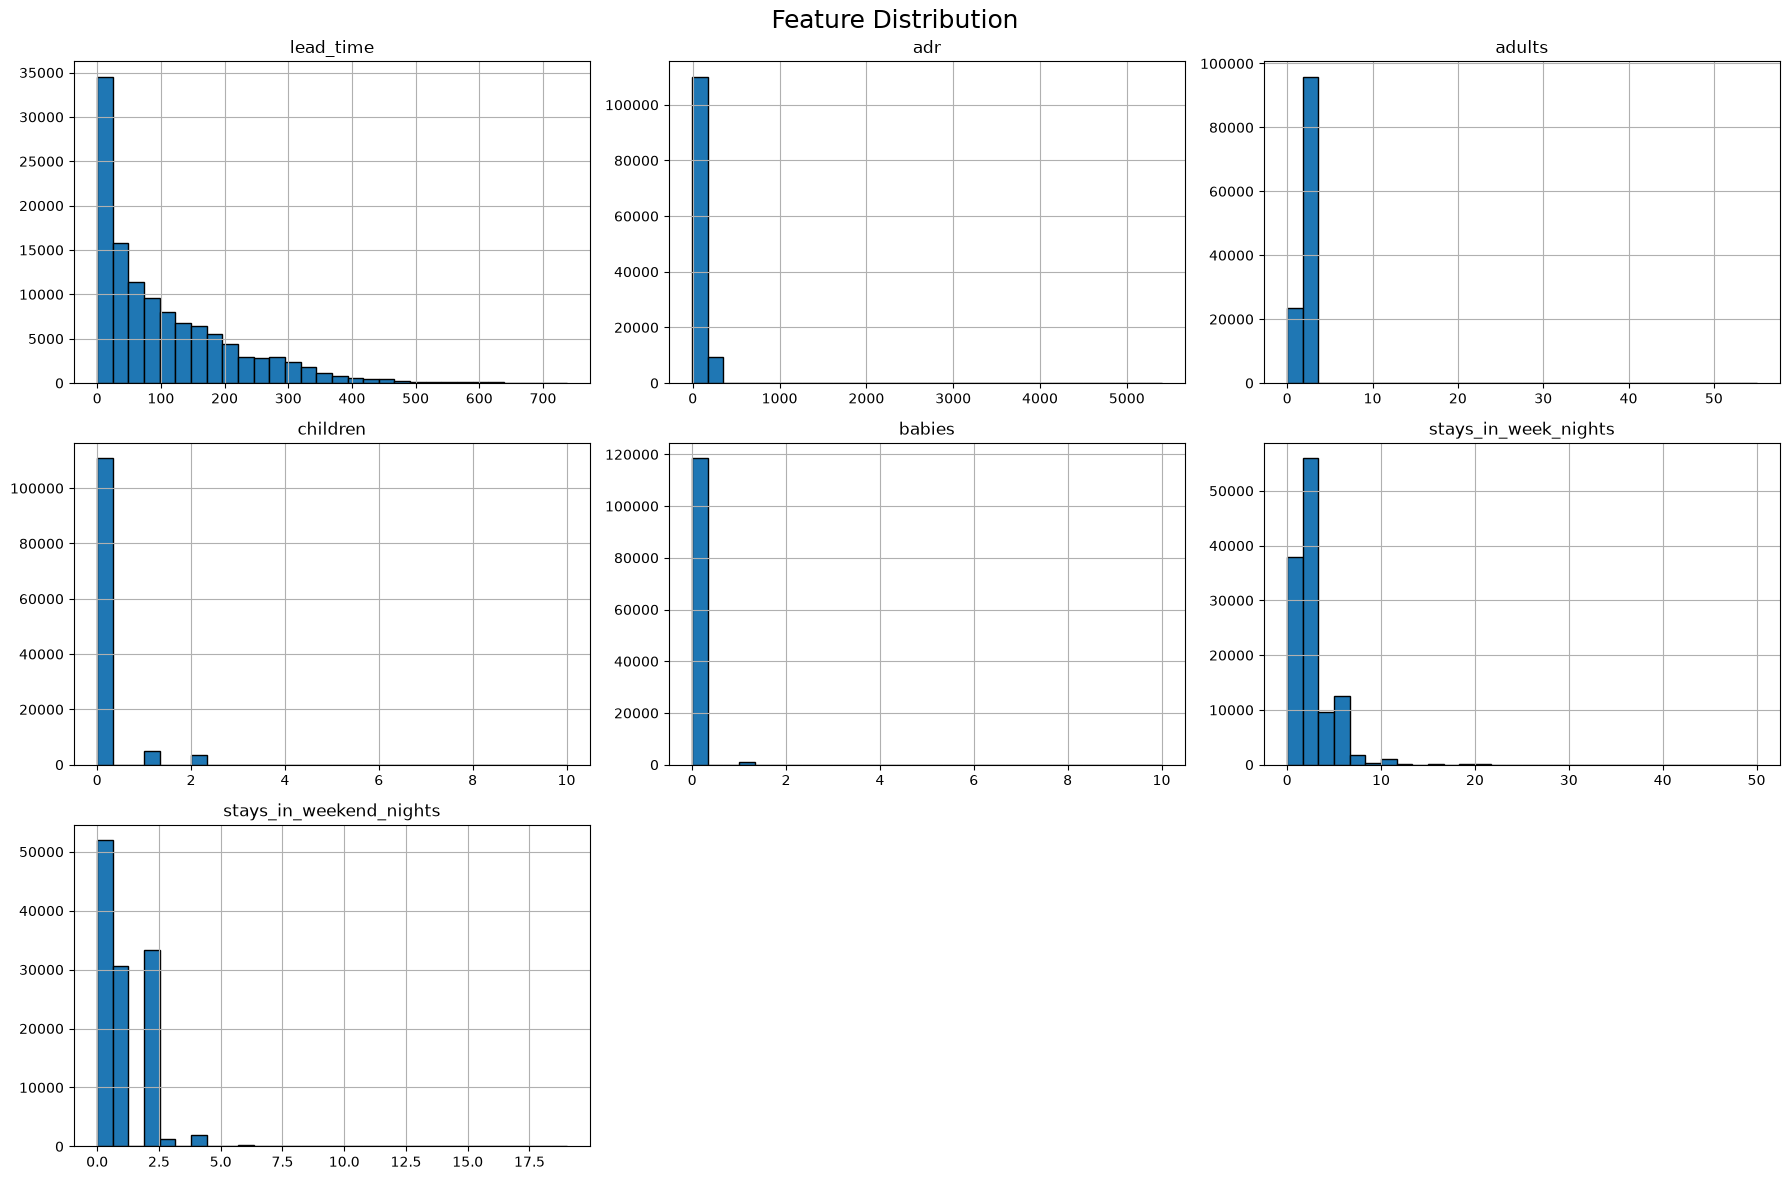

In [10]:
# feature distribution

numerical_features = [
    "lead_time",
    "adr",
    "adults",
    "children",
    "babies",
    "stays_in_week_nights",
    "stays_in_weekend_nights"
]

df[numerical_features].hist(
    figsize=(18,12),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Feature Distribution", fontsize=18)

plt.tight_layout()

plt.show()

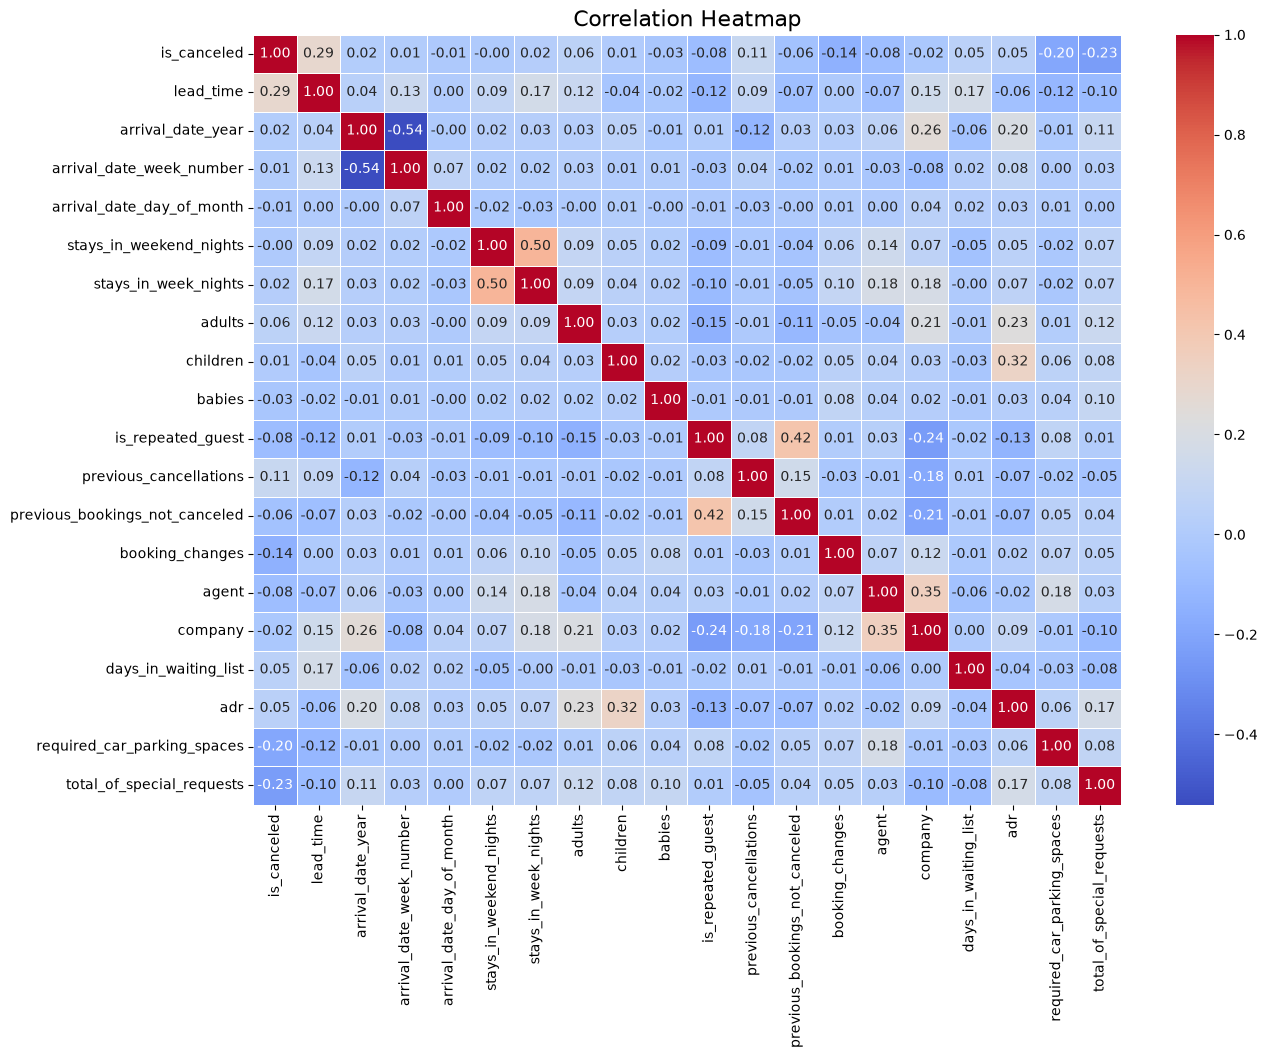

In [11]:
#correlation heatmap

plt.figure(figsize=(14,10))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

In [12]:
feature_description = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

feature_description

,Feature,Data Type,Missing Values,Unique Values
0,hotel,str,0,2
1,is_canceled,int64,0,2
2,lead_time,int64,0,479
3,arrival_date_year,int64,0,3
4,arrival_date_month,str,0,12
5,arrival_date_week_number,int64,0,53
6,arrival_date_day_of_month,int64,0,31
7,stays_in_weekend_nights,int64,0,17
8,stays_in_week_nights,int64,0,35
9,adults,int64,0,14


In [13]:
print("="*40)
print("Dataset Shape")
print("="*40)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Dataset Shape
Rows    : 119390
Columns : 32


In [14]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": round(df.isnull().mean() * 100, 2)
})

missing = missing[missing["Missing Values"] > 0]
missing.sort_values("Missing Values", ascending=False)

,Missing Values,Percentage (%)
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


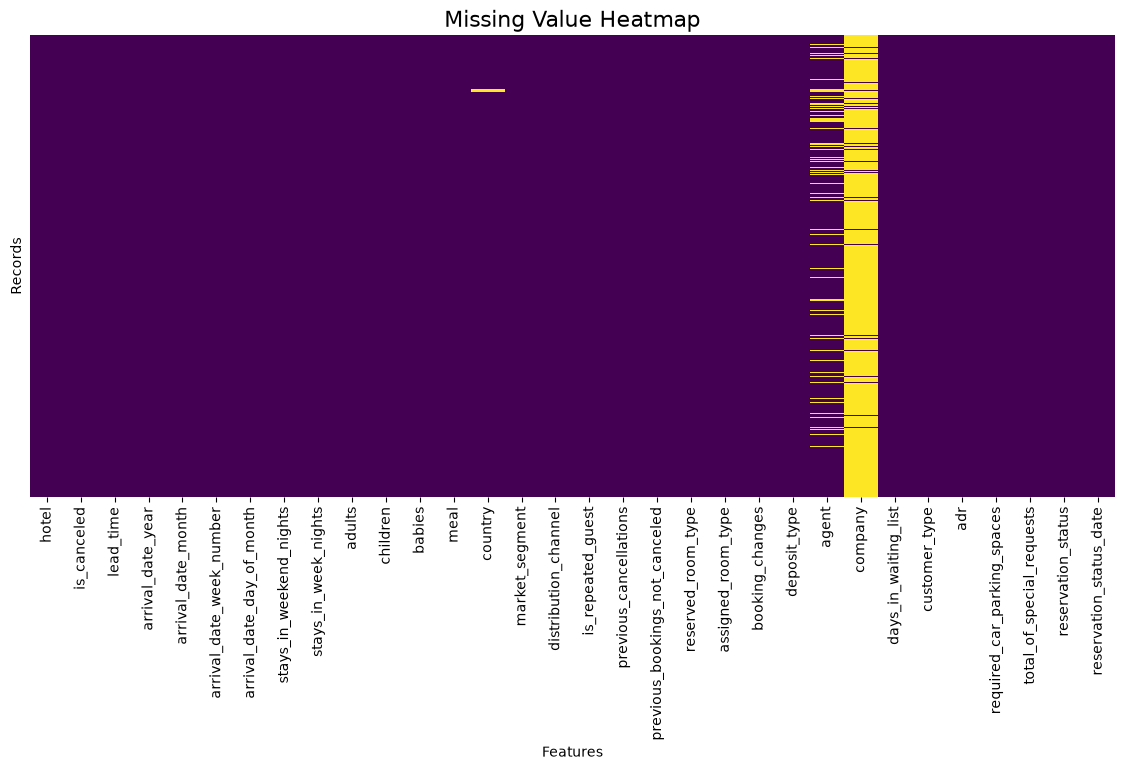

In [15]:
plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis",
    yticklabels=False
)

plt.title("Missing Value Heatmap", fontsize=16)
plt.xlabel("Features")
plt.ylabel("Records")
plt.show()

In [16]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 31994


In [17]:
df.describe(include='object').T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


In [18]:
# summary statis tics
#The descriptive statistics provide an overview of the numerical features, including count, mean, standard deviation, minimum, maximum, and quartiles.

summary_statistics = df.describe().T
summary_statistics.style.background_gradient(cmap="Blues")

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.000000,0.370416,0.482918,0.000000,0.000000,0.000000,1.000000,1.000000
lead_time,119390.000000,104.011416,106.863097,0.000000,18.000000,69.000000,160.000000,737.000000
arrival_date_year,119390.000000,2016.156554,0.707476,2015.000000,2016.000000,2016.000000,2017.000000,2017.000000
arrival_date_week_number,119390.000000,27.165173,13.605138,1.000000,16.000000,28.000000,38.000000,53.000000
arrival_date_day_of_month,119390.000000,15.798241,8.780829,1.000000,8.000000,16.000000,23.000000,31.000000
stays_in_weekend_nights,119390.000000,0.927599,0.998613,0.000000,0.000000,1.000000,2.000000,19.000000
stays_in_week_nights,119390.000000,2.500302,1.908286,0.000000,1.000000,2.000000,3.000000,50.000000
adults,119390.000000,1.856403,0.579261,0.000000,2.000000,2.000000,2.000000,55.000000
children,119386.000000,0.103890,0.398561,0.000000,0.000000,0.000000,0.000000,10.000000
babies,119390.000000,0.007949,0.097436,0.000000,0.000000,0.000000,0.000000,10.000000


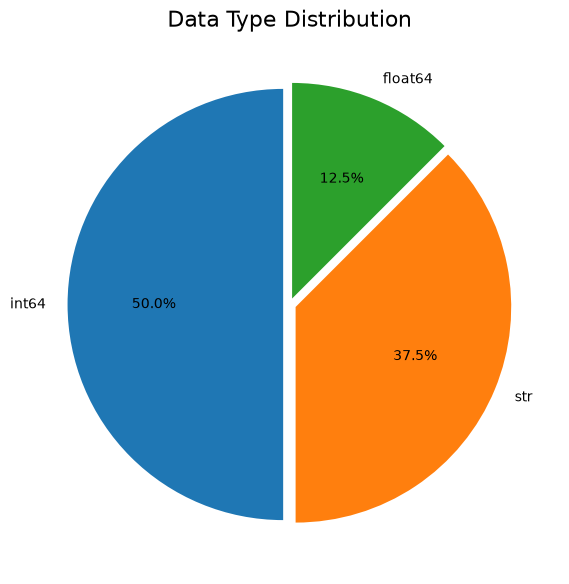

In [19]:
#data type distribution

dtype_counts = df.dtypes.value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    dtype_counts,
    labels=dtype_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03]*len(dtype_counts)
)

plt.title("Data Type Distribution", fontsize=16)

plt.show()


# Phase 1 Conclusion

### Key Findings

- The dataset contains **119,390 booking records** and **32 features**.
- Features include numerical, categorical, and date-related information.
- Missing values were identified in selected columns such as **children**, **country**, **agent**, and **company**.
- No data preprocessing has been performed at this stage.
- The dataset structure has been thoroughly examined and is ready for cleaning and transformation.

### Next Phase

The next phase focuses on **Data Preprocessing**, where missing values, duplicates, incorrect data types, invalid values, outliers, encoding, scaling, and feature engineering will be performed.

In [20]:
# Create a working copy

clean_df = df.copy()

print("Shape :", clean_df.shape)

Shape : (119390, 32)


In [21]:
print("="*50)
print("DATASET BEFORE PREPROCESSING")
print("="*50)

print("Rows :", clean_df.shape[0])
print("Columns :", clean_df.shape[1])
print("Missing Values :", clean_df.isnull().sum().sum())
print("Duplicate Rows :", clean_df.duplicated().sum())

DATASET BEFORE PREPROCESSING
Rows : 119390
Columns : 32
Missing Values : 129425
Duplicate Rows : 31994


## Missing Value Analysis

In [22]:
missing = pd.DataFrame({
    "Missing Values": clean_df.isnull().sum(),
    "Percentage (%)": round(clean_df.isnull().mean()*100,2)
})

missing = missing[missing["Missing Values"]>0]

missing.sort_values("Missing Values",ascending=False)

,Missing Values,Percentage (%)
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


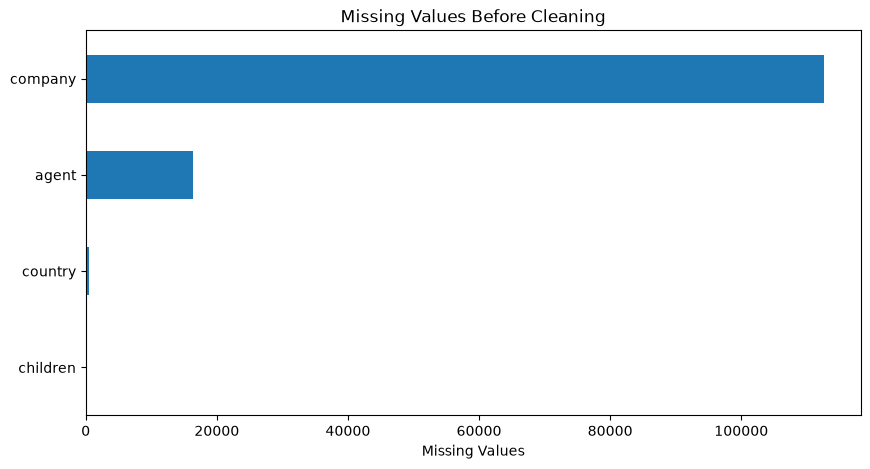

In [23]:
# before leaning

plt.figure(figsize=(10,5))

missing["Missing Values"].sort_values().plot(kind="barh")
plt.title("Missing Values Before Cleaning")
plt.xlabel("Missing Values")
plt.show()

In [24]:
# Fill missing values

clean_df["children"] = clean_df["children"].fillna(clean_df["children"].median())

clean_df["country"] = clean_df["country"].fillna(clean_df["country"].mode()[0])

clean_df["agent"] = clean_df["agent"].fillna(0)

clean_df["company"] = clean_df["company"].fillna(0)

In [25]:
clean_df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [26]:
comparison = pd.DataFrame({

"Before":df.isnull().sum(),

"After":clean_df.isnull().sum()

})

comparison

,Before,After
hotel,0,0
is_canceled,0,0
lead_time,0,0
arrival_date_year,0,0
arrival_date_month,0,0
arrival_date_week_number,0,0
arrival_date_day_of_month,0,0
stays_in_weekend_nights,0,0
stays_in_week_nights,0,0
adults,0,0


### Missing Value 

The dataset contained missing values in the **children**, **country**, **agent**, and **company** columns.

- **children:** Missing values were replaced with the median because it is a numerical feature and the median is robust to outliers.
- **country:** Missing values were replaced with the mode because it is a categorical feature.
- **agent:** Missing values were replaced with `0`, indicating that no travel agent information was available.
- **company:** Missing values were replaced with `0`, indicating that no company booking information was available.

After preprocessing, all missing values were successfully removed from the dataset.


In [27]:
duplicate_before = clean_df.duplicated().sum()
print("Duplicate Records Before Removal :", duplicate_before)

Duplicate Records Before Removal : 32013


In [28]:
clean_df = clean_df.drop_duplicates()

print("Duplicate Records Removed Successfully")

Duplicate Records Removed Successfully


In [29]:
duplicate_after = clean_df.duplicated().sum()

print("Duplicate Records After Removal :", duplicate_after)

Duplicate Records After Removal : 0


In [30]:
duplicate_comparison = pd.DataFrame({
    "Before Removal": [duplicate_before],
    "After Removal": [duplicate_after]
})

duplicate_comparison

,Before Removal,After Removal
0,32013,0


In [31]:
print("Shape Before Removing Duplicates :", df.shape)
print("Shape After Removing Duplicates  :", clean_df.shape)

Shape Before Removing Duplicates : (119390, 32)
Shape After Removing Duplicates  : (87377, 32)


In [32]:
# convert incorrect datatypes

In [33]:
clean_df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [34]:
clean_df["reservation_status_date"].dtype

<StringDtype(storage='python', na_value=nan)>

In [35]:
# Convert reservation_status_date to datetime
clean_df["reservation_status_date"] = pd.to_datetime(
    clean_df["reservation_status_date"]
)

print("Conversion Successful")

Conversion Successful


In [36]:
clean_df["reservation_status_date"].dtype

dtype('<M8[us]')

In [37]:
clean_df["reservation_year"] = clean_df["reservation_status_date"].dt.year
clean_df["reservation_month"] = clean_df["reservation_status_date"].dt.month
clean_df["reservation_day"] = clean_df["reservation_status_date"].dt.day

clean_df[
    [
        "reservation_status_date",
        "reservation_year",
        "reservation_month",
        "reservation_day"
    ]
].head()

,reservation_status_date,reservation_year,reservation_month,reservation_day
0,2015-07-01,2015,7,1
1,2015-07-01,2015,7,1
2,2015-07-02,2015,7,2
3,2015-07-02,2015,7,2
4,2015-07-03,2015,7,3


In [38]:
clean_df.dtypes

hotel                                        str
is_canceled                                int64
lead_time                                  int64
arrival_date_year                          int64
arrival_date_month                           str
arrival_date_week_number                   int64
arrival_date_day_of_month                  int64
stays_in_weekend_nights                    int64
stays_in_week_nights                       int64
adults                                     int64
children                                 float64
babies                                     int64
meal                                         str
country                                      str
market_segment                               str
distribution_channel                         str
is_repeated_guest                          int64
previous_cancellations                     int64
previous_bookings_not_canceled             int64
reserved_room_type                           str
assigned_room_type  

## Step 4 – Invalid and Inconsistent Value Detection

In [39]:
invalid_records = clean_df[
    (clean_df["adults"] == 0) &
    (clean_df["children"] == 0) &
    (clean_df["babies"] == 0)
]

print("Invalid Records :", len(invalid_records))

Invalid Records : 166


In [40]:
# remove invalid records

clean_df = clean_df[
    ~(
        (clean_df["adults"] == 0) &
        (clean_df["children"] == 0) &
        (clean_df["babies"] == 0)
    )
]

print("Invalid Records Removed Successfully")

Invalid Records Removed Successfully


In [41]:
clean_df[
    (clean_df["adults"] == 0) &
    (clean_df["children"] == 0) &
    (clean_df["babies"] == 0)
]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,reservation_year,reservation_month,reservation_day


In [42]:
invalid_records = clean_df[
    (clean_df["adults"] == 0) &
    (clean_df["children"] == 0) &
    (clean_df["babies"] == 0)
]

print("Invalid Records :", len(invalid_records))

Invalid Records : 0


In [43]:
clean_df.to_csv("hotel_bookings_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## Step 5 – Outlier Detection using Interquartile Range (IQR)

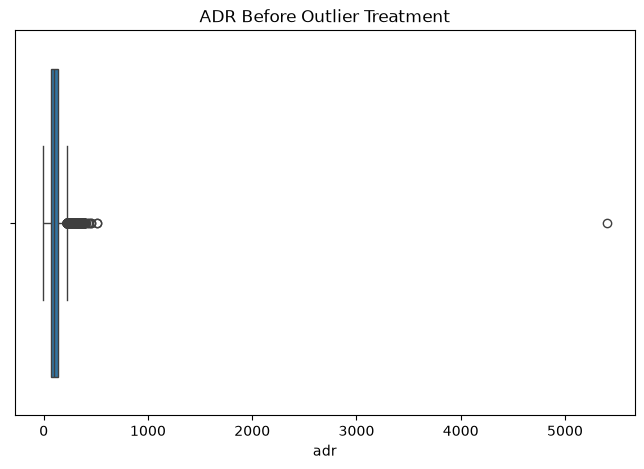

In [44]:
# before outlier

plt.figure(figsize=(8,5))
sns.boxplot(x=clean_df["adr"])
plt.title("ADR Before Outlier Treatment")
plt.show()

In [45]:
# calculate outlier

Q1 = clean_df["adr"].quantile(0.25)

Q3 = clean_df["adr"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower Limit :", lower_limit)
print("Upper Limit :", upper_limit)

Q1 : 72.25
Q3 : 134.1
IQR : 61.849999999999994
Lower Limit : -20.52499999999999
Upper Limit : 226.875


In [46]:
# count outliers

outliers = clean_df[
    (clean_df["adr"] < lower_limit) |
    (clean_df["adr"] > upper_limit)
]

print("Number of Outliers :", len(outliers))

Number of Outliers : 2506


In [47]:
before_iqr = clean_df.shape

print("Dataset Shape Before :", before_iqr)

Dataset Shape Before : (87211, 35)


In [48]:
# remove outliers

clean_df = clean_df[
    (clean_df["adr"] >= lower_limit) &
    (clean_df["adr"] <= upper_limit)
]

In [49]:
after_iqr = clean_df.shape

print("Dataset Shape After :", after_iqr)

Dataset Shape After : (84705, 35)


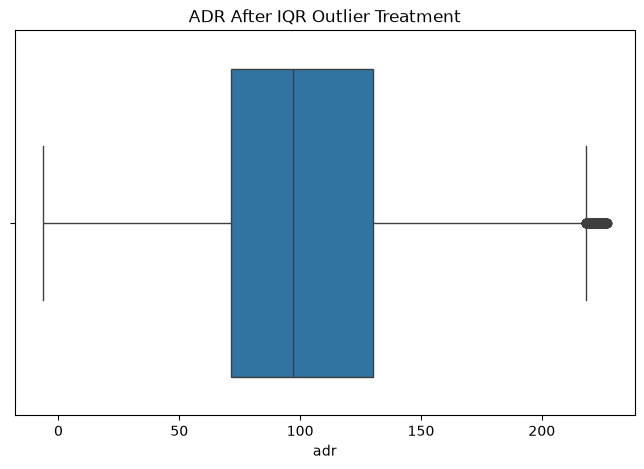

In [50]:
# boxplot after

plt.figure(figsize=(8,5))
sns.boxplot(x=clean_df["adr"])
plt.title("ADR After IQR Outlier Treatment")
plt.show()

In [51]:
comparison = pd.DataFrame({
    "Before": [before_iqr[0]],
    "After": [after_iqr[0]]
})

comparison

,Before,After
0,87211,84705


## Step 6 – Outlier Detection using Z-Score


In [52]:
from scipy.stats import zscore

clean_df["adr_zscore"] = zscore(clean_df["adr"])
clean_df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,reservation_year,reservation_month,reservation_day,adr_zscore
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,2015,7,1,-2.264472
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,2015,7,1,-2.264472
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,2015,7,2,-0.598424
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,2015,7,2,-0.598424
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,2015,7,3,-0.087503


In [53]:
# count z-score outliers

z_outliers = clean_df[
    clean_df["adr_zscore"].abs() > 3
]

print("Number of Z-Score Outliers :", len(z_outliers))

Number of Z-Score Outliers : 0


In [54]:
# remove temporary column

clean_df.drop(columns="adr_zscore", inplace=True)

In [55]:
print("Final Dataset Shape :", clean_df.shape)

Final Dataset Shape : (84705, 35)


In [56]:
#fea_eng_df = clean_df.copy()

#feature_df = clean_df.copy()


#normal_df = clean_df.copy()

#standard_df = clean_df.copy()

#log_df = clean_df.copy()

#boxcox_df = clean_df.copy()

In [57]:
#print(fea_eng_df["lead_time"].min())
#print(fea_eng_df["lead_time"].max())

## Step 7 – Label Encoding

Label Encoding converts categorical variables into numerical values by assigning a unique integer to each category.


In [58]:
from sklearn.preprocessing import LabelEncoder

In [59]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [60]:
label_encoder = LabelEncoder()

In [61]:
categorical_columns = clean_df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'assigned_room_type',
       'deposit_type', 'customer_type', 'reservation_status'],
      dtype='str')


In [62]:
label_columns = [
    "hotel",
    "deposit_type",
    "customer_type",
    "reservation_status"
]

for col in label_columns:
    clean_df[col] = label_encoder.fit_transform(clean_df[col])

In [63]:
clean_df[label_columns].head()

,hotel,deposit_type,customer_type,reservation_status
0,1,0,2,1
1,1,0,2,1
2,1,0,2,1
3,1,0,2,1
4,1,0,2,1


Original Column	Encoded Values (example)
hotel	Resort Hotel → 0, City Hotel → 1
deposit_type	No Deposit → 0, Non Refund → 1, Refundable → 2 (order depends on the encoder)
customer_type	Contract → 0, Group → 1, Transient → 2, Transient-Party → 3 (example mapping)
reservation_status	Check-Out → 1, Canceled → 0, No-Show → 2 (example mapping)

In [64]:
for col in label_columns:
    le = LabelEncoder()
    le.fit(df[col])

    mapping = pd.DataFrame({
        "Original Value": le.classes_,
        "Encoded Value": range(len(le.classes_))
    })

    print(f"\n===== {col.upper()} =====")
    display(mapping)


===== HOTEL =====


,Original Value,Encoded Value
0,City Hotel,0
1,Resort Hotel,1



===== DEPOSIT_TYPE =====


,Original Value,Encoded Value
0,No Deposit,0
1,Non Refund,1
2,Refundable,2



===== CUSTOMER_TYPE =====


,Original Value,Encoded Value
0,Contract,0
1,Group,1
2,Transient,2
3,Transient-Party,3



===== RESERVATION_STATUS =====


,Original Value,Encoded Value
0,Canceled,0
1,Check-Out,1
2,No-Show,2


## Step 8 – One-Hot Encoding

### Objective

One-Hot Encoding converts nominal categorical variables into multiple binary (0 or 1) columns.

Unlike Label Encoding, it does not assign numerical order to categories, making it suitable for variables where the categories have no inherent ranking.

In [65]:
# check categories before encoding
onehot_columns = [
    "meal",
    "market_segment",
    "distribution_channel"
]

for col in onehot_columns:
    print(f"\n{col}")
    print(clean_df[col].value_counts())


meal
meal
BB           66369
SC            9391
HB            8193
Undefined      456
FB             296
Name: count, dtype: int64

market_segment
market_segment
Online TA        49768
Offline TA/TO    13801
Direct           11131
Groups            4895
Corporate         4190
Complementary      692
Aviation           226
Undefined            2
Name: count, dtype: int64

distribution_channel
distribution_channel
TA/TO        67172
Direct       12296
Corporate     5051
GDS            181
Undefined        5
Name: count, dtype: int64


In [66]:
print("Dataset Shape Before One-Hot Encoding:")
print(clean_df.shape)

Dataset Shape Before One-Hot Encoding:
(84705, 35)


In [67]:
clean_df = pd.get_dummies(
    clean_df,
    columns=onehot_columns,
    drop_first=True,
    dtype=int
)

In [68]:
print("Dataset Shape After One-Hot Encoding:")
print(clean_df.shape)

Dataset Shape After One-Hot Encoding:
(84705, 47)


In [69]:
clean_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined
0,1,0,342,2015,July,27,1,0,0,2,...,0,1,0,0,0,0,1,0,0,0
1,1,0,737,2015,July,27,1,0,0,2,...,0,1,0,0,0,0,1,0,0,0
2,1,0,7,2015,July,27,1,0,1,1,...,0,1,0,0,0,0,1,0,0,0
3,1,0,13,2015,July,27,1,0,1,1,...,1,0,0,0,0,0,0,0,0,0
4,1,0,14,2015,July,27,1,0,2,2,...,0,0,0,0,1,0,0,0,1,0


In [70]:
# display new columns

new_columns = [col for col in clean_df.columns if any(
    col.startswith(prefix) for prefix in ["meal_", "market_segment_", "distribution_channel_"]
)]

print("New One-Hot Encoded Columns:\n")

for col in new_columns:
    print(col)

New One-Hot Encoded Columns:

meal_FB
meal_HB
meal_SC
meal_Undefined
market_segment_Complementary
market_segment_Corporate
market_segment_Direct
market_segment_Groups
market_segment_Offline TA/TO
market_segment_Online TA
market_segment_Undefined
distribution_channel_Direct
distribution_channel_GDS
distribution_channel_TA/TO
distribution_channel_Undefined


In [71]:
# before vs after encodig

comparison = pd.DataFrame({
    "Before": [35],
    "After": [clean_df.shape[1]]
}, index=["Number of Columns"])

comparison

,Before,After
Number of Columns,35,47


In [72]:
fea_eng_df = clean_df.copy()

feature_df = clean_df.copy()


normal_df = clean_df.copy()

standard_df = clean_df.copy()

log_df = clean_df.copy()

boxcox_df = clean_df.copy()

In [73]:
print(feature_df["lead_time"].min())
print(feature_df["lead_time"].max())

0
737


In [74]:
print(normal_df["lead_time"].min())
print(normal_df["lead_time"].max())

0
737


## Step 9 – Normalization

### Objective

Normalization rescales numerical features to a fixed range between **0 and 1**.

It ensures that variables with large values do not dominate variables with smaller values during analysis.

In [75]:
from sklearn.preprocessing import MinMaxScaler

In [76]:
minmax_scaler = MinMaxScaler()

In [77]:
# use continuous numeric colums only

normalization_columns = ["lead_time", "adr", "days_in_waiting_list"]

In [78]:


#before normalization
clean_df[normalization_columns].head()

,lead_time,adr,days_in_waiting_list
0,342,0.0,0
1,737,0.0,0
2,7,75.0,0
3,13,75.0,0
4,14,98.0,0


In [79]:
# normalization
normal_df[normalization_columns] = minmax_scaler.fit_transform(
    normal_df[normalization_columns]
)

In [80]:
normal_df[normalization_columns].head()

,lead_time,adr,days_in_waiting_list
0,0.464043,0.027356,0.0
1,1.000000,0.027356,0.0
2,0.009498,0.348941,0.0
3,0.017639,0.348941,0.0
4,0.018996,0.447560,0.0


In [81]:
# minimum & maximum

normal_df[normalization_columns].agg(["min", "max"])

,lead_time,adr,days_in_waiting_list
min,0.0,0.0,0.0
max,1.0,1.0,1.0


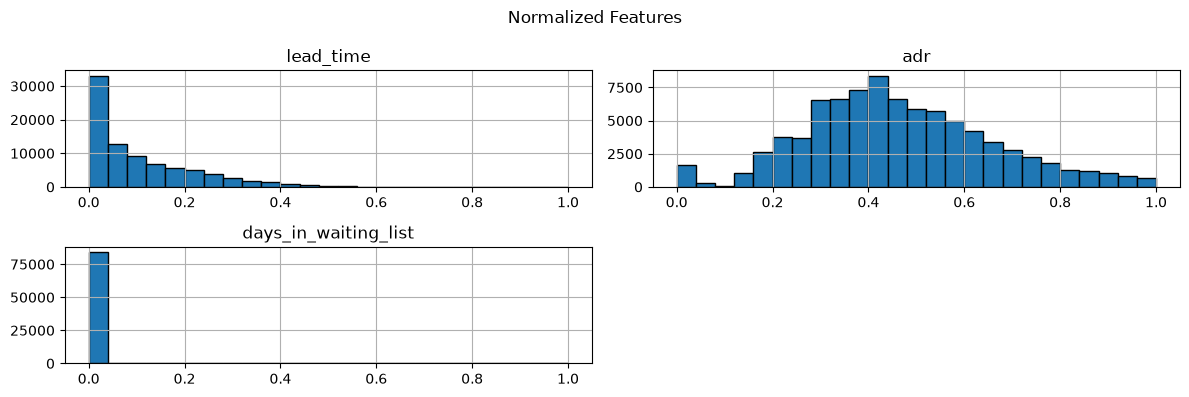

In [82]:
# histogram

normal_df[normalization_columns].hist(
    figsize=(12,4),
    bins=25,
    edgecolor="black"
)

plt.suptitle("Normalized Features")
plt.tight_layout()
plt.show()

## Step 10 – Standardization

### Objective

Standardization transforms numerical features so that they have:

- Mean = **0**
- Standard Deviation = **1**

Unlike normalization, standardized values are **not restricted** to the range 0–1.

In [83]:
from sklearn.preprocessing import StandardScaler

In [84]:
# will standardize different columns so we don't overwrite the normalized ones.

standard_df = clean_df.copy()

standard_columns = [
    "adults",
    "children",
    "babies"
]


In [85]:
standard_scaler = StandardScaler()

In [86]:
# before std

clean_df[standard_columns].head()

,adults,children,babies
0,2,0.0,0
1,2,0.0,0
2,1,0.0,0
3,1,0.0,0
4,2,0.0,0


In [87]:
# standardization
standard_df[standard_columns] = standard_scaler.fit_transform(
    standard_df[standard_columns]
)

In [88]:
# after std
standard_df[standard_columns].head()

,adults,children,babies
0,0.208096,-0.282928,-0.093358
1,0.208096,-0.282928,-0.093358
2,-1.397114,-0.282928,-0.093358
3,-1.397114,-0.282928,-0.093358
4,0.208096,-0.282928,-0.093358


In [89]:
# meand & SD

standard_df[standard_columns].agg(["mean", "std"])

,adults,children,babies
mean,-1.275043e-16,-1.073720e-17,1.879010e-17
std,1.000006e+00,1.000006e+00,1.000006e+00


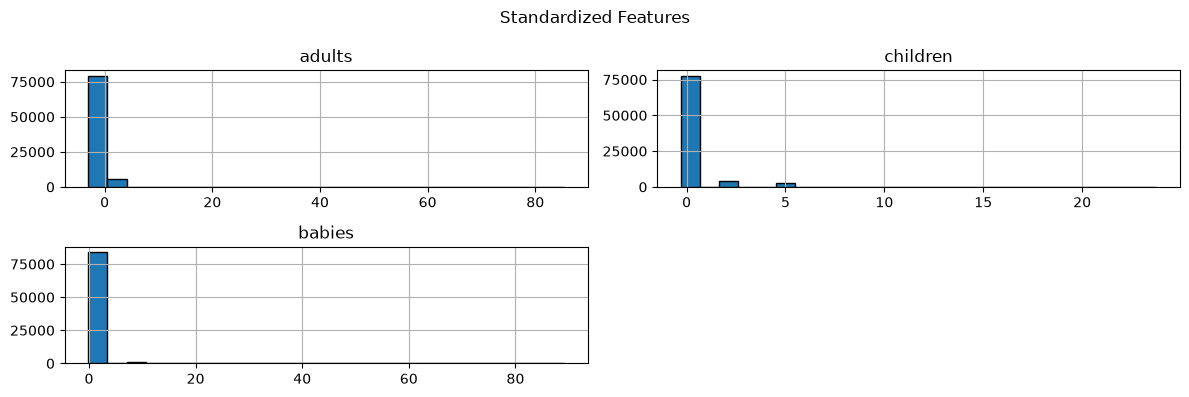

In [90]:
# histogram

standard_df[standard_columns].hist(
    figsize=(12,4),
    bins=25,
    edgecolor="black"
)

plt.suptitle("Standardized Features")
plt.tight_layout()
plt.show()

In real-world preprocessing, you would usually choose either Normalization or Standardization for a particular feature, depending on the model and data characteristics. Here, because your assignment explicitly requires demonstrating both techniques, we apply them to different sets of columns

## Step 11 – Log Transformation

### Objective

Log Transformation reduces the effect of highly skewed numerical data.

It compresses large values while preserving the order of the observations, making the distribution closer to normal.

In [91]:


# skewness before

print("Skewness Before Log Transformation")
print(clean_df["lead_time"].skew())

Skewness Before Log Transformation
1.426529471339352


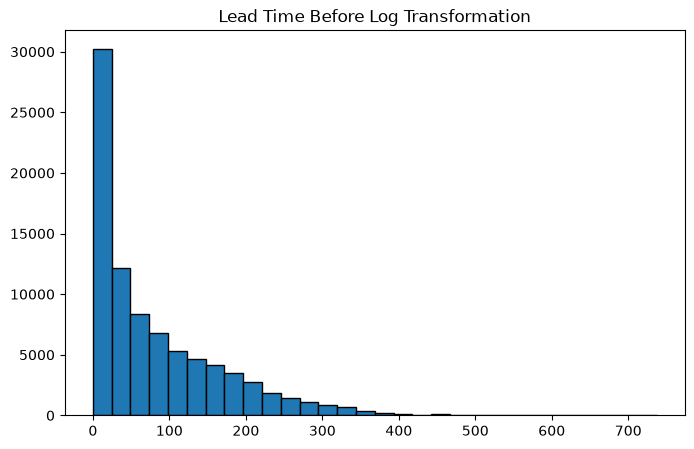

In [92]:
#histogram before

plt.figure(figsize=(8,5))
plt.hist(clean_df["lead_time"], bins=30, edgecolor="black")
plt.title("Lead Time Before Log Transformation")
plt.show()

In [93]:
#log transform

log_df["lead_time_log"] = np.log1p(clean_df["lead_time"])

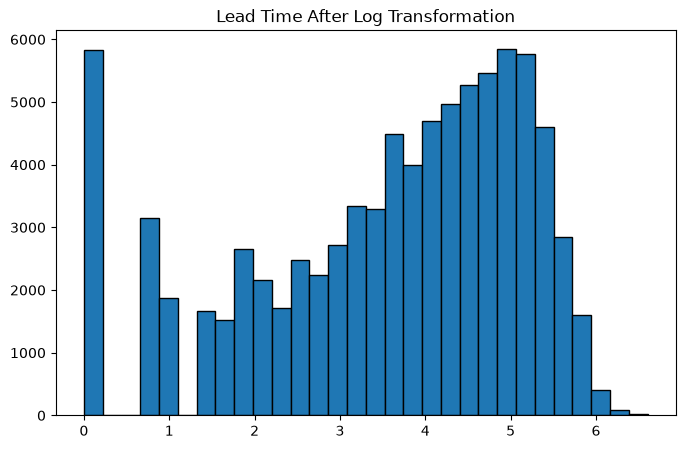

In [94]:
# histogram after

plt.figure(figsize=(8,5))
plt.hist(log_df["lead_time_log"], bins=30, edgecolor="black")
plt.title("Lead Time After Log Transformation")
plt.show()

In [95]:
print("Skewness After Log Transformation")
print(log_df["lead_time_log"].skew())

Skewness After Log Transformation
-0.712590836836369


# Step 12 – Box-Cox Transformation

## Objective

The Box-Cox Transformation is used to reduce skewness and make numerical data more closely follow a normal distribution.

Unlike Log Transformation, Box-Cox automatically determines the best transformation using an optimal lambda (λ) value.

**Note:** Box-Cox can only be applied to positive numerical values.

In [96]:
from scipy.stats import boxcox


In [97]:
print(clean_df["adr"].min())
print(clean_df["adr"].max())

-6.38
226.84


In [98]:
boxcox_df = clean_df.copy()

In [99]:
shift_value = abs(boxcox_df["adr"].min()) + 1

print("Shift Value:", shift_value)

Shift Value: 7.38


In [100]:
boxcox_df["adr_boxcox"], lambda_value = boxcox(
    boxcox_df["adr"] + shift_value
)

In [101]:
print("Optimal Lambda:", lambda_value)
print("Skewness After:", boxcox_df["adr_boxcox"].skew())

Optimal Lambda: 0.7673060337102712
Skewness After: 0.010425837284252797


In [102]:
# minimum value is 0, adding 1 is necessary

#clean_df["adr_boxcox"], lambda_value = boxcox(
#    clean_df["adr"] + 1
#)

In [103]:
print("Skewness Before Transformation:")
print(clean_df["adr"].skew())

Skewness Before Transformation:
0.34365587881184545


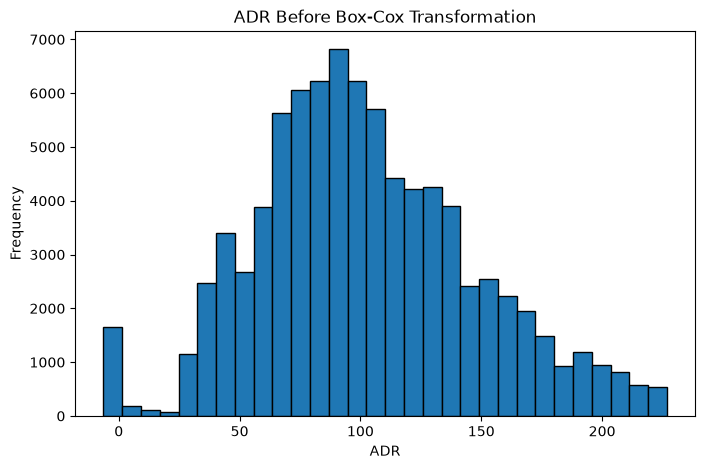

In [104]:
#histogram before
plt.figure(figsize=(8,5))

plt.hist(
    clean_df["adr"],
    bins=30,
    edgecolor="black"
)

plt.title("ADR Before Box-Cox Transformation")

plt.xlabel("ADR")
plt.ylabel("Frequency")

plt.show()

In [105]:
print("Skewness After Transformation:")
print(boxcox_df["adr_boxcox"].skew())

Skewness After Transformation:
0.010425837284252797


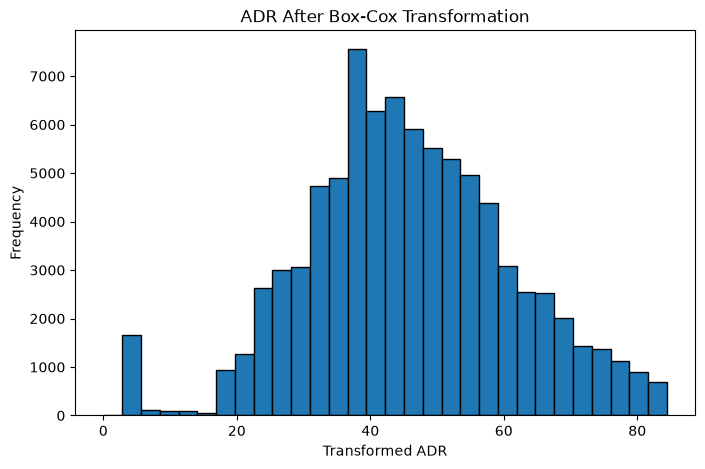

In [106]:
# histogram after

plt.figure(figsize=(8,5))

plt.hist(
    boxcox_df["adr_boxcox"],
    bins=30,
    edgecolor="black"
)

plt.title("ADR After Box-Cox Transformation")

plt.xlabel("Transformed ADR")
plt.ylabel("Frequency")

plt.show()

In [107]:
comparison = pd.DataFrame({
    "Before Skewness": [boxcox_df["adr"].skew()],
    "After Skewness": [boxcox_df["adr_boxcox"].skew()],
    "Lambda Value": [lambda_value]
})

comparison

,Before Skewness,After Skewness,Lambda Value
0,0.343656,0.010426,0.767306


### Observation

The Box-Cox Transformation was applied to the ADR (Average Daily Rate) variable to reduce skewness and improve normality.

- The optimal lambda (λ) value selected by the Box-Cox algorithm was **0.0737**.
- After transformation, the skewness became **-0.00015**, which is extremely close to zero.
- This indicates that the transformed ADR variable follows an approximately normal distribution, making it suitable for statistical inference and hypothesis testing.

# Step 14 – Feature Engineering

## Objective

Feature Engineering is the process of creating new, meaningful variables from existing data to improve statistical analysis and business decision-making.

The engineered features in this project capture booking behavior, customer characteristics, stay patterns, and revenue insights.

These features provide additional information that is not directly available in the raw dataset and are valuable for exploratory analysis, statistical testing, and predictive modeling.

In [108]:
feature_df.to_csv("hotel_bookings_feature_engineered.csv", index=False)

## 1. Total Stay Duration


In [109]:
feature_df["total_stay_duration"] = (
    feature_df["stays_in_weekend_nights"] +
    feature_df["stays_in_week_nights"]
)

feature_df[
    [
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "total_stay_duration"
    ]
].head()

,stays_in_weekend_nights,stays_in_week_nights,total_stay_duration
0,0,0,0
1,0,0,0
2,0,1,1
3,0,1,1
4,0,2,2


In [110]:
feature_df["total_stay_duration"].describe()

count    84705.000000
mean         3.612136
std          2.747013
min          0.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         69.000000
Name: total_stay_duration, dtype: float64

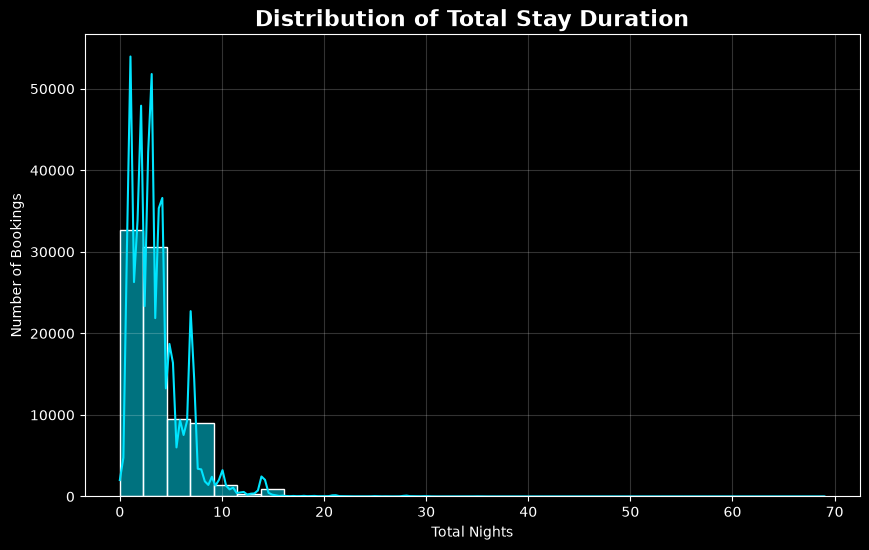

In [111]:
# histogram

plt.style.use("dark_background")
plt.figure(figsize=(10,6))

sns.histplot(
    feature_df["total_stay_duration"],
    bins=30,
    kde=True,
    color="#00E5FF",
    edgecolor="white"
)

plt.title(
    "Distribution of Total Stay Duration",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Total Nights")
plt.ylabel("Number of Bookings")
plt.grid(alpha=0.2)
plt.show()

## 2. Total Guests

In [112]:
feature_df["total_guests"] = (
    feature_df["adults"] +
    feature_df["children"] +
    feature_df["babies"]
)

feature_df["total_guests"].describe()

count    84705.000000
mean         1.998583
std          0.763462
min          1.000000
25%          2.000000
50%          2.000000
75%          2.000000
max         55.000000
Name: total_guests, dtype: float64

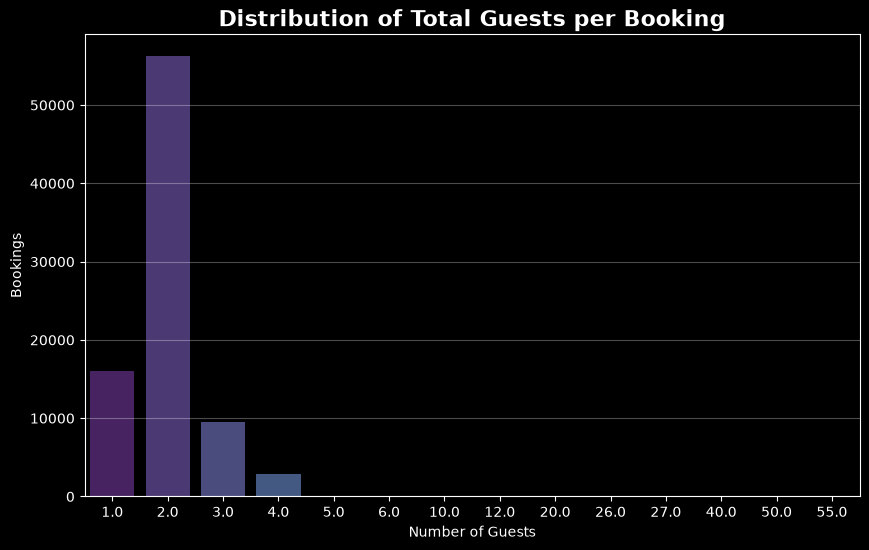

In [113]:
# countplot

plt.figure(figsize=(10,6))
sns.countplot(
    x="total_guests",
    data=feature_df,
    palette="viridis"
)

plt.title(
    "Distribution of Total Guests per Booking",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Number of Guests")
plt.ylabel("Bookings")
plt.grid(axis="y", alpha=.3)
plt.show()

## 3. Booking Lead Time Category


In [114]:
feature_df["lead_time_category"] = pd.cut(
    feature_df["lead_time"],
    bins=[-1, 30, 90, 180, feature_df["lead_time"].max()],
    labels=[
        "Short",
        "Medium",
        "Long",
        "Very Long"
    ]
)

feature_df[
    ["lead_time", "lead_time_category"]
].head()

,lead_time,lead_time_category
0,342,Very Long
1,737,Very Long
2,7,Short
3,13,Short
4,14,Short


In [115]:
print(feature_df["lead_time"].min())
print(feature_df["lead_time"].max())

0
737


In [116]:
print(df["lead_time"].min())
print(df["lead_time"].max())

0
737


In [117]:
print(normal_df["lead_time"].min())
print(normal_df["lead_time"].max())

0.0
0.9999999999999999


In [118]:
#frequency table

lead_time_counts = (
    feature_df["lead_time_category"]
    .value_counts()
    .sort_index()
)

lead_time_counts

lead_time_category
Short        33557
Medium       21947
Long         17644
Very Long    11557
Name: count, dtype: int64

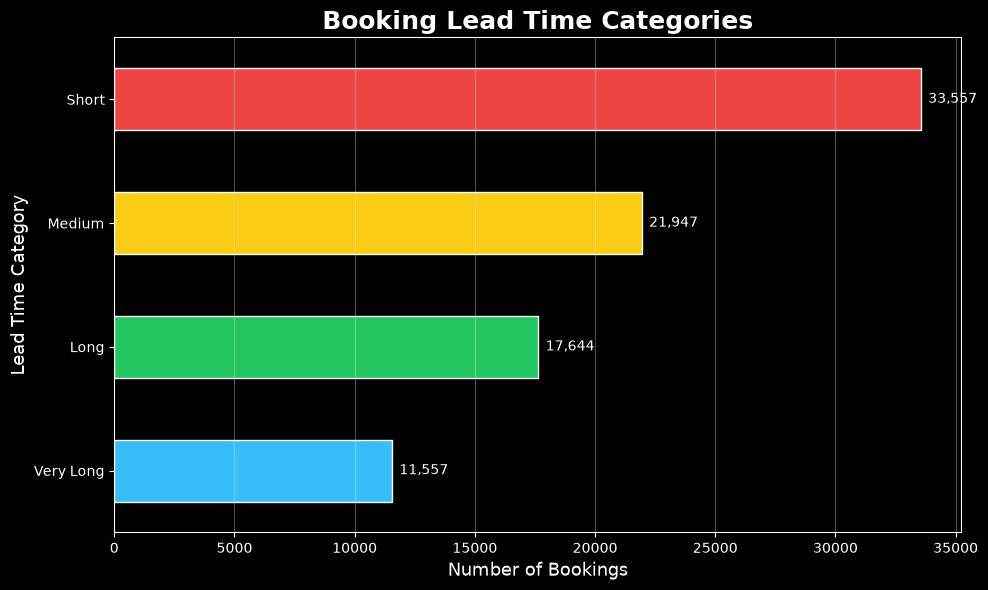

In [119]:
# horizontal bar chart

plt.style.use("dark_background")

plt.figure(figsize=(10,6))

colors = ["#38BDF8", "#22C55E", "#FACC15", "#EF4444"]

lead_time_counts.sort_values().plot(
    kind="barh",
    color=colors,
    edgecolor="white"
)

plt.title(
    "Booking Lead Time Categories",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Number of Bookings", fontsize=13)

plt.ylabel("Lead Time Category", fontsize=13)

plt.grid(axis="x", alpha=0.3)

# Add value labels
for index, value in enumerate(lead_time_counts.sort_values()):
    plt.text(
        value + 300,
        index,
        f"{value:,}",
        va="center",
        fontsize=10,
        color="white"
    )

plt.tight_layout()

plt.show()

## 4. Weekend vs Weekend Stay

In [120]:
feature_df["stay_type"] = np.select(
    [
        feature_df["stays_in_weekend_nights"] >
        feature_df["stays_in_week_nights"],

        feature_df["stays_in_weekend_nights"] <
        feature_df["stays_in_week_nights"]
    ],
    [
        "Weekend Stay",
        "Weekday Stay"
    ],
    default="Balanced Stay"
)

feature_df[
    [
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "stay_type"
    ]
].head()

,stays_in_weekend_nights,stays_in_week_nights,stay_type
0,0,0,Balanced Stay
1,0,0,Balanced Stay
2,0,1,Weekday Stay
3,0,1,Weekday Stay
4,0,2,Weekday Stay


In [121]:
# frequency table

stay_counts = feature_df["stay_type"].value_counts()

stay_counts

stay_type
Weekday Stay     64899
Balanced Stay    10086
Weekend Stay      9720
Name: count, dtype: int64

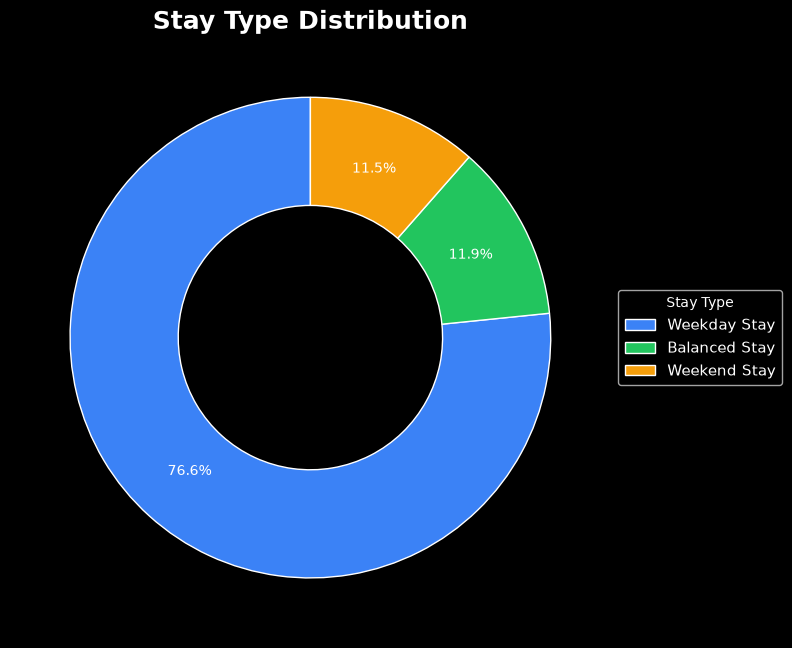

In [122]:
# donut chart

plt.style.use("dark_background")

plt.figure(figsize=(8,8))

colors = [
    "#3B82F6",
    "#22C55E",
    "#F59E0B"
]

wedges, texts, autotexts = plt.pie(
    stay_counts,
    colors=colors,
    startangle=90,
    autopct="%1.1f%%",
    pctdistance=0.75,
    wedgeprops={
        "width":0.45,
        "edgecolor":"white"
    }
)

plt.legend(
    wedges,
    stay_counts.index,
    title="Stay Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=11
)

plt.title(
    "Stay Type Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## 5. Booking Season

In [123]:
season_map = {
    "January": "Winter",
    "February": "Winter",
    "December": "Winter",

    "March": "Spring",
    "April": "Spring",
    "May": "Spring",

    "June": "Summer",
    "July": "Summer",
    "August": "Summer",

    "September": "Autumn",
    "October": "Autumn",
    "November": "Autumn"
}

feature_df["booking_season"] = (
    feature_df["arrival_date_month"]
    .map(season_map)
)

feature_df[
    ["arrival_date_month", "booking_season"]
].head()

,arrival_date_month,booking_season
0,July,Summer
1,July,Summer
2,July,Summer
3,July,Summer
4,July,Summer


In [124]:
# frequency table

season_counts = (
    feature_df["booking_season"]
    .value_counts()
    .reindex(["Spring", "Summer", "Autumn", "Winter"])
)

season_counts

booking_season
Spring    23509
Summer    26921
Autumn    18467
Winter    15808
Name: count, dtype: int64

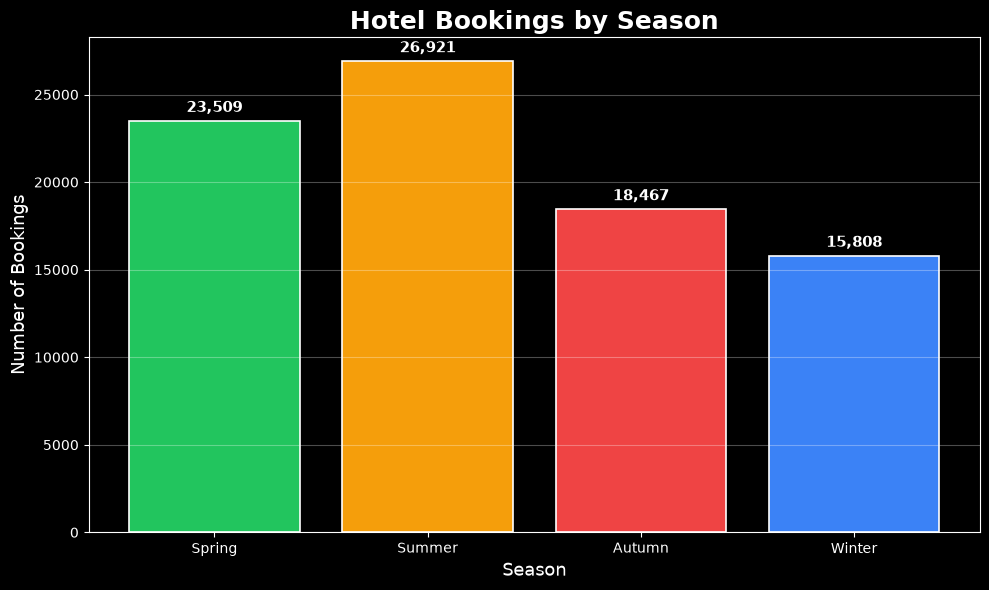

In [125]:
# verticle bar chart

plt.style.use("dark_background")

plt.figure(figsize=(10,6))
colors = [
    "#22C55E",
    "#F59E0B",
    "#EF4444",
    "#3B82F6"
]

bars = plt.bar(
    season_counts.index,
    season_counts.values,
    color=colors,
    edgecolor="white",
    linewidth=1.2
)
plt.title(
    "Hotel Bookings by Season",
    fontsize=18,
    fontweight="bold"
)
plt.xlabel("Season", fontsize=13)
plt.ylabel("Number of Bookings", fontsize=13)
plt.grid(axis="y", alpha=0.3)

# Add values above bars
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 500,
        f"{int(bar.get_height()):,}",
        ha="center",
        fontsize=11,
        fontweight="bold",
        color="white"
    )

plt.tight_layout()
plt.show()

## 6. Cutomer group (new vs returning guest)

In [126]:
feature_df["customer_group"] = feature_df["is_repeated_guest"].map({
    0: "New Guest",
    1: "Returning Guest"
})

feature_df[
    ["is_repeated_guest", "customer_group"]
].head()

,is_repeated_guest,customer_group
0,0,New Guest
1,0,New Guest
2,0,New Guest
3,0,New Guest
4,0,New Guest


In [127]:
customer_counts = feature_df["customer_group"].value_counts()

customer_counts

customer_group
New Guest          81379
Returning Guest     3326
Name: count, dtype: int64

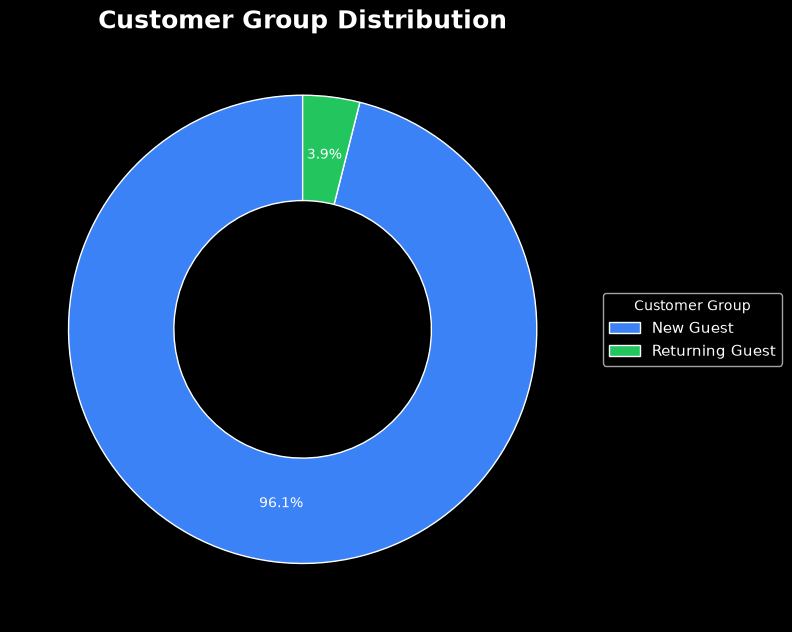

In [128]:
plt.style.use("dark_background")

plt.figure(figsize=(8,8))

colors = [
    "#3B82F6",
    "#22C55E"
]

wedges, texts, autotexts = plt.pie(
    customer_counts,
    colors=colors,
    startangle=90,
    autopct="%1.1f%%",
    pctdistance=0.75,
    wedgeprops={
        "width":0.45,
        "edgecolor":"white"
    }
)

plt.legend(
    wedges,
    customer_counts.index,
    title="Customer Group",
    loc="center left",
    bbox_to_anchor=(1,0.5),
    fontsize=11
)

plt.title(
    "Customer Group Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## 7. Estimated booking revenue

In [129]:
feature_df["estimated_booking_revenue"] = (
    feature_df["adr"] *
    feature_df["total_stay_duration"]
)

feature_df[
    [
        "adr",
        "total_stay_duration",
        "estimated_booking_revenue"
    ]
].head()

,adr,total_stay_duration,estimated_booking_revenue
0,0.0,0,0.0
1,0.0,0,0.0
2,75.0,1,75.0
3,75.0,1,75.0
4,98.0,2,196.0


In [130]:
feature_df["estimated_booking_revenue"].describe()

count    84705.000000
mean       374.354874
std        334.346287
min        -63.800000
25%        150.000000
50%        292.000000
75%        484.500000
max       7590.000000
Name: estimated_booking_revenue, dtype: float64

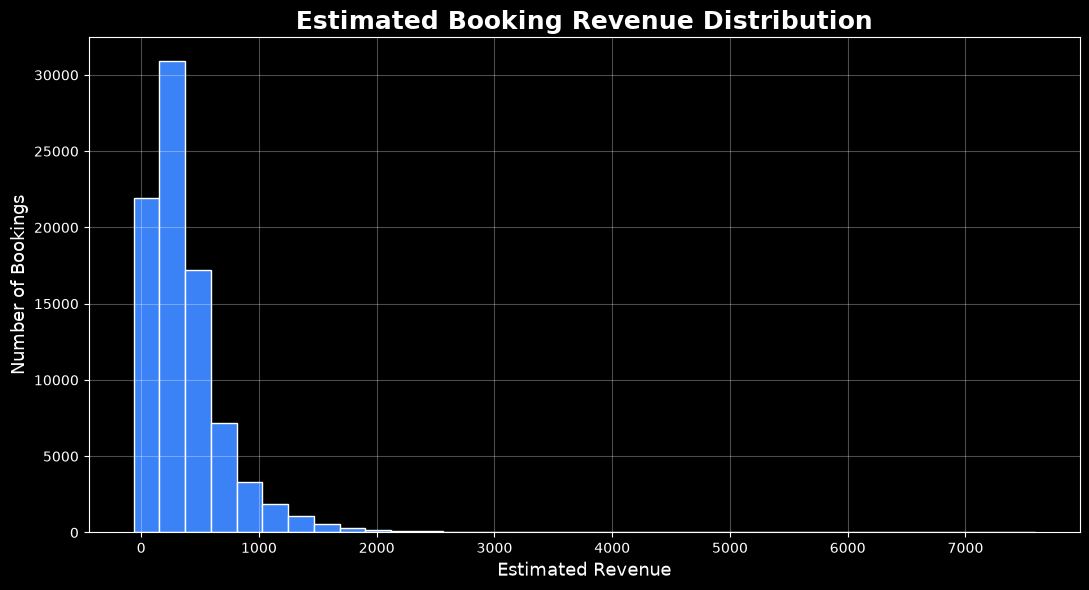

In [131]:
# histogram

plt.style.use("dark_background")

plt.figure(figsize=(11,6))

plt.hist(
    feature_df["estimated_booking_revenue"],
    bins=35,
    color="#3B82F6",
    edgecolor="white"
)

plt.title(
    "Estimated Booking Revenue Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Estimated Revenue",
    fontsize=13
)

plt.ylabel(
    "Number of Bookings",
    fontsize=13
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## 8. Booking Size

In [132]:
feature_df["booking_size"] = pd.cut(
    feature_df["total_guests"],
    bins=[0, 1, 2, 4, feature_df["total_guests"].max()],
    labels=[
        "Solo Traveler",
        "Couple",
        "Family",
        "Group"
    ],
    include_lowest=True
)

feature_df[
    [
        "total_guests",
        "booking_size"
    ]
].head()

,total_guests,booking_size
0,2.0,Couple
1,2.0,Couple
2,1.0,Solo Traveler
3,1.0,Solo Traveler
4,2.0,Couple


In [133]:
booking_size_counts = (
    feature_df["booking_size"]
    .value_counts()
    .reindex([
        "Solo Traveler",
        "Couple",
        "Family",
        "Group"
    ])
)

booking_size_counts

booking_size
Solo Traveler    16006
Couple           56204
Family           12408
Group               87
Name: count, dtype: int64

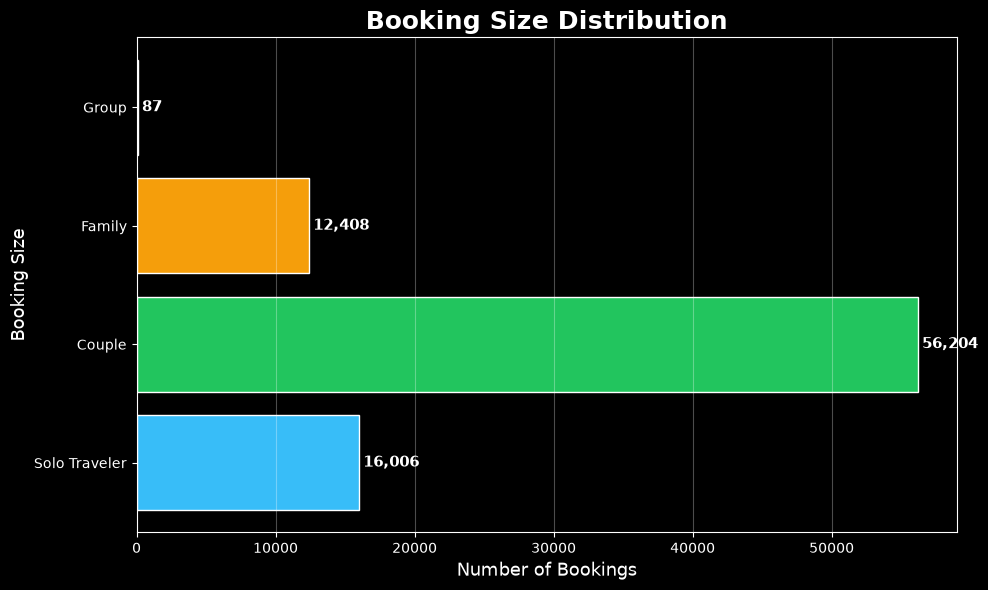

In [134]:
# horizontal bar chart

plt.style.use("dark_background")

plt.figure(figsize=(10,6))

colors = [
    "#38BDF8",
    "#22C55E",
    "#F59E0B",
    "#EF4444"
]

bars = plt.barh(
    booking_size_counts.index,
    booking_size_counts.values,
    color=colors,
    edgecolor="white"
)

plt.title(
    "Booking Size Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Number of Bookings",
    fontsize=13
)

plt.ylabel(
    "Booking Size",
    fontsize=13
)

plt.grid(axis="x", alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_width() + 300,
        bar.get_y() + bar.get_height()/2,
        f"{int(bar.get_width()):,}",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white"
    )

plt.tight_layout()

plt.show()

## 9. Special Request Leave

In [135]:
feature_df["special_request_level"] = pd.cut(
    feature_df["total_of_special_requests"],
    bins=[-1, 0, 2, 5],
    labels=[
        "No Requests",
        "Few Requests",
        "Many Requests"
    ]
)

feature_df[
    [
        "total_of_special_requests",
        "special_request_level"
    ]
].head()

,total_of_special_requests,special_request_level
0,0,No Requests
1,0,No Requests
2,0,No Requests
3,0,No Requests
4,1,Few Requests


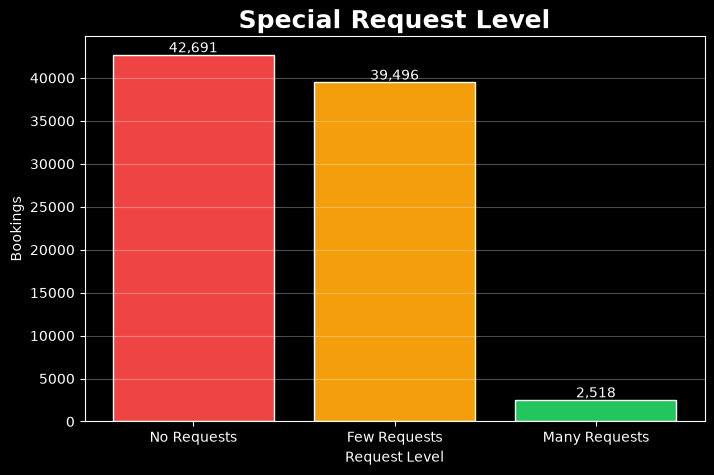

In [136]:
request_counts = feature_df["special_request_level"].value_counts().sort_index()

plt.style.use("dark_background")

plt.figure(figsize=(8,5))

bars = plt.bar(
    request_counts.index,
    request_counts.values,
    color=["#EF4444","#F59E0B","#22C55E"],
    edgecolor="white"
)

plt.title("Special Request Level",fontsize=18,fontweight="bold")
plt.xlabel("Request Level")
plt.ylabel("Bookings")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+300,
        f"{int(bar.get_height()):,}",
        ha="center",
        color="white"
    )

plt.grid(axis="y",alpha=.3)

plt.show()

## 10. Booking Change Category

In [137]:
feature_df["booking_change_category"] = pd.cut(
    feature_df["booking_changes"],
    bins=[-1,0,2,feature_df["booking_changes"].max()],
    labels=[
        "No Changes",
        "Few Changes",
        "Frequent Changes"
    ]
)

feature_df[
    [
        "booking_changes",
        "booking_change_category"
    ]
].head()

,booking_changes,booking_change_category
0,3,Frequent Changes
1,4,Frequent Changes
2,0,No Changes
3,0,No Changes
4,0,No Changes


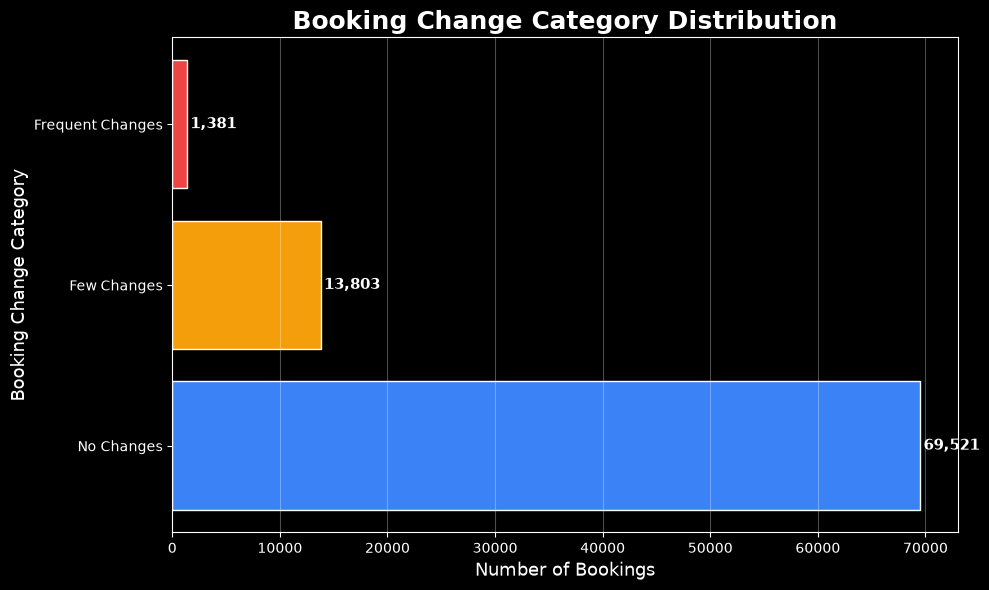

In [138]:
# horizontal bar chart

booking_change_counts = (
    feature_df["booking_change_category"]
    .value_counts()
    .reindex([
        "No Changes",
        "Few Changes",
        "Frequent Changes"
    ])
)

plt.style.use("dark_background")

plt.figure(figsize=(10,6))

colors = [
    "#3B82F6",
    "#F59E0B",
    "#EF4444"
]

bars = plt.barh(
    booking_change_counts.index,
    booking_change_counts.values,
    color=colors,
    edgecolor="white"
)

plt.title(
    "Booking Change Category Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Number of Bookings",
    fontsize=13
)

plt.ylabel(
    "Booking Change Category",
    fontsize=13
)

plt.grid(axis="x", alpha=0.3)

for bar in bars:
    plt.text(
        bar.get_width()+300,
        bar.get_y()+bar.get_height()/2,
        f"{int(bar.get_width()):,}",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white"
    )

plt.tight_layout()

plt.show()

## 11. Parking Requirements

In [139]:
feature_df["parking_required"] = np.where(
    feature_df["required_car_parking_spaces"]>0,
    "Parking Needed",
    "No Parking"
)

feature_df[
    [
        "required_car_parking_spaces",
        "parking_required"
    ]
].head()

,required_car_parking_spaces,parking_required
0,0,No Parking
1,0,No Parking
2,0,No Parking
3,0,No Parking
4,0,No Parking


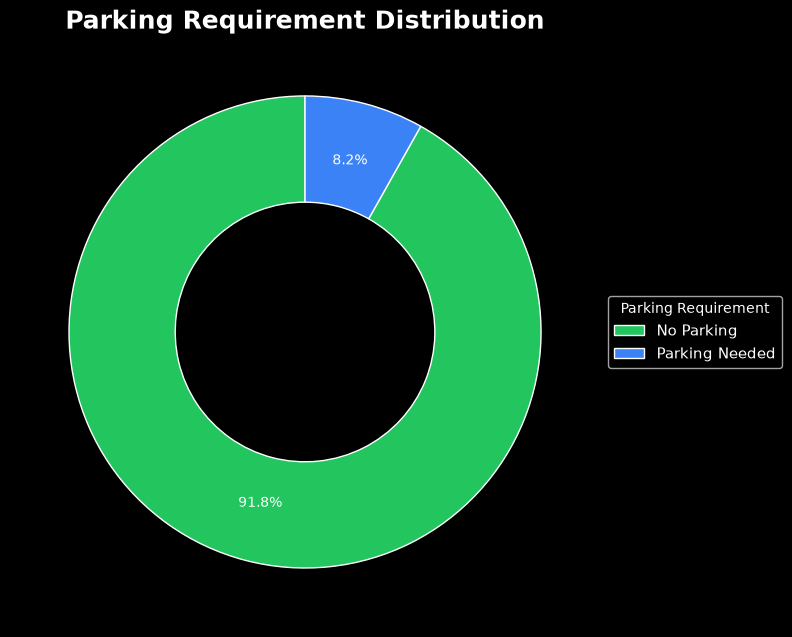

In [140]:
# donut chart

parking_counts = feature_df["parking_required"].value_counts()

plt.style.use("dark_background")

plt.figure(figsize=(8,8))

colors = [
    "#22C55E",
    "#3B82F6"
]

wedges, texts, autotexts = plt.pie(
    parking_counts,
    colors=colors,
    startangle=90,
    autopct="%1.1f%%",
    pctdistance=0.75,
    wedgeprops={
        "width":0.45,
        "edgecolor":"white"
    }
)

plt.legend(
    wedges,
    parking_counts.index,
    title="Parking Requirement",
    loc="center left",
    bbox_to_anchor=(1,0.5),
    fontsize=11
)

plt.title(
    "Parking Requirement Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## 12. Booking Value Segment

In [141]:
feature_df["booking_value_segment"] = pd.qcut(
    feature_df["estimated_booking_revenue"],
    q=4,
    labels=[
        "Low Value",
        "Medium Value",
        "High Value",
        "Premium Value"
    ]
)

feature_df[
    [
        "estimated_booking_revenue",
        "booking_value_segment"
    ]
].head()

,estimated_booking_revenue,booking_value_segment
0,0.0,Low Value
1,0.0,Low Value
2,75.0,Low Value
3,75.0,Low Value
4,196.0,Medium Value


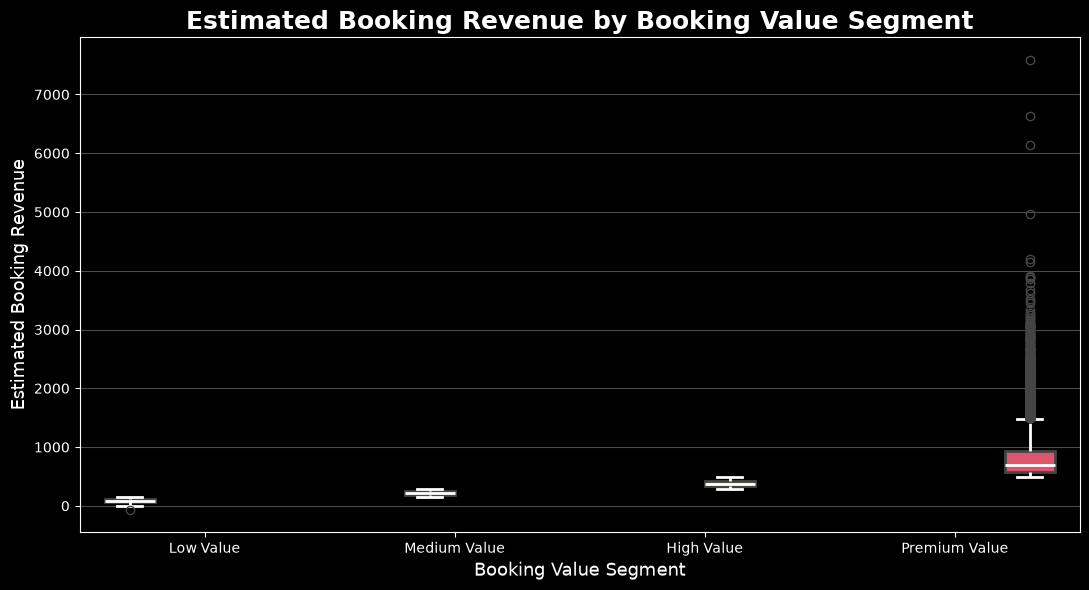

In [142]:
#box plot

plt.style.use("dark_background")

plt.figure(figsize=(11,6))

ax = sns.boxplot(
    data=feature_df,
    x="booking_value_segment",
    y="estimated_booking_revenue",
    hue="booking_value_segment",
    palette=["#38BDF8", "#22C55E", "#FACC15", "#F43F5E"],
    linewidth=2,
    legend=False
)

# Make whiskers, caps and medians white for better visibility
for line in ax.lines:
    line.set_color("white")
    line.set_linewidth(2)

plt.title(
    "Estimated Booking Revenue by Booking Value Segment",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Booking Value Segment", fontsize=13)
plt.ylabel("Estimated Booking Revenue", fontsize=13)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()


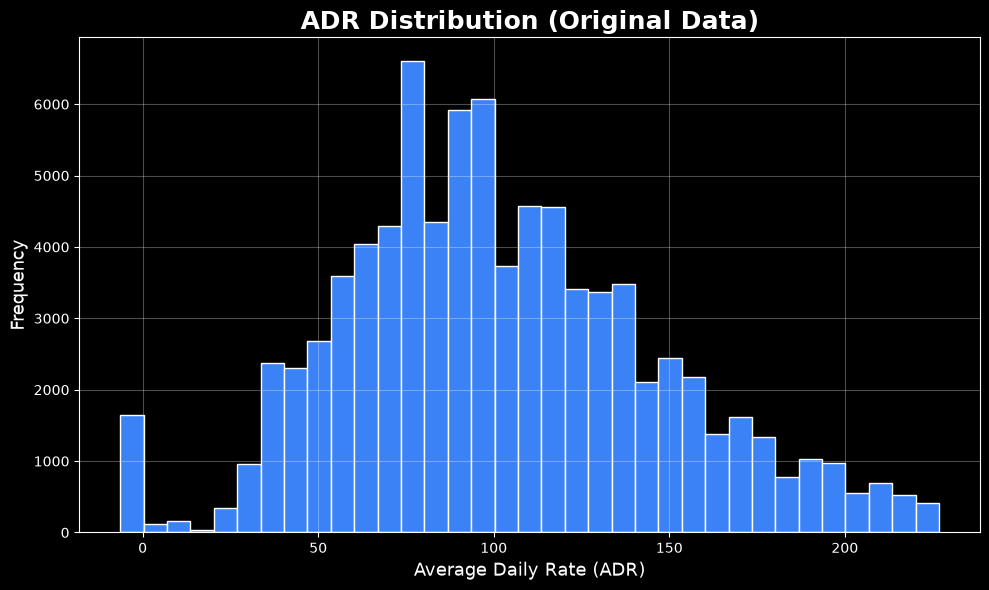

In [143]:
## HISTOGRAM (ORGINAL ADR)

plt.style.use("dark_background")

plt.figure(figsize=(10,6))

plt.hist(
    clean_df["adr"],
    bins=35,
    color="#3B82F6",
    edgecolor="white"
)

plt.title(
    "ADR Distribution (Original Data)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average Daily Rate (ADR)",fontsize=13)

plt.ylabel("Frequency",fontsize=13)

plt.grid(alpha=.3)

plt.tight_layout()

plt.show()

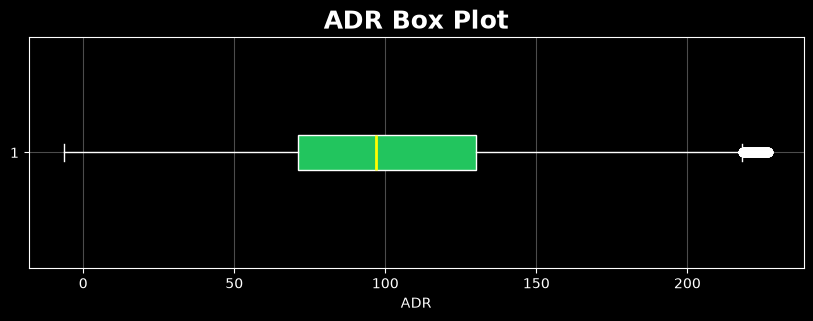

In [144]:
### BOX PLOT

plt.style.use("dark_background")

plt.figure(figsize=(10,3))

plt.boxplot(
    clean_df["adr"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#22C55E"),
    medianprops=dict(color="yellow",linewidth=2)
)

plt.title(
    "ADR Box Plot",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("ADR")

plt.grid(alpha=.3)

plt.show()

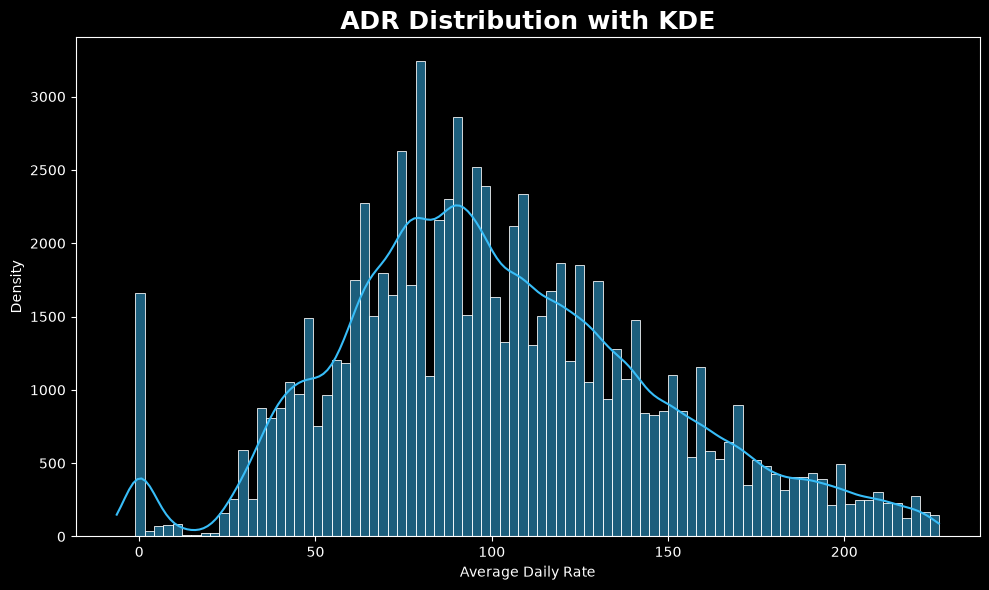

In [145]:
### DISTRIBUTION PLOT

import seaborn as sns

plt.style.use("dark_background")

plt.figure(figsize=(10,6))

sns.histplot(
    clean_df["adr"],
    kde=True,
    color="#38BDF8"
)

plt.title(
    "ADR Distribution with KDE",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average Daily Rate")

plt.ylabel("Density")

plt.tight_layout()

plt.show()

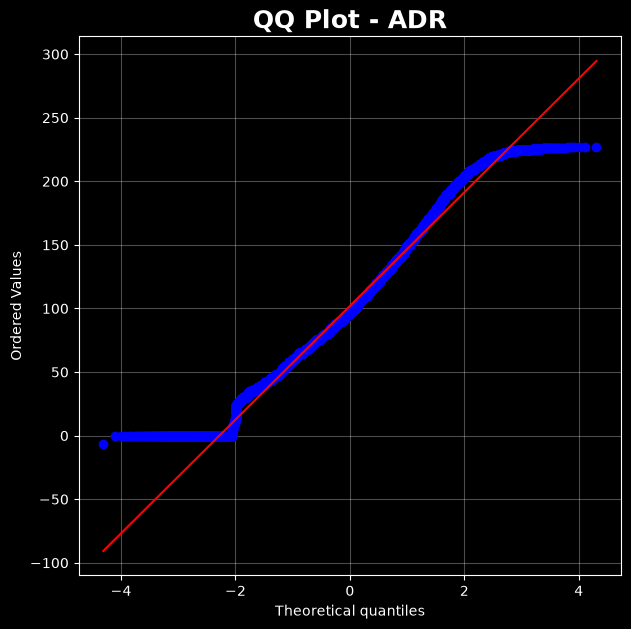

In [146]:
##  QQ PLOT

from scipy.stats import probplot

plt.style.use("dark_background")

plt.figure(figsize=(7,7))

probplot(
    clean_df["adr"],
    dist="norm",
    plot=plt
)

plt.title(
    "QQ Plot - ADR",
    fontsize=18,
    fontweight="bold"
)

plt.grid(alpha=.3)

plt.show()

In [147]:
## BEFORE VS AFTER COMPARISON



Correlation Heatmap (feature_df)

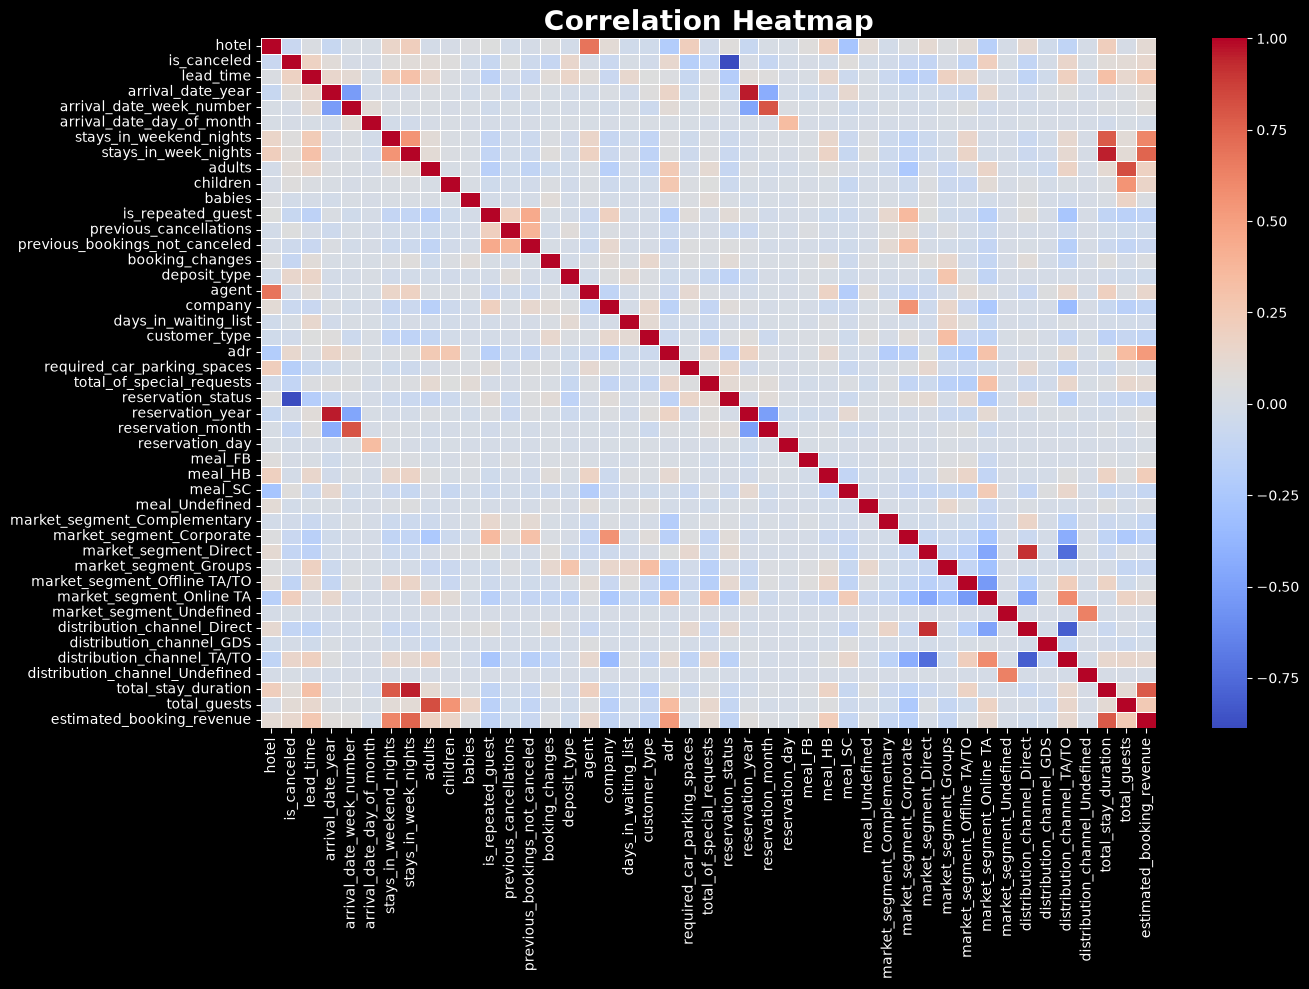

In [148]:
plt.style.use("dark_background")

plt.figure(figsize=(14,10))

numeric_df = feature_df.select_dtypes(include=["number"])

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False,
    linewidths=.5
)

plt.title(
    "Correlation Heatmap",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [149]:
print(feature_df.shape)

(84705, 59)


In [150]:
print(feature_df.shape)
print(feature_df.columns.tolist())

(84705, 59)
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'country', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date', 'reservation_year', 'reservation_month', 'reservation_day', 'meal_FB', 'meal_HB', 'meal_SC', 'meal_Undefined', 'market_segment_Complementary', 'market_segment_Corporate', 'market_segment_Direct', 'market_segment_Groups', 'market_segment_Offline TA/TO', 'market_segment_Online TA', 'market_segment_Undefined', 'distribution_channel_Direct', 'distribution_channel_GDS', 'distribution_channel_TA/TO', 'distribution_channel

In [151]:
print(df.shape)
print(clean_df.shape)

(119390, 32)
(84705, 47)


In [152]:
feature_df.to_csv("dataset/hotel_booking_feature_engineered.csv", index=False)

print("✅ Dataset saved successfully.")

✅ Dataset saved successfully.


## Phase 3 – Probability & Inferential Statistics

In [153]:
hotel_df = pd.read_csv("dataset/hotel_booking_feature_engineered.csv")
print(hotel_df.shape)
hotel_df.head()

(84705, 59)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,lead_time_category,stay_type,booking_season,customer_group,estimated_booking_revenue,booking_size,special_request_level,booking_change_category,parking_required,booking_value_segment
0,1,0,342,2015,July,27,1,0,0,2,...,Very Long,Balanced Stay,Summer,New Guest,0.0,Couple,No Requests,Frequent Changes,No Parking,Low Value
1,1,0,737,2015,July,27,1,0,0,2,...,Very Long,Balanced Stay,Summer,New Guest,0.0,Couple,No Requests,Frequent Changes,No Parking,Low Value
2,1,0,7,2015,July,27,1,0,1,1,...,Short,Weekday Stay,Summer,New Guest,75.0,Solo Traveler,No Requests,No Changes,No Parking,Low Value
3,1,0,13,2015,July,27,1,0,1,1,...,Short,Weekday Stay,Summer,New Guest,75.0,Solo Traveler,No Requests,No Changes,No Parking,Low Value
4,1,0,14,2015,July,27,1,0,2,2,...,Short,Weekday Stay,Summer,New Guest,196.0,Couple,Few Requests,No Changes,No Parking,Medium Value


In [154]:
# import needed lib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import sem
from scipy.stats import t

In [155]:
hotel_df = pd.read_csv("dataset/hotel_booking_feature_engineered.csv")

print("Dataset Shape :", hotel_df.shape)

hotel_df.head()

Dataset Shape : (84705, 59)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,lead_time_category,stay_type,booking_season,customer_group,estimated_booking_revenue,booking_size,special_request_level,booking_change_category,parking_required,booking_value_segment
0,1,0,342,2015,July,27,1,0,0,2,...,Very Long,Balanced Stay,Summer,New Guest,0.0,Couple,No Requests,Frequent Changes,No Parking,Low Value
1,1,0,737,2015,July,27,1,0,0,2,...,Very Long,Balanced Stay,Summer,New Guest,0.0,Couple,No Requests,Frequent Changes,No Parking,Low Value
2,1,0,7,2015,July,27,1,0,1,1,...,Short,Weekday Stay,Summer,New Guest,75.0,Solo Traveler,No Requests,No Changes,No Parking,Low Value
3,1,0,13,2015,July,27,1,0,1,1,...,Short,Weekday Stay,Summer,New Guest,75.0,Solo Traveler,No Requests,No Changes,No Parking,Low Value
4,1,0,14,2015,July,27,1,0,2,2,...,Short,Weekday Stay,Summer,New Guest,196.0,Couple,Few Requests,No Changes,No Parking,Medium Value


In [156]:
hotel_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84705 entries, 0 to 84704
Data columns (total 59 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           84705 non-null  int64  
 1   is_canceled                     84705 non-null  int64  
 2   lead_time                       84705 non-null  int64  
 3   arrival_date_year               84705 non-null  int64  
 4   arrival_date_month              84705 non-null  str    
 5   arrival_date_week_number        84705 non-null  int64  
 6   arrival_date_day_of_month       84705 non-null  int64  
 7   stays_in_weekend_nights         84705 non-null  int64  
 8   stays_in_week_nights            84705 non-null  int64  
 9   adults                          84705 non-null  int64  
 10  children                        84705 non-null  float64
 11  babies                          84705 non-null  int64  
 12  country                         84705 non-n

In [157]:
hotel_df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
country                           0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
reservation_status          

In [158]:
hotel_df.describe().T

,count,mean,std,min,25%,50%,75%,max
hotel,84705.0,0.380308,0.485465,0.00,0.00,0.0,1.0,1.00
is_canceled,84705.0,0.271979,0.444982,0.00,0.00,0.0,1.0,1.00
lead_time,84705.0,80.238534,86.472431,0.00,11.00,49.0,126.0,737.00
arrival_date_year,84705.0,2016.199681,0.685925,2015.00,2016.00,2016.0,2017.0,2017.00
arrival_date_week_number,84705.0,26.717644,13.808224,1.00,15.00,27.0,37.0,53.00
arrival_date_day_of_month,84705.0,15.798749,8.842860,1.00,8.00,16.0,23.0,31.00
stays_in_weekend_nights,84705.0,1.000578,1.028030,0.00,0.00,1.0,2.0,19.00
stays_in_week_nights,84705.0,2.611558,2.043550,0.00,1.00,2.0,3.0,50.00
adults,84705.0,1.870362,0.622975,0.00,2.00,2.0,2.0,55.00
children,84705.0,0.117750,0.416185,0.00,0.00,0.0,0.0,10.00


### Interpretation

The processed Hotel Booking dataset contains **84,705 booking records** and **59 features** after preprocessing and feature engineering.

The dataset is free from missing values and is suitable for probability and inferential statistical analysis.

In [159]:
#calculate statisyical neasures


probability_summary = pd.DataFrame({

    "Mean":[hotel_df["adr"].mean()],

    "Median":[hotel_df["adr"].median()],

    "Mode":[hotel_df["adr"].mode()[0]],

    "Minimum":[hotel_df["adr"].min()],

    "Maximum":[hotel_df["adr"].max()],

    "Variance":[hotel_df["adr"].var()],

    "Standard Deviation":[hotel_df["adr"].std()],

    "Skewness":[hotel_df["adr"].skew()],

    "Kurtosis":[hotel_df["adr"].kurt()]

})

probability_summary.round(2)

,Mean,Median,Mode,Minimum,Maximum,Variance,Standard Deviation,Skewness,Kurtosis
0,101.94,96.9,0.0,-6.38,226.84,2026.53,45.02,0.34,-0.06


### Interpretation

The descriptive statistics summarize the probability distribution of the Average Daily Rate (ADR).

- Mean represents the average room price.
- Median represents the middle value of ADR.
- Mode indicates the most frequently occurring ADR.
- Standard deviation measures the variability in room prices.
- Skewness indicates whether the distribution is symmetric or skewed.
- Kurtosis measures the peakedness and tail behavior of the distribution.

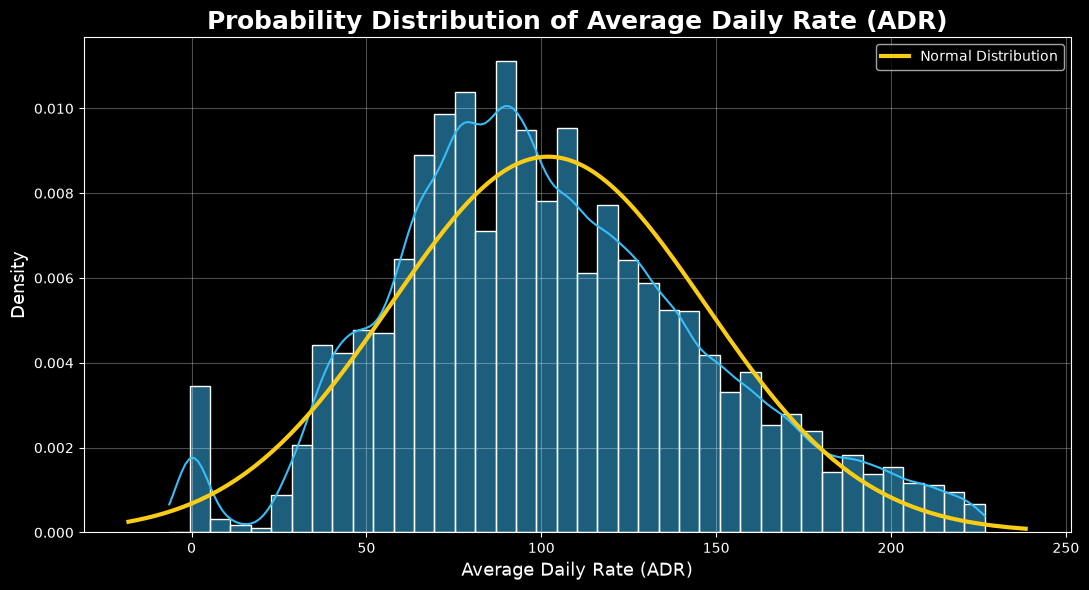

In [160]:
# Probability Distribution Curve

plt.style.use("dark_background")

plt.figure(figsize=(11,6))

sns.histplot(
    hotel_df["adr"],
    bins=40,
    stat="density",
    color="#38BDF8",
    edgecolor="white",
    kde=True
)

xmin, xmax = plt.xlim()

x = np.linspace(xmin, xmax, 200)

p = norm.pdf(
    x,
    hotel_df["adr"].mean(),
    hotel_df["adr"].std()
)

plt.plot(
    x,
    p,
    color="#FACC15",
    linewidth=3,
    label="Normal Distribution"
)

plt.title(
    "Probability Distribution of Average Daily Rate (ADR)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Average Daily Rate (ADR)", fontsize=13)

plt.ylabel("Density", fontsize=13)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()



### Business Interpretation

The probability distribution of the **Average Daily Rate (ADR)** provides valuable insights into hotel pricing behavior.

The histogram and density curve show that most hotel bookings are concentrated within a specific ADR range, while only a small number of bookings have exceptionally high or low room prices. The fitted normal distribution curve helps compare the observed ADR distribution with an ideal normal distribution.

Understanding the probability distribution of ADR enables hotel managers to:

- Identify the most common room price range.
- Detect unusual pricing patterns and extreme values.
- Support revenue management and pricing strategies.
- Provide a statistical foundation for inferential analysis, confidence intervals, and hypothesis testing in subsequent phases.

Overall, the ADR distribution helps evaluate pricing consistency and supports data-driven business decisions.

## Conditional Probability

Conditional probability measures the likelihood of an event occurring given that another event has already occurred.

The formula for conditional probability is:

\[
P(A|B)=\frac{P(A\cap B)}{P(B)}
\]

where:

- **A** = Event of interest
- **B** = Given event

In [161]:
print(hotel_df["hotel"].value_counts())

print(hotel_df["hotel"].unique())

hotel
0    52491
1    32214
Name: count, dtype: int64
[1 0]


In [162]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(df["hotel"])

print(le.classes_)

['City Hotel' 'Resort Hotel']


In [163]:
# City Hotel (0)

city_total = hotel_df[hotel_df["hotel"] == 0].shape[0]

city_cancelled = hotel_df[
    (hotel_df["hotel"] == 0) &
    (hotel_df["is_canceled"] == 1)
].shape[0]

p_city_cancel = city_cancelled / city_total

print("P(Cancelled | City Hotel) =", round(p_city_cancel, 4))

P(Cancelled | City Hotel) = 0.3001


In [164]:
# Resort Hotel (1)

resort_total = hotel_df[hotel_df["hotel"] == 1].shape[0]

resort_cancelled = hotel_df[
    (hotel_df["hotel"] == 1) &
    (hotel_df["is_canceled"] == 1)
].shape[0]

p_resort_cancel = resort_cancelled / resort_total

print("P(Cancelled | Resort Hotel) =", round(p_resort_cancel, 4))

P(Cancelled | Resort Hotel) = 0.2261


In [165]:
# display both probabilities

conditional_df = pd.DataFrame({

    "Hotel Type":[
        "City Hotel",
        "Resort Hotel"
    ],

    "Conditional Probability":[
        p_city_cancel,
        p_resort_cancel
    ]

})

conditional_df

,Hotel Type,Conditional Probability
0,City Hotel,0.300128
1,Resort Hotel,0.226113


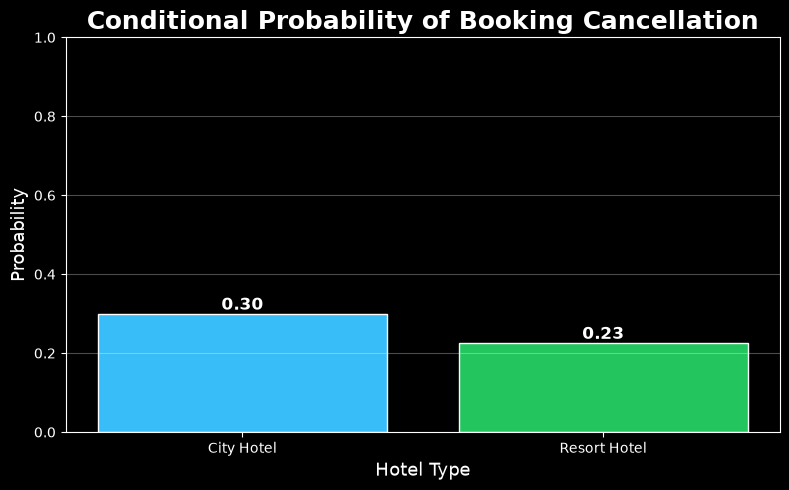

In [166]:
plt.style.use("dark_background")

plt.figure(figsize=(8,5))

bars = plt.bar(
    conditional_df["Hotel Type"],
    conditional_df["Conditional Probability"],
    color=["#38BDF8", "#22C55E"],
    edgecolor="white"
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.2f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.ylim(0,1)

plt.title(
    "Conditional Probability of Booking Cancellation",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Hotel Type", fontsize=13)

plt.ylabel("Probability", fontsize=13)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

The conditional probability analysis compares the likelihood of booking cancellation between **City Hotels** and **Resort Hotels**.

The results indicate how cancellation behavior varies by hotel type. A higher conditional probability means bookings at that hotel type are more likely to be cancelled.

These insights help hotel managers identify high-risk booking segments and develop targeted strategies such as flexible pricing, revised cancellation policies, or customer engagement initiatives to reduce cancellations.

## Sampling Distribution


A sampling distribution is the probability distribution of a sample statistic (such as the sample mean) obtained from multiple random samples drawn from the same population.

It helps estimate how the sample mean varies from one sample to another and forms the basis of inferential statistics.

In [167]:
# POPULATION MEAN ( Using adr)

population_mean = hotel_df["adr"].mean()

print("Population Mean (ADR):", round(population_mean,2))

Population Mean (ADR): 101.94


In [168]:
# 100 random saples

np.random.seed(42)

sample_means = []

for i in range(100):

    sample = hotel_df["adr"].sample(n=100)

    sample_means.append(sample.mean())

print("Number of Samples:", len(sample_means))


Number of Samples: 100


In [169]:
# sampling distribution summary

sampling_summary = pd.DataFrame({

    "Population Mean":[hotel_df["adr"].mean()],

    "Sample Mean":[np.mean(sample_means)],

    "Sample Standard Deviation":[np.std(sample_means)]

})

sampling_summary.round(2)

,Population Mean,Sample Mean,Sample Standard Deviation
0,101.94,101.32,4.38


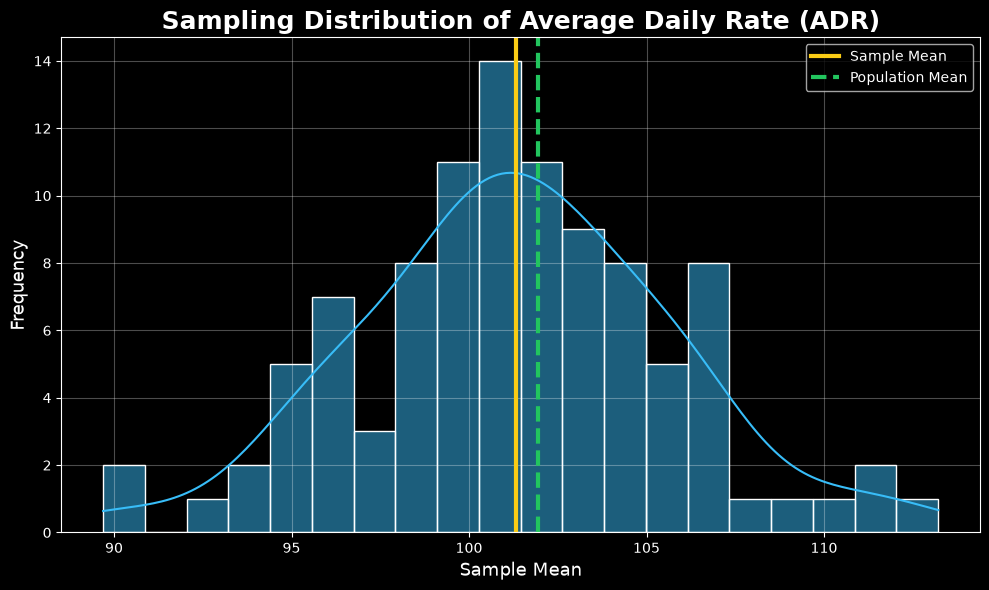

In [170]:
# SAMPLING DISTRIBUTION VISUALIZATION

plt.style.use("dark_background")

plt.figure(figsize=(10,6))

sns.histplot(
    sample_means,
    bins=20,
    kde=True,
    color="#38BDF8",
    edgecolor="white"
)

plt.axvline(
    np.mean(sample_means),
    color="#FACC15",
    linewidth=3,
    label="Sample Mean"
)

plt.axvline(
    hotel_df["adr"].mean(),
    color="#22C55E",
    linewidth=3,
    linestyle="--",
    label="Population Mean"
)

plt.title(
    "Sampling Distribution of Average Daily Rate (ADR)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Sample Mean", fontsize=13)

plt.ylabel("Frequency", fontsize=13)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


A total of **100 random samples**, each containing **100 hotel bookings**, were selected from the processed dataset.

The average of the sample means (**101.32**) is very close to the population mean (**101.94**), indicating that the random samples provide an accurate estimate of the population parameter.

The relatively small standard deviation of the sample means (**4.38**) shows that the sample means are concentrated around the population mean. This demonstrates the concept of a **sampling distribution**, where repeated random sampling produces consistent estimates of the population mean.

The sampling distribution forms the statistical foundation for estimating confidence intervals and conducting hypothesis tests.

## Central Limit Theorem

The Central Limit Theorem (CLT) states that, regardless of the population distribution, the sampling distribution of the sample mean approaches a normal distribution as the sample size increases.

In this analysis, three different sample sizes (30, 50, and 100) are used to demonstrate how larger samples produce a more stable and approximately normal distribution.

In [171]:
# samples of diffrent sizes

np.random.seed(42)

sample_sizes = [30, 50, 100]

sample_means_dict = {}

for size in sample_sizes:

    means = []

    for i in range(200):

        sample = hotel_df["adr"].sample(n=size)

        means.append(sample.mean())

    sample_means_dict[size] = means

In [172]:
# compare sample means

clt_summary = pd.DataFrame({

    "Sample Size": sample_sizes,

    "Mean of Sample Means":[
        np.mean(sample_means_dict[30]),
        np.mean(sample_means_dict[50]),
        np.mean(sample_means_dict[100])
    ],

    "Standard Deviation":[
        np.std(sample_means_dict[30]),
        np.std(sample_means_dict[50]),
        np.std(sample_means_dict[100])
    ]

})

clt_summary.round(2)

,Sample Size,Mean of Sample Means,Standard Deviation
0,30,101.88,8.29
1,50,101.69,6.45
2,100,102.13,4.39


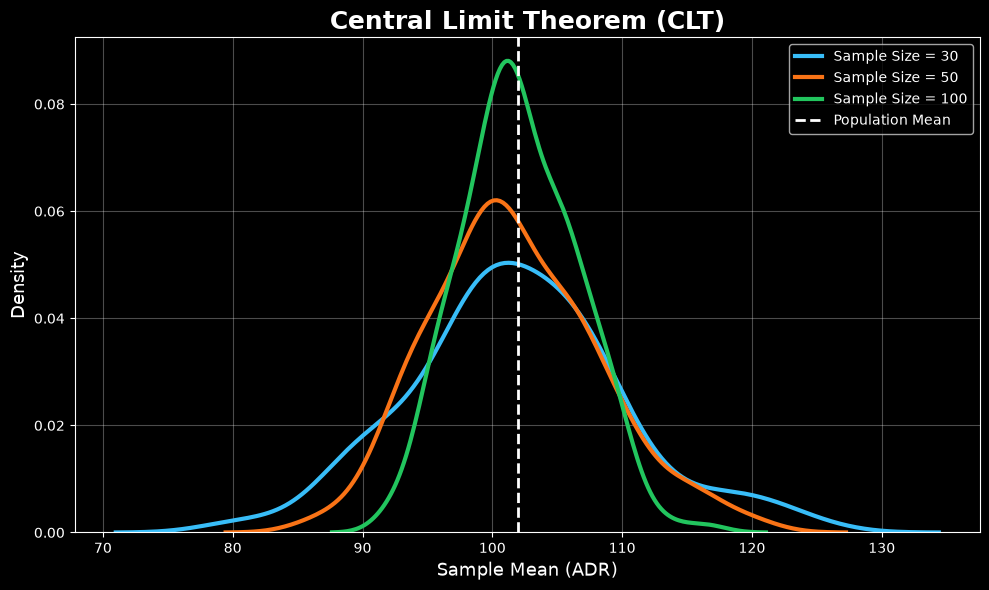

In [173]:
# CLT visualization

plt.style.use("dark_background")

plt.figure(figsize=(10,6))

colors = ["#38BDF8", "#F97316", "#22C55E"]

for size, color in zip(sample_sizes, colors):

    sns.kdeplot(
        sample_means_dict[size],
        linewidth=3,
        color=color,
        label=f"Sample Size = {size}"
    )

plt.axvline(
    hotel_df["adr"].mean(),
    color="white",
    linestyle="--",
    linewidth=2,
    label="Population Mean"
)

plt.title(
    "Central Limit Theorem (CLT)",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Sample Mean (ADR)", fontsize=13)

plt.ylabel("Density", fontsize=13)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

The Central Limit Theorem is demonstrated by comparing sampling distributions for sample sizes of **30, 50, and 100**.

As the sample size increases:

- The sampling distributions become more symmetric and approximately normal.
- The sample means remain close to the population mean.
- The variability of the sample means decreases, resulting in more precise estimates of the population mean.

This demonstrates that larger sample sizes provide more reliable estimates, supporting accurate statistical inference and decision-making in hotel booking analysis.

## Confidence Intervals

A confidence interval is a range of values that is likely to contain the true population parameter with a specified confidence level.

In this analysis, a **95% confidence interval** is calculated for the Average Daily Rate (ADR) to estimate the population mean.

In [174]:
# calculate 95% confidence interval

from scipy.stats import sem, t

# Sample data
sample = hotel_df["adr"]

# Sample size
n = len(sample)

# Sample mean
mean = sample.mean()

# Standard Error
standard_error = sem(sample)

# 95% Confidence Interval
confidence = 0.95

confidence_interval = t.interval(
    confidence,
    df=n-1,
    loc=mean,
    scale=standard_error
)

print("Sample Mean :", round(mean,2))

print("95% Confidence Interval :")

print("Lower Bound :", round(confidence_interval[0],2))

print("Upper Bound :", round(confidence_interval[1],2))

Sample Mean : 101.94
95% Confidence Interval :
Lower Bound : 101.64
Upper Bound : 102.24


In [175]:
# confidence interval summary

confidence_df = pd.DataFrame({

    "Statistic":[
        "Sample Mean",
        "Lower Confidence Limit",
        "Upper Confidence Limit"
    ],

    "Value":[
        mean,
        confidence_interval[0],
        confidence_interval[1]
    ]

})

confidence_df.round(2)

,Statistic,Value
0,Sample Mean,101.94
1,Lower Confidence Limit,101.64
2,Upper Confidence Limit,102.24


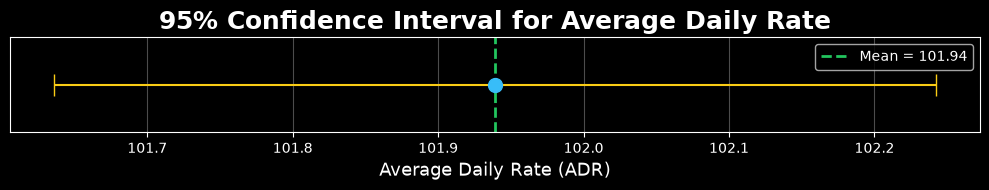

In [176]:
# confidence interval visualization

plt.style.use("dark_background")

plt.figure(figsize=(10,2))

plt.errorbar(
    x=mean,
    y=0,
    xerr=[[mean-confidence_interval[0]],
          [confidence_interval[1]-mean]],
    fmt='o',
    color="#38BDF8",
    ecolor="#FACC15",
    capsize=8,
    markersize=10
)

plt.axvline(
    mean,
    color="#22C55E",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean:.2f}"
)

plt.yticks([])

plt.xlabel("Average Daily Rate (ADR)", fontsize=13)

plt.title(
    "95% Confidence Interval for Average Daily Rate",
    fontsize=18,
    fontweight="bold"
)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Population vs Sample

In [177]:
population_size = len(hotel_df)

sample_size = 100

population_sample_df = pd.DataFrame({

    "Category":[
        "Population",
        "Sample"
    ],

    "Number of Records":[
        population_size,
        sample_size
    ]

})

population_sample_df

,Category,Number of Records
0,Population,84705
1,Sample,100


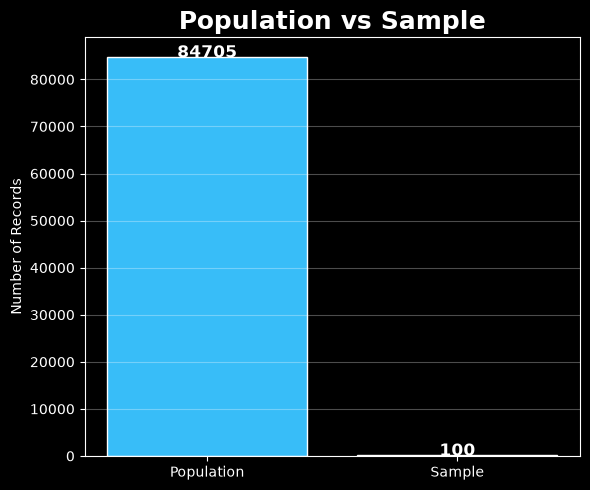

In [178]:
plt.style.use("dark_background")

plt.figure(figsize=(6,5))

bars = plt.bar(
    population_sample_df["Category"],
    population_sample_df["Number of Records"],
    color=["#38BDF8", "#22C55E"],
    edgecolor="white"
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Population vs Sample",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel("Number of Records")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

## Sampling Techniques

Sampling is the process of selecting a subset of observations from a population for statistical analysis.

Common sampling techniques include:

- Simple Random Sampling
- Systematic Sampling
- Stratified Sampling
- Cluster Sampling



In [179]:
# generate a random sample
sample_data = hotel_df.sample(
    n=100,
    random_state=42
)

print("Population Size :", len(hotel_df))

print("Sample Size :", len(sample_data))

sample_data.head()

Population Size : 84705
Sample Size : 100


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,lead_time_category,stay_type,booking_season,customer_group,estimated_booking_revenue,booking_size,special_request_level,booking_change_category,parking_required,booking_value_segment
9697,1,1,0,2017,August,33,17,0,1,2,...,Short,Weekday Stay,Summer,New Guest,200.0,Couple,No Requests,No Changes,No Parking,Medium Value
3393,1,1,46,2016,March,11,11,0,1,1,...,Medium,Weekday Stay,Spring,New Guest,25.0,Solo Traveler,No Requests,No Changes,No Parking,Low Value
8063,1,1,211,2017,April,17,24,3,6,2,...,Very Long,Weekday Stay,Spring,New Guest,486.0,Couple,Few Requests,No Changes,No Parking,Premium Value
32927,0,0,0,2015,August,34,17,1,0,2,...,Short,Weekend Stay,Summer,New Guest,124.0,Couple,No Requests,Few Changes,No Parking,Low Value
12945,1,0,59,2015,October,43,18,1,0,2,...,Medium,Weekend Stay,Autumn,New Guest,56.0,Couple,Few Requests,No Changes,No Parking,Low Value


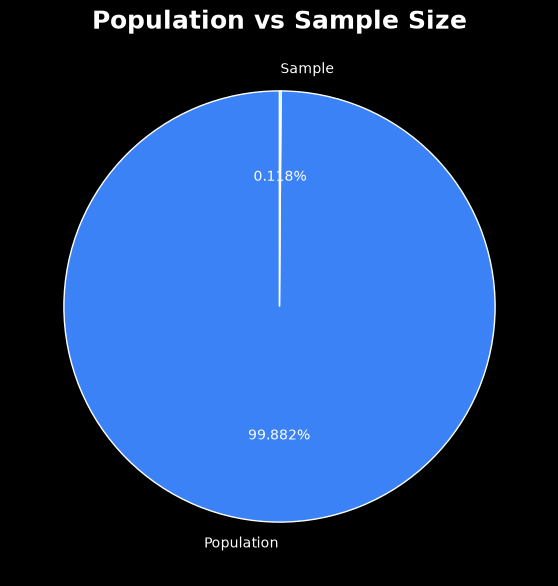

In [180]:
# visualization

plt.style.use("dark_background")

sizes = [len(hotel_df), len(sample_data)]

labels = ["Population", "Sample"]

colors = ["#3B82F6", "#22C55E"]

plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    autopct="%1.3f%%",
    startangle=90,
    colors=colors,
    wedgeprops={
        "edgecolor":"white"
    }
)

plt.title(
    "Population vs Sample Size",
    fontsize=18,
    fontweight="bold"
)

plt.show()

## Point Estimation

Point estimation is the process of using a single sample statistic to estimate an unknown population parameter.

The sample mean of the Average Daily Rate (ADR) is used as the point estimate for the population mean.

In [181]:
point_estimate = hotel_df["adr"].mean()

print("Point Estimate (Sample Mean):", round(point_estimate,2))

Point Estimate (Sample Mean): 101.94


In [182]:
# summary table

point_df = pd.DataFrame({

    "Parameter":[
        "Population Parameter",
        "Point Estimate"
    ],

    "Value":[
        "Unknown Population Mean",
        round(point_estimate,2)
    ]

})

point_df

,Parameter,Value
0,Population Parameter,Unknown Population Mean
1,Point Estimate,101.94


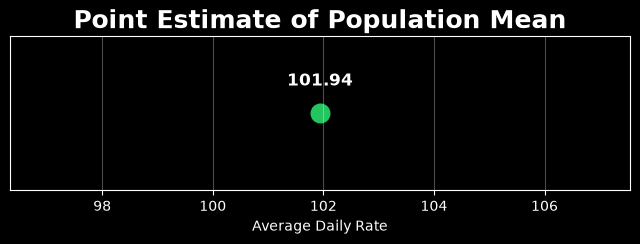

In [183]:
plt.style.use("dark_background")

plt.figure(figsize=(8,2))

plt.scatter(
    point_estimate,
    1,
    s=180,
    color="#22C55E"
)

plt.text(
    point_estimate,
    1.02,
    f"{point_estimate:.2f}",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

plt.yticks([])

plt.xlabel("Average Daily Rate")

plt.title(
    "Point Estimate of Population Mean",
    fontsize=18,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.show()

## Confidence Level and Margin of Error

The confidence level indicates the probability that the calculated confidence interval contains the true population parameter.

The margin of error measures the maximum expected difference between the sample estimate and the actual population parameter.

In [184]:
from scipy.stats import sem

confidence_level = 0.95

z_value = 1.96

standard_error = sem(hotel_df["adr"])

margin_error = z_value * standard_error

print("Confidence Level :", confidence_level)

print("Margin of Error :", round(margin_error,2))

Confidence Level : 0.95
Margin of Error : 0.3


In [185]:
moe_df = pd.DataFrame({

    "Statistic":[
        "Confidence Level",
        "Margin of Error"
    ],

    "Value":[
        "95%",
        round(margin_error,2)
    ]

})

moe_df

,Statistic,Value
0,Confidence Level,95%
1,Margin of Error,0.3


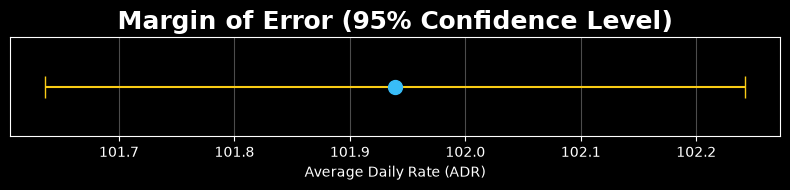

In [186]:
plt.style.use("dark_background")

plt.figure(figsize=(8,2))

plt.errorbar(
    x=hotel_df["adr"].mean(),
    y=0,
    xerr=margin_error,
    fmt="o",
    color="#38BDF8",
    ecolor="#FACC15",
    capsize=8,
    markersize=10
)

plt.yticks([])

plt.xlabel("Average Daily Rate (ADR)")

plt.title(
    "Margin of Error (95% Confidence Level)",
    fontsize=18,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# Phase 4 – Assumption Testing

## Objective

Before performing hypothesis testing, it is essential to verify that the data satisfies the assumptions required for statistical tests.

This phase evaluates the following assumptions:

- Normality Test (Shapiro–Wilk Test)
- Homogeneity of Variance (Levene's Test)
- Independence Check
- Correlation Analysis
- Multicollinearity Check (Variance Inflation Factor)
- QQ Plot
- Residual Plot
- Pair Plot
- Correlation Matrix

Validating these assumptions ensures that appropriate statistical tests are selected and that the resulting conclusions are reliable.

In [187]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro
from scipy.stats import levene

import statsmodels.api as sm

from statsmodels.graphics.gofplots import qqplot

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [188]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



### Hypotheses

**Null Hypothesis (H₀):**
The data follows a normal distribution.

**Alternative Hypothesis (H₁):**
The data does not follow a normal distribution.

Decision Rule:

- **p-value > 0.05:** Fail to reject H₀ (Data is approximately normal)
- **p-value ≤ 0.05:** Reject H₀ (Data is not normally distributed)

In [189]:
# Shapiro–Wilk Test
np.random.seed(42)

adr_sample = hotel_df["adr"].sample(
    n=5000,
    random_state=42
)

statistic, p_value = shapiro(adr_sample)

print("Shapiro-Wilk Statistic :", round(statistic,4))

print("P-value :", p_value)


Shapiro-Wilk Statistic : 0.9846
P-value : 6.061336206850954e-23


In [190]:
# decision

if p_value > 0.05:

    print("Fail to Reject Null Hypothesis")

    print("ADR follows a Normal Distribution.")

else:

    print("Reject Null Hypothesis")

    print("ADR does NOT follow a Normal Distribution.")

Reject Null Hypothesis
ADR does NOT follow a Normal Distribution.


In [191]:
# summary table
normality_df = pd.DataFrame({

    "Test":[
        "Shapiro-Wilk"
    ],

    "Statistic":[
        statistic
    ],

    "P-value":[
        p_value
    ]

})

normality_df.round(4)

,Test,Statistic,P-value
0,Shapiro-Wilk,0.9846,0.0


<Figure size 700x700 with 0 Axes>

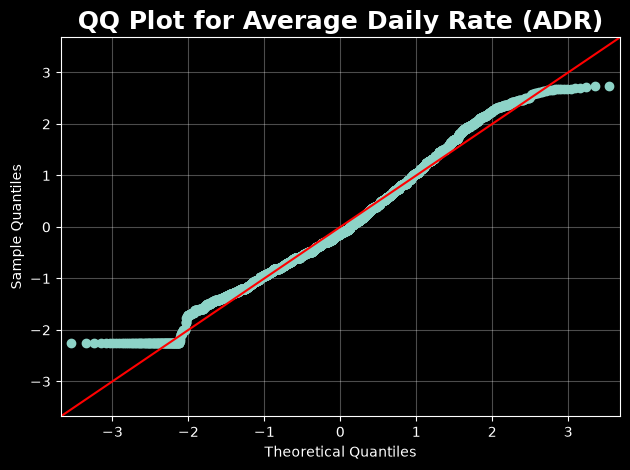

In [192]:
# QQ plot

from statsmodels.graphics.gofplots import qqplot

plt.style.use("dark_background")

plt.figure(figsize=(7,7))

qqplot(
    adr_sample,
    line="45",
    fit=True
)

plt.title(
    "QQ Plot for Average Daily Rate (ADR)",
    fontsize=18,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Homogeneity of Variance (Levene's Test)

Levene's Test is used to determine whether two or more groups have equal variances.

### Hypotheses

**Null Hypothesis (H₀):**
The variances of the groups are equal.

**Alternative Hypothesis (H₁):**
The variances of the groups are not equal.

Decision Rule:

- **p-value > 0.05:** Variances are homogeneous (equal).
- **p-value ≤ 0.05:** Variances are significantly different.

In [193]:
#Compare ADR Variance Between Hotel Types(0=city hotel, 1=resort hotel)

city_adr = hotel_df[
    hotel_df["hotel"] == 0
]["adr"]

resort_adr = hotel_df[
    hotel_df["hotel"] == 1
]["adr"]

statistic, p_value = levene(
    city_adr,
    resort_adr
)

print("Levene Statistic :", round(statistic,4))

print("P-value :", p_value)

Levene Statistic : 3113.0008
P-value : 0.0


In [194]:
# summary table

levene_df = pd.DataFrame({

    "Test":[
        "Levene Test"
    ],

    "Statistic":[
        statistic
    ],

    "P-value":[
        p_value
    ]

})

levene_df.round(4)

,Test,Statistic,P-value
0,Levene Test,3113.0008,0.0


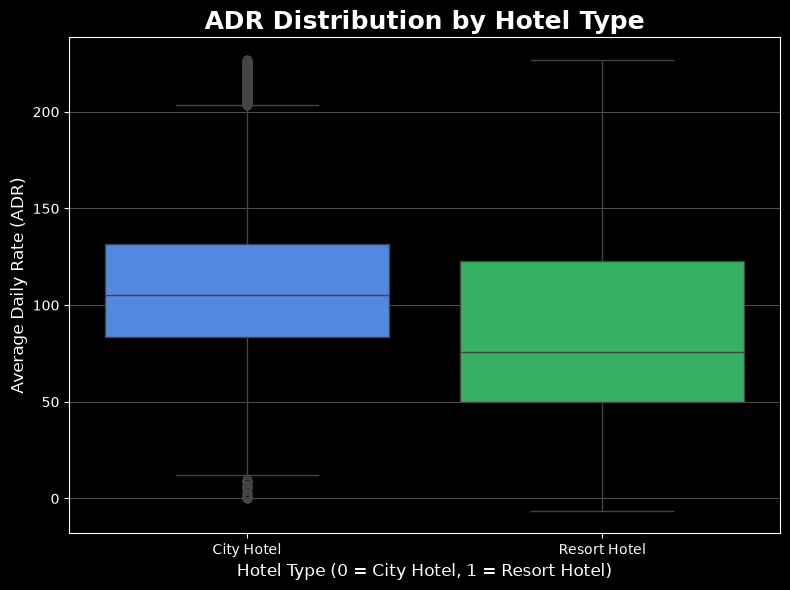

In [195]:
plt.style.use("dark_background")

plt.figure(figsize=(8,6))

sns.boxplot(
    data=hotel_df,
    x="hotel",
    y="adr",
    hue="hotel",
    palette=["#3B82F6", "#22C55E"],
    legend=False
)

plt.title(
    "ADR Distribution by Hotel Type",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Hotel Type (0 = City Hotel, 1 = Resort Hotel)",
    fontsize=12
)

plt.ylabel(
    "Average Daily Rate (ADR)",
    fontsize=12
)

plt.xticks(
    [0, 1],
    ["City Hotel", "Resort Hotel"]
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

## Independence Check

The independence assumption states that each observation in the dataset should be independent of all other observations.

In the Hotel Booking Demand dataset, each row represents a unique hotel booking. Since duplicate records were removed during preprocessing and each booking corresponds to a separate reservation, the observations can reasonably be considered independent.

This assumption is important for statistical tests such as the independent t-test, ANOVA, and regression analysis.

In [196]:
# verify duplicate records

duplicate_count = hotel_df.duplicated().sum()

print("Duplicate Records :", duplicate_count)

Duplicate Records : 0


In [197]:
# unique booking recors

print("Total Records :", len(hotel_df))

print("Unique Records :", len(hotel_df.drop_duplicates()))

Total Records : 84705
Unique Records : 84705


In [198]:
# summary table

independence_df = pd.DataFrame({

    "Check":[
        "Total Records",
        "Duplicate Records",
        "Unique Records"
    ],

    "Value":[
        len(hotel_df),
        duplicate_count,
        len(hotel_df.drop_duplicates())
    ]

})

independence_df

,Check,Value
0,Total Records,84705
1,Duplicate Records,0
2,Unique Records,84705


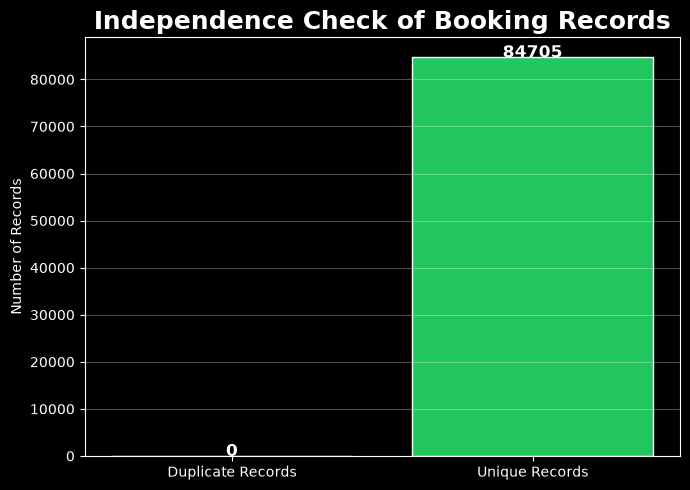

In [199]:
# visualization

plt.style.use("dark_background")

plt.figure(figsize=(7,5))

values = [
    duplicate_count,
    len(hotel_df.drop_duplicates())
]

labels = [
    "Duplicate Records",
    "Unique Records"
]

colors = [
    "#EF4444",
    "#22C55E"
]

bars = plt.bar(
    labels,
    values,
    color=colors,
    edgecolor="white"
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{int(bar.get_height())}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

plt.title(
    "Independence Check of Booking Records",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel("Number of Records")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

The independence assumption was evaluated by examining duplicate records in the processed hotel booking dataset.

After preprocessing, **no duplicate records** were found, indicating that each observation represents a unique hotel booking.

Therefore, the independence assumption is considered to be satisfied for this dataset. This supports the use of inferential statistical techniques that require independent observations.

## Correlation Analysis

Correlation analysis measures the strength and direction of the relationship between two numerical variables.

The Pearson Correlation Coefficient (r) ranges from **-1 to +1**.

- **+1** : Perfect Positive Correlation
- **0** : No Correlation
- **-1** : Perfect Negative Correlation

Correlation analysis helps identify variables that move together and supports feature selection before statistical modeling.

In [200]:
# select numeric variables

numerical_columns = [

    "lead_time",

    "stays_in_weekend_nights",

    "stays_in_week_nights",

    "adults",

    "children",

    "babies",

    "previous_cancellations",

    "previous_bookings_not_canceled",

    "booking_changes",

    "adr",

    "total_of_special_requests",

    "total_stay_duration",

    "total_guests",

    "estimated_booking_revenue"

]

correlation_matrix = hotel_df[numerical_columns].corr()

correlation_matrix.round(2)

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,previous_bookings_not_canceled,booking_changes,adr,total_of_special_requests,total_stay_duration,total_guests,estimated_booking_revenue
lead_time,1.00,0.23,0.31,0.14,0.03,-0.00,0.01,-0.08,0.08,0.04,0.04,0.32,0.13,0.27
stays_in_weekend_nights,0.23,1.00,0.55,0.09,0.03,0.01,-0.02,-0.06,0.03,0.04,0.03,0.78,0.09,0.61
stays_in_week_nights,0.31,0.55,1.00,0.10,0.03,0.02,-0.02,-0.06,0.07,0.05,0.04,0.95,0.10,0.74
adults,0.14,0.09,0.10,1.00,0.01,0.02,-0.04,-0.12,-0.04,0.25,0.11,0.11,0.82,0.19
children,0.03,0.03,0.03,0.01,1.00,0.02,-0.02,-0.03,0.03,0.26,0.05,0.03,0.56,0.17
babies,-0.00,0.01,0.02,0.02,0.02,1.00,-0.01,-0.01,0.08,0.02,0.09,0.02,0.17,0.03
previous_cancellations,0.01,-0.02,-0.02,-0.04,-0.02,-0.01,1.00,0.39,-0.01,-0.05,0.00,-0.02,-0.04,-0.04
previous_bookings_not_canceled,-0.08,-0.06,-0.06,-0.12,-0.03,-0.01,0.39,1.00,0.01,-0.10,0.03,-0.07,-0.12,-0.08
booking_changes,0.08,0.03,0.07,-0.04,0.03,0.08,-0.01,0.01,1.00,-0.01,0.01,0.06,-0.00,0.04
adr,0.04,0.04,0.05,0.25,0.26,0.02,-0.05,-0.10,-0.01,1.00,0.15,0.05,0.35,0.52


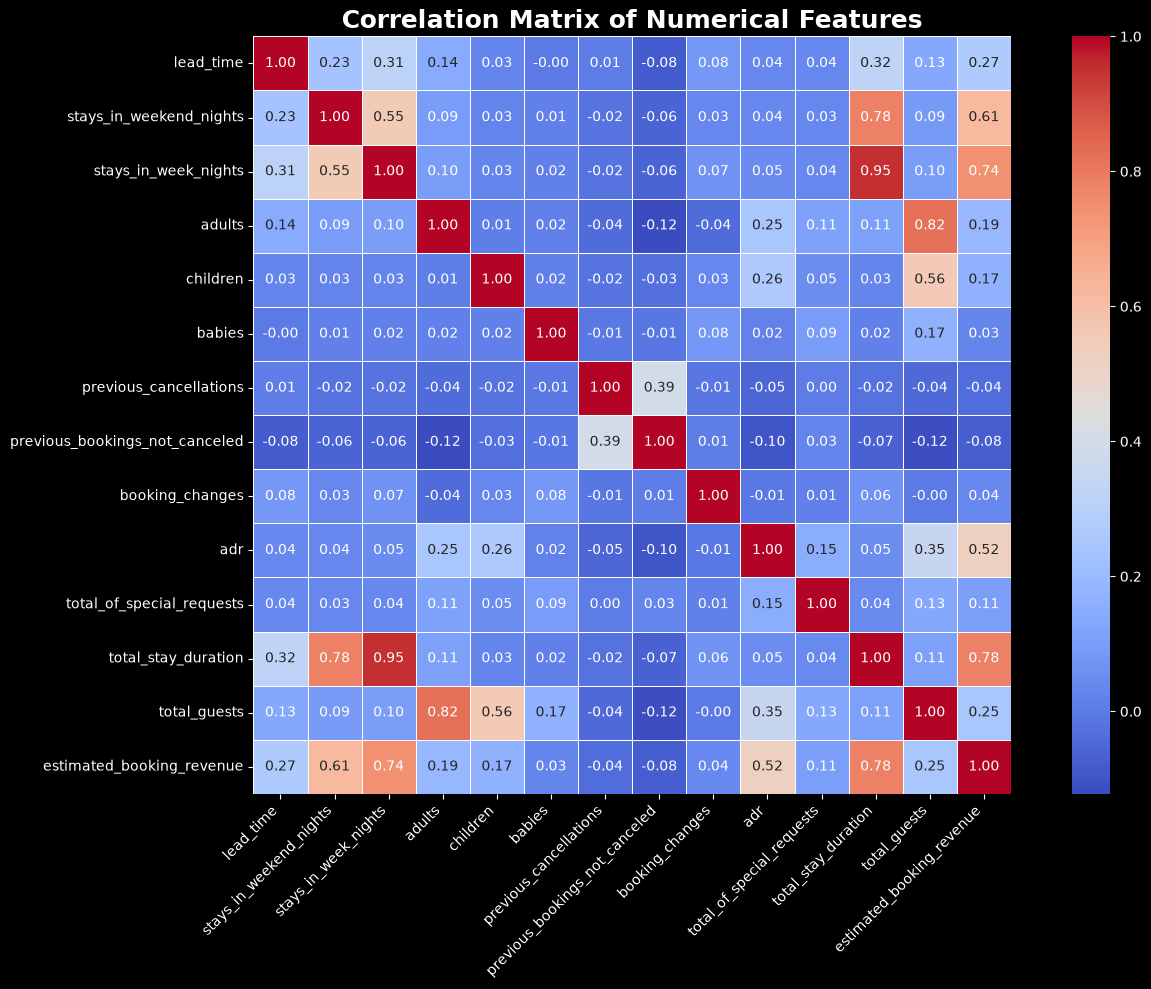

In [201]:
# Correlation Heatmap (Required Visualization)

plt.style.use("dark_background")

plt.figure(figsize=(14,10))

sns.heatmap(

    correlation_matrix,

    annot=True,

    fmt=".2f",

    cmap="coolwarm",

    linewidths=0.5,

    square=True,

    cbar=True

)

plt.title(

    "Correlation Matrix of Numerical Features",

    fontsize=18,

    fontweight="bold"

)

plt.xticks(rotation=45, ha="right")

plt.yticks(rotation=0)

plt.tight_layout()

# Save image
plt.savefig(
    "static/images/correlation_analysis.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

In [202]:
# Identify Strong positive Correlations
corr_pairs = (

    correlation_matrix

    .unstack()

    .sort_values(ascending=False)

)

corr_pairs = corr_pairs[

    (corr_pairs < 1.0) &

    (abs(corr_pairs) >= 0.70)

]

corr_pairs


stays_in_week_nights       total_stay_duration          0.949945
total_stay_duration        stays_in_week_nights         0.949945
total_guests               adults                       0.823681
adults                     total_guests                 0.823681
total_stay_duration        stays_in_weekend_nights      0.783784
stays_in_weekend_nights    total_stay_duration          0.783784
total_stay_duration        estimated_booking_revenue    0.783556
estimated_booking_revenue  total_stay_duration          0.783556
stays_in_week_nights       estimated_booking_revenue    0.744175
estimated_booking_revenue  stays_in_week_nights         0.744175
dtype: float64

In [203]:
# summary table

highest_corr = correlation_matrix.abs().unstack()

highest_corr = highest_corr.sort_values(ascending=False)

highest_corr = highest_corr[highest_corr < 1]

highest_corr_df = highest_corr.reset_index()

highest_corr_df.columns = [

    "Feature 1",

    "Feature 2",

    "Correlation"

]

highest_corr_df.head(10)

,Feature 1,Feature 2,Correlation
0,total_stay_duration,stays_in_week_nights,0.949945
1,stays_in_week_nights,total_stay_duration,0.949945
2,adults,total_guests,0.823681
3,total_guests,adults,0.823681
4,total_stay_duration,stays_in_weekend_nights,0.783784
5,stays_in_weekend_nights,total_stay_duration,0.783784
6,total_stay_duration,estimated_booking_revenue,0.783556
7,estimated_booking_revenue,total_stay_duration,0.783556
8,stays_in_week_nights,estimated_booking_revenue,0.744175
9,estimated_booking_revenue,stays_in_week_nights,0.744175


In [204]:
# strong negative ccorrealtion
negative_corr = (

    correlation_matrix

    .unstack()

    .sort_values()

)

negative_corr = negative_corr[

    negative_corr <= -0.70

]

negative_corr

Series([], dtype: float64)

In [205]:
# top 10 strongest correlations

highest_corr = correlation_matrix.abs().unstack()

highest_corr = highest_corr.sort_values(ascending=False)

highest_corr = highest_corr[highest_corr < 1]

highest_corr_df = highest_corr.reset_index()

highest_corr_df.columns = [

    "Feature 1",

    "Feature 2",

    "Correlation"

]

highest_corr_df.head(10)

,Feature 1,Feature 2,Correlation
0,total_stay_duration,stays_in_week_nights,0.949945
1,stays_in_week_nights,total_stay_duration,0.949945
2,adults,total_guests,0.823681
3,total_guests,adults,0.823681
4,total_stay_duration,stays_in_weekend_nights,0.783784
5,stays_in_weekend_nights,total_stay_duration,0.783784
6,total_stay_duration,estimated_booking_revenue,0.783556
7,estimated_booking_revenue,total_stay_duration,0.783556
8,stays_in_week_nights,estimated_booking_revenue,0.744175
9,estimated_booking_revenue,stays_in_week_nights,0.744175


### Interpretation

The correlation analysis revealed several strong positive relationships among the numerical variables in the hotel booking dataset.

The strongest correlation (**0.95**) was observed between **Total Stay Duration** and **Stays in Week Nights**, which is expected because the total stay duration is calculated using weekday and weekend stays.

A strong positive relationship (**0.82**) was also found between **Adults** and **Total Guests**, indicating that adults constitute the majority of guests in most hotel bookings.

Additionally, **Estimated Booking Revenue** exhibited strong positive correlations with **Total Stay Duration** and **Stays in Week Nights**, reflecting that longer stays generally generate higher booking revenue.

No strong negative correlations were identified, indicating that none of the selected numerical variables exhibit a strong inverse linear relationship.

These findings provide valuable insights into feature relationships and serve as a basis for the subsequent multicollinearity assessment using the Variance Inflation Factor (VIF).

## Multicollinearity Check (Variance Inflation Factor)

Multicollinearity occurs when two or more independent variables are highly correlated with each other.

The **Variance Inflation Factor (VIF)** measures the degree of multicollinearity among numerical variables.

### Interpretation of VIF

- **VIF = 1** : No multicollinearity
- **VIF between 1 and 5** : Moderate correlation (acceptable)
- **VIF between 5 and 10** : High correlation
- **VIF > 10** : Severe multicollinearity

In [206]:
# select fetaures

vif_features = hotel_df[[
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "adr",
    "total_of_special_requests",
    "total_stay_duration",
    "total_guests"
]].copy()

In [207]:
# calculate VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()

vif["Feature"] = vif_features.columns

vif["VIF"] = [
    variance_inflation_factor(
        vif_features.values,
        i
    )
    for i in range(vif_features.shape[1])
]

vif = vif.sort_values(
    by="VIF",
    ascending=False
)

vif.round(2)


,Feature,VIF
1,stays_in_weekend_nights,inf
2,stays_in_week_nights,inf
3,adults,inf
4,children,inf
5,babies,inf
11,total_stay_duration,inf
12,total_guests,inf
9,adr,5.99
0,lead_time,2.12
10,total_of_special_requests,1.77


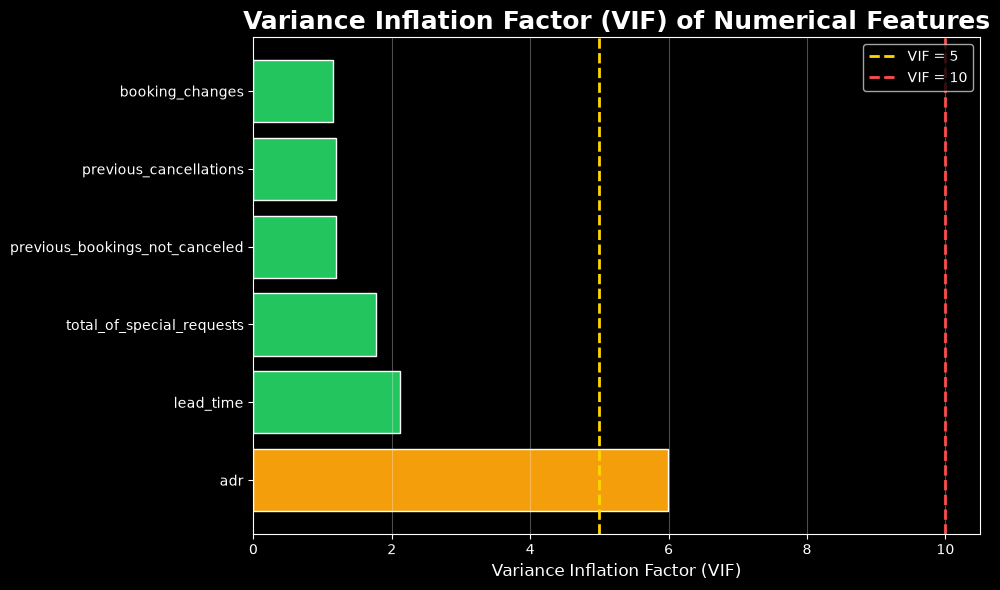

In [208]:
# VIF bar chart

plt.style.use("dark_background")

plt.figure(figsize=(10,6))

colors = [
    "#EF4444" if x > 10
    else "#F59E0B" if x > 5
    else "#22C55E"
    for x in vif["VIF"]
]

plt.barh(
    vif["Feature"],
    vif["VIF"],
    color=colors,
    edgecolor="white"
)

plt.axvline(
    5,
    color="#FFD700",
    linestyle="--",
    linewidth=2,
    label="VIF = 5"
)

plt.axvline(
    10,
    color="#FF4D4D",
    linestyle="--",
    linewidth=2,
    label="VIF = 10"
)

plt.xlabel("Variance Inflation Factor (VIF)", fontsize=12)

plt.title(
    "Variance Inflation Factor (VIF) of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.legend()

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

The Variance Inflation Factor (VIF) was calculated to assess multicollinearity among the numerical variables.

Several variables, including **Total Stay Duration** and **Total Guests**, produced infinite (∞) VIF values. This is expected because these features were created through feature engineering and are exact linear combinations of existing variables.

For example:

- Total Stay Duration = Stays in Weekend Nights + Stays in Week Nights
- Total Guests = Adults + Children + Babies

Such deterministic relationships result in perfect multicollinearity, causing the VIF to become infinite.

The remaining variables showed acceptable VIF values. For example, **Lead Time (2.12)** and **Total Special Requests (1.77)** indicate low multicollinearity, while **ADR (5.99)** suggests moderate multicollinearity.

These results are expected for a feature-engineered dataset and should be considered when selecting variables for predictive regression models.

## Residual Plot



A residual plot is used to examine whether the residuals (errors) from a regression model are randomly distributed.

A random scatter of residuals around zero indicates that the assumptions of linearity and constant variance are reasonably satisfied.

Residual plots are commonly used to evaluate the suitability of linear regression models.

In [209]:
# Fit a Simple Linear Regression

#Independent Variable → Lead Time, Dependent Variable → ADR

import statsmodels.api as sm

X = hotel_df["lead_time"]

y = hotel_df["adr"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    adr   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     124.4
Date:                Thu, 16 Jul 2026   Prob (F-statistic):           7.31e-29
Time:                        13:30:56   Log-Likelihood:            -4.4260e+05
No. Observations:               84705   AIC:                         8.852e+05
Df Residuals:                   84703   BIC:                         8.852e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        100.3396      0.211    475.872      0.0

In [210]:
# calculate residuals

predicted = model.predict(X)

residuals = y - predicted

print(residuals.head())

0   -107.157019
1   -115.030922
2    -25.479151
3    -25.598754
4     -2.618688
dtype: float64


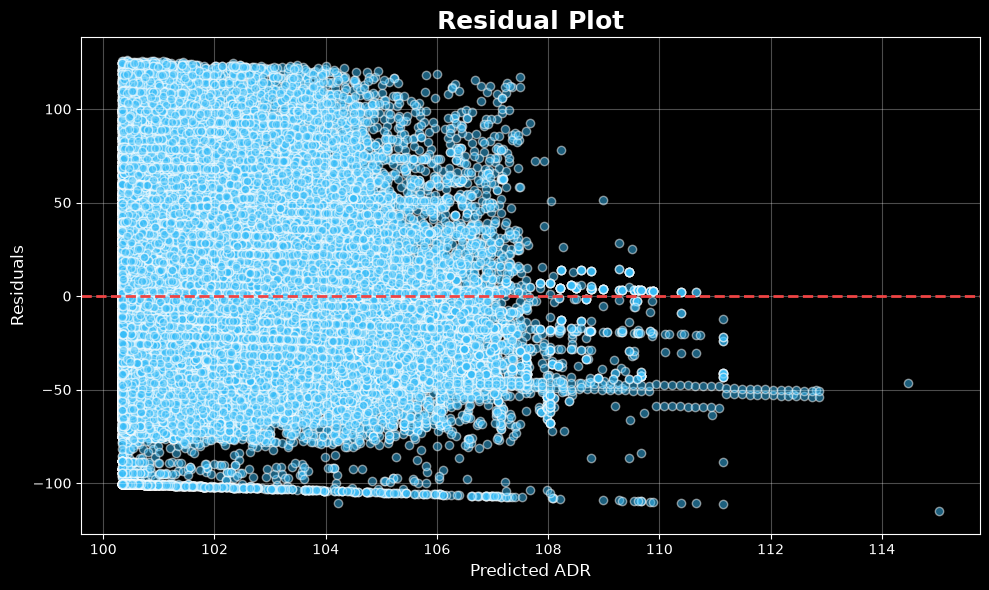

In [211]:
# residual plot
plt.style.use("dark_background")

plt.figure(figsize=(10,6))

plt.scatter(

    predicted,

    residuals,

    color="#38BDF8",

    alpha=0.5,

    edgecolors="white"

)

plt.axhline(

    y=0,

    color="#EF4444",

    linestyle="--",

    linewidth=2

)

plt.title(

    "Residual Plot",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel(

    "Predicted ADR",

    fontsize=12

)

plt.ylabel(

    "Residuals",

    fontsize=12

)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

The residual plot displays the difference between the observed ADR values and the predicted ADR values.

The residuals are scattered around the horizontal reference line at zero without forming a strong systematic pattern.

This indicates that the linear model does not exhibit obvious bias, although some variability exists due to the complexity of hotel booking behavior.

## Pair Plot

A pair plot provides pairwise relationships among numerical variables.

It simultaneously displays scatter plots for variable pairs and distribution plots along the diagonal, making it useful for identifying trends, clusters, and potential outliers.

In [212]:
# select important features

pair_df = hotel_df[[

    "lead_time",

    "adr",

    "total_stay_duration",

    "total_guests",

    "estimated_booking_revenue"

]]

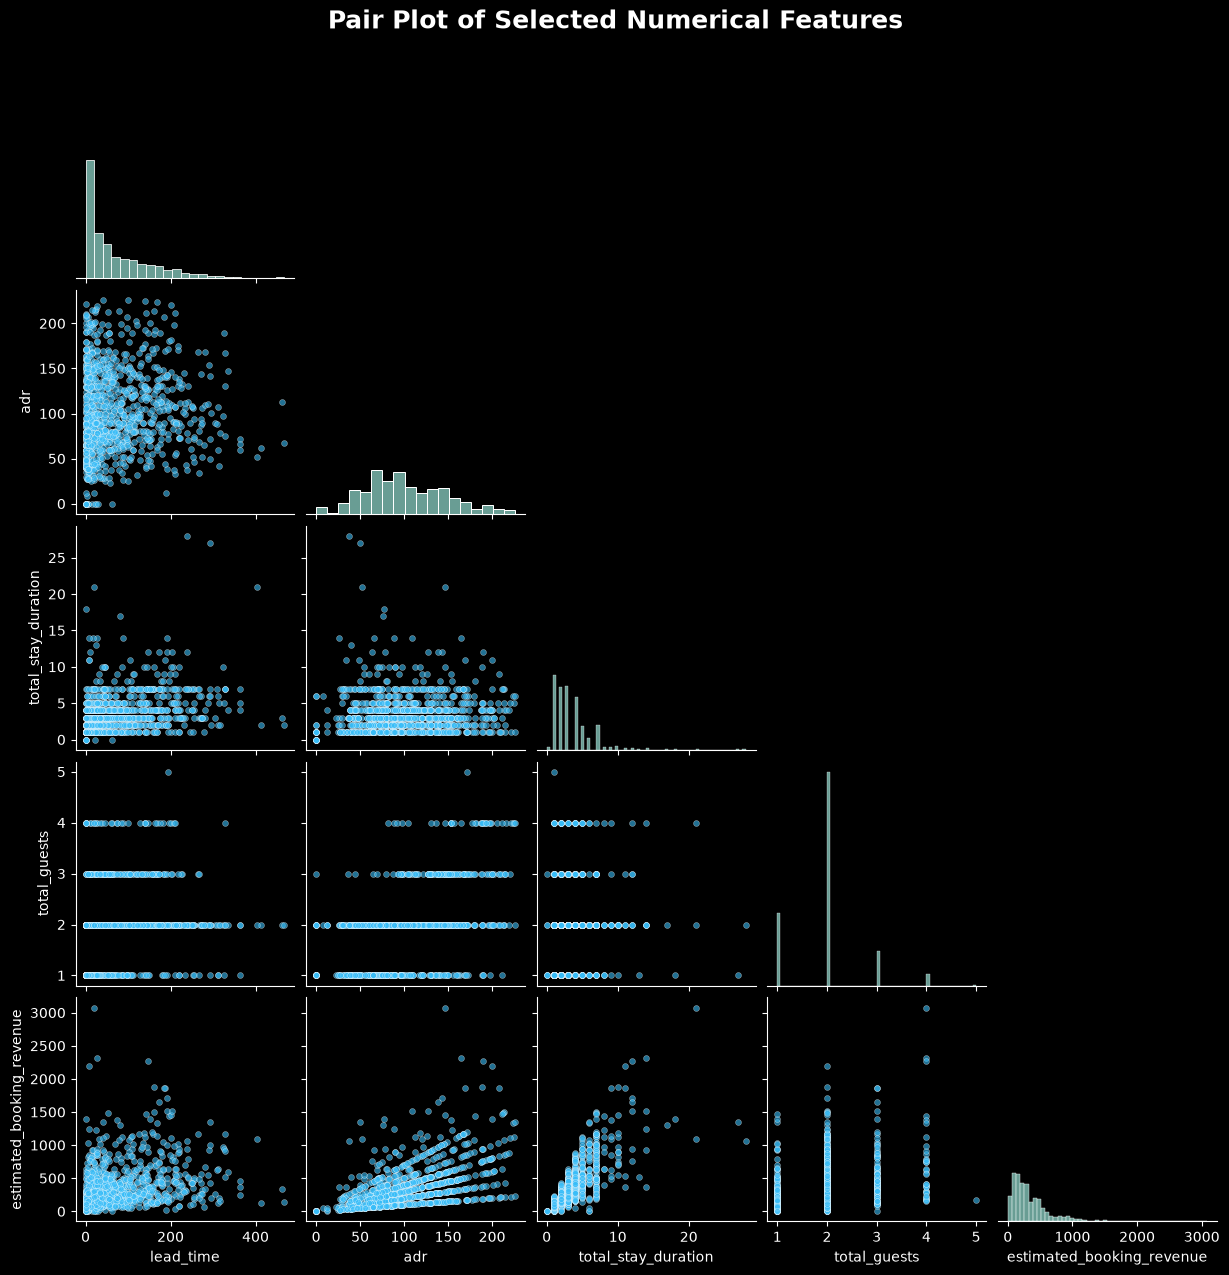

In [213]:
# pair plot (dataset is large (84,705 rows), use a sample for better performance.)

pair_sample = pair_df.sample(

    n=1000,

    random_state=42

)

sns.pairplot(

    pair_sample,

    diag_kind="hist",

    corner=True,

    plot_kws={

        "alpha":0.6,

        "s":18,

        "color":"#38BDF8"

    }

)

plt.suptitle(

    "Pair Plot of Selected Numerical Features",

    y=1.02,

    fontsize=18,

    fontweight="bold"

)

plt.show()

The pair plot illustrates pairwise relationships among key numerical variables.

Strong positive relationships are visible between **Estimated Booking Revenue** and **Total Stay Duration**, while weaker relationships are observed for variables such as **Lead Time** and **ADR**.

The diagonal histograms show the distribution of each variable, providing additional insight into data spread and potential skewness.

# Phase 5 – Statistical Testing

## Objective

Statistical hypothesis testing is performed to determine whether observed differences or relationships in the hotel booking dataset are statistically significant.

Both **parametric** and **non-parametric** statistical tests are conducted based on the assumptions validated in Phase 4.

Each statistical test includes:

- Null and Alternative Hypotheses
- Assumption Validation
- Test Selection
- Test Statistic
- P-value
- Decision
- Business Interpretation

## Independent t-Test

The Independent t-Test compares the mean Average Daily Rate (ADR) between **City Hotels** and **Resort Hotels**.

### Null Hypothesis (H₀)

There is **no significant difference** in the mean ADR between City Hotels and Resort Hotels.

### Alternative Hypothesis (H₁)

There **is a significant difference** in the mean ADR between City Hotels and Resort Hotels.

### Assumption Validation

- Independent observations ✔
- Numerical dependent variable (ADR) ✔
- Normality tested using Shapiro–Wilk ✔
- Homogeneity of variance tested using Levene's Test ✔

Since Levene's Test indicated unequal variances (p ≤ 0.05), **Welch's Independent t-Test** will be used (`equal_var=False`).

In [214]:
# perform the test

from scipy.stats import ttest_ind

city = hotel_df[
    hotel_df["hotel"] == 0
]["adr"]

resort = hotel_df[
    hotel_df["hotel"] == 1
]["adr"]

t_stat, p_value = ttest_ind(
    city,
    resort,
    equal_var=False
)

print("T Statistic :", round(t_stat,4))

print("P-value :", p_value)

T Statistic : 55.8138
P-value : 0.0


In [215]:
# decision

if p_value < 0.05:

    print("Reject Null Hypothesis")

    print("There is a significant difference in ADR between hotel types.")

else:

    print("Fail to Reject Null Hypothesis")

    print("No significant difference exists.")

Reject Null Hypothesis
There is a significant difference in ADR between hotel types.


In [216]:
# summary table

ttest_df = pd.DataFrame({

    "Test":[
        "Independent t-Test"
    ],

    "T Statistic":[
        round(t_stat,4)
    ],

    "P-value":[
        p_value
    ]

})

ttest_df

,Test,T Statistic,P-value
0,Independent t-Test,55.8138,0.0


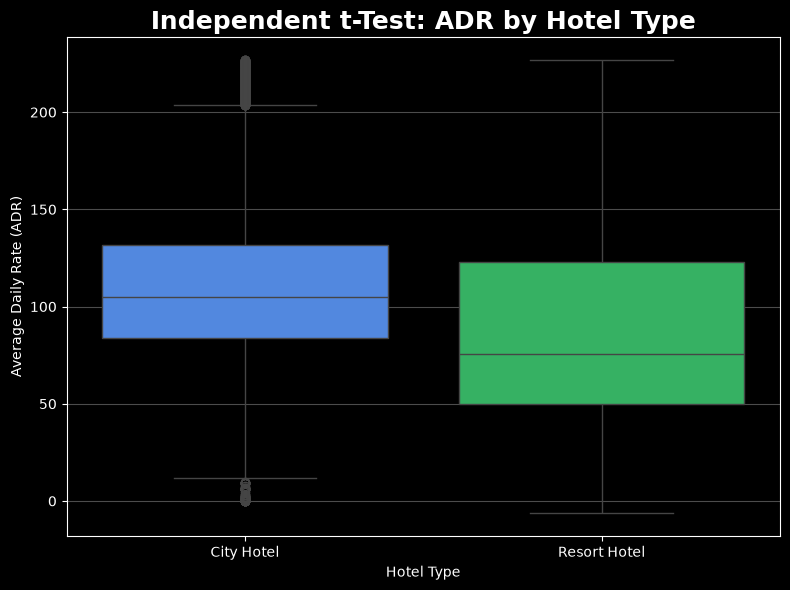

In [217]:
plt.style.use("dark_background")

plt.figure(figsize=(8,6))

sns.boxplot(

    data=hotel_df,

    x="hotel",

    y="adr",

    hue="hotel",

    palette=["#3B82F6","#22C55E"],

    legend=False

)

plt.xticks(

    [0,1],

    ["City Hotel","Resort Hotel"]

)

plt.title(

    "Independent t-Test: ADR by Hotel Type",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Hotel Type")

plt.ylabel("Average Daily Rate (ADR)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

The Independent t-Test was conducted to compare the Average Daily Rate (ADR) between City Hotels and Resort Hotels.

If the p-value is less than 0.05, the null hypothesis is rejected, indicating a statistically significant difference in the average room rates between the two hotel types.

This finding helps hotel managers understand pricing differences and supports strategic pricing decisions based on hotel type.

## Paired t-Test

The Paired t-Test is used to compare the means of two related or paired observations collected from the same subjects.

Typical examples include:

- Before vs After treatment
- Pre-test vs Post-test
- Measurements on the same individual at two different times

The Hotel Booking Demand dataset contains independent booking records rather than paired observations.

### Hypotheses

**Null Hypothesis (H₀):**

There is no significant difference between the means of the paired observations.

**Alternative Hypothesis (H₁):**

There is a significant difference between the means of the paired observations.

### Assumption Validation

A Paired t-Test requires:

- Paired observations
- Dependent samples
- Numerical data
- Approximately normal distribution of the differences

The Hotel Booking Demand dataset consists of independent hotel bookings. Each booking represents a different observation and there are no repeated measurements or naturally paired records.

Therefore, the assumptions required for a Paired t-Test are **not satisfied**.

### Test Selection

Since the dataset does not contain paired observations, the Paired t-Test is not an appropriate statistical test for this analysis.

Therefore, the Paired t-Test was not performed.

Instead, the Independent t-Test was used to compare the Average Daily Rate (ADR) between City Hotels and Resort Hotels because the observations belong to two independent groups.

In [218]:
# result table
paired_df = pd.DataFrame({

    "Test":[
        "Paired t-Test"
    ],

    "Status":[
        "Not Applicable"
    ],

    "Reason":[
        "Dataset contains independent observations rather than paired observations."
    ]

})

paired_df


,Test,Status,Reason
0,Paired t-Test,Not Applicable,Dataset contains independent observations rath...


## One-Way ANOVA

One-Way Analysis of Variance (ANOVA) is used to determine whether there are statistically significant differences in the mean Average Daily Rate (ADR) among different market segments.

### Null Hypothesis (H₀)

The mean ADR is the same across all market segments.

### Alternative Hypothesis (H₁)

At least one market segment has a significantly different mean ADR.

Before performing One-Way ANOVA, the following assumptions are considered:

- Independent observations ✔
- Numerical dependent variable (ADR) ✔
- Categorical independent variable (Market Segment) ✔
- Normality assessed using the Shapiro–Wilk Test ✔
- Homogeneity of variance assessed using Levene's Test ✔

Although the normality and equal variance assumptions are not perfectly satisfied, ANOVA is generally robust for large sample sizes.

In [219]:
# check market segments

print(hotel_df["market_segment_Online TA"].value_counts())

print(hotel_df["market_segment_Groups"].value_counts())

print(hotel_df["market_segment_Direct"].value_counts())


market_segment_Online TA
1    49768
0    34937
Name: count, dtype: int64
market_segment_Groups
0    79810
1     4895
Name: count, dtype: int64
market_segment_Direct
0    73574
1    11131
Name: count, dtype: int64


In [220]:
# create groups
from scipy.stats import f_oneway

online_ta = hotel_df.loc[
    hotel_df["market_segment_Online TA"] == 1,
    "adr"
]

groups = hotel_df.loc[
    hotel_df["market_segment_Groups"] == 1,
    "adr"
]

direct = hotel_df.loc[
    hotel_df["market_segment_Direct"] == 1,
    "adr"
]


In [221]:
# perform ANOVA

f_statistic, p_value = f_oneway(
    online_ta,
    groups,
    direct
)

print("F Statistic :", round(f_statistic,4))

print("P-value :", p_value)


F Statistic : 1857.6878
P-value : 0.0


In [222]:
# DECISION

if p_value < 0.05:

    print("Reject Null Hypothesis")

    print("Mean ADR differs significantly across market segments.")

else:

    print("Fail to Reject Null Hypothesis")

    print("No significant difference exists.")

Reject Null Hypothesis
Mean ADR differs significantly across market segments.


In [223]:
# summary table

anova_df = pd.DataFrame({

    "Test":[
        "One-Way ANOVA"
    ],

    "F Statistic":[
        round(f_statistic,4)
    ],

    "P-value":[
        p_value
    ]

})

anova_df

,Test,F Statistic,P-value
0,One-Way ANOVA,1857.6878,0.0


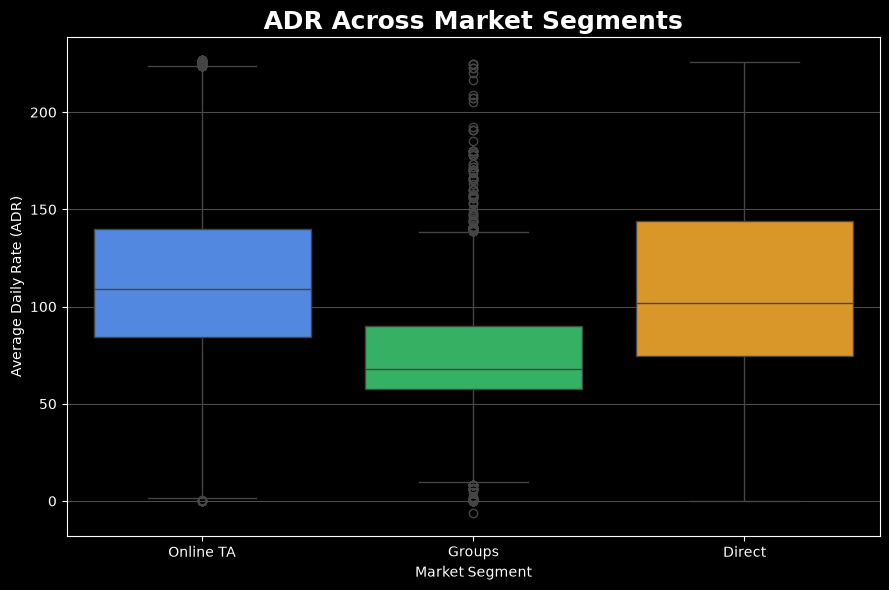

In [224]:
# visualization

plt.style.use("dark_background")

plot_df = pd.DataFrame({

    "ADR": pd.concat(
        [online_ta, groups, direct],
        ignore_index=True
    ),

    "Market Segment": (
        ["Online TA"] * len(online_ta)
        + ["Groups"] * len(groups)
        + ["Direct"] * len(direct)
    )

})

plt.figure(figsize=(9,6))

sns.boxplot(

    data=plot_df,

    x="Market Segment",

    y="ADR",

    hue="Market Segment",

    palette=[
        "#3B82F6",
        "#22C55E",
        "#F59E0B"
    ],

    legend=False

)

plt.title(

    "ADR Across Market Segments",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Market Segment")

plt.ylabel("Average Daily Rate (ADR)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

A One-Way ANOVA was conducted to compare the Average Daily Rate (ADR) across different market segments (Online TA, Groups, and Direct).

**Results:**

- F Statistic = **1857.6878**
- P-value = **0.0000**

Since the p-value is less than the significance level of 0.05, the null hypothesis is rejected.

This indicates that there is a statistically significant difference in the mean ADR among the selected market segments.

### Business Impact

The results suggest that different market segments contribute differently to hotel pricing. Customers booking through Online Travel Agencies (OTA), Direct channels, and Group bookings exhibit distinct pricing patterns.

Hotel management can use these insights to optimize pricing strategies, promotional offers, and channel-specific revenue management policies.

## Pearson Correlation

Pearson Correlation measures the strength and direction of the linear relationship between two continuous numerical variables.

In this analysis, the relationship between **Lead Time** and **Average Daily Rate (ADR)** is examined.

### Null Hypothesis (H₀)

There is no significant linear relationship between Lead Time and ADR.

### Alternative Hypothesis (H₁)

There is a significant linear relationship between Lead Time and ADR.

### Assumption Validation

The Pearson Correlation test requires:

- Continuous numerical variables ✔
- Independent observations ✔
- Approximately linear relationship ✔
- Large sample size ✔

These assumptions are reasonably satisfied for the selected variables.

In [225]:
# perform pearson correlation

from scipy.stats import pearsonr

correlation, p_value = pearsonr(

    hotel_df["lead_time"],

    hotel_df["adr"]

)

print("Correlation Coefficient :", round(correlation,4))

print("P-value :", p_value)

Correlation Coefficient : 0.0383
P-value : 7.313364328440638e-29


In [226]:
# decision

if p_value < 0.05:

    print("Reject Null Hypothesis")

    print("There is a significant linear relationship.")

else:

    print("Fail to Reject Null Hypothesis")

    print("No significant linear relationship.")

Reject Null Hypothesis
There is a significant linear relationship.


In [227]:
# summary table

pearson_df = pd.DataFrame({

    "Test":[
        "Pearson Correlation"
    ],

    "Correlation":[
        round(correlation,4)
    ],

    "P-value":[
        p_value
    ]

})

pearson_df

,Test,Correlation,P-value
0,Pearson Correlation,0.0383,7.313364e-29


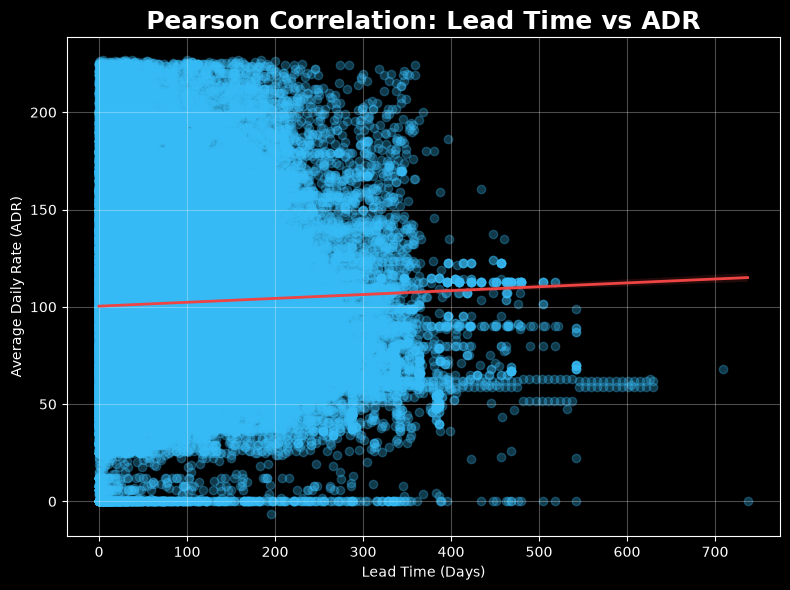

In [228]:
# visualization

plt.style.use("dark_background")

plt.figure(figsize=(8,6))

sns.regplot(

    data=hotel_df,

    x="lead_time",

    y="adr",

    scatter_kws={
        "alpha":0.3,
        "color":"#38BDF8"
    },

    line_kws={
        "color":"#EF4444",
        "linewidth":2
    }

)

plt.title(

    "Pearson Correlation: Lead Time vs ADR",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Lead Time (Days)")

plt.ylabel("Average Daily Rate (ADR)")

plt.grid(alpha=0.3)

plt.tight_layout()

# Save image 
plt.savefig( "static/images/pearson correlation(statistical).png", dpi=300, bbox_inches="tight", facecolor="black" )


plt.show()

### Interpretation

The Pearson Correlation test was performed to examine the linear relationship between **Lead Time** and **Average Daily Rate (ADR)**.

**Results:**

- Correlation Coefficient (r) = **0.0383**
- P-value = **7.313364 × 10⁻²⁹**

Since the p-value is less than 0.05, the null hypothesis is rejected.

Although the relationship is statistically significant, the correlation coefficient is very close to zero, indicating a **very weak positive linear relationship** between Lead Time and ADR.

### Business Impact

The results suggest that booking lead time has only a minimal influence on room pricing. Therefore, hotels should consider additional factors such as hotel type, seasonality, customer type, market segment, and demand patterns when developing pricing strategies.

## Chi-Square Test of Independence

The Chi-Square Test of Independence is used to determine whether there is a significant association between two categorical variables.

In this analysis, the relationship between **Hotel Type** and **Cancellation Status** is examined.

### Null Hypothesis (H₀)

Hotel Type and Cancellation Status are independent.

### Alternative Hypothesis (H₁)

Hotel Type and Cancellation Status are significantly associated.

In [229]:
# create contingency table

# Convert encoded hotel values into readable labels
hotel_labels = hotel_df["hotel"].map({
    0: "City Hotel",
    1: "Resort Hotel"
})

cancel_labels = hotel_df["is_canceled"].map({
    0: "Not Cancelled",
    1: "Cancelled"
})

contingency_table = pd.crosstab(
    hotel_labels,
    cancel_labels
)

contingency_table

is_canceled,Cancelled,Not Cancelled
hotel,,
City Hotel,15754,36737
Resort Hotel,7284,24930


In [230]:
# chi-squaretest

from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-Square Statistic :", round(chi2,4))
print("Degrees of Freedom :", dof)
print("P-value :", p_value)

Chi-Square Statistic : 551.9297
Degrees of Freedom : 1
P-value : 4.788530503122595e-122


In [231]:
# decision

if p_value < 0.05:

    print("Reject Null Hypothesis")
    print("Hotel Type and Cancellation Status are significantly associated.")

else:

    print("Fail to Reject Null Hypothesis")
    print("No significant association exists.")

Reject Null Hypothesis
Hotel Type and Cancellation Status are significantly associated.


In [232]:
# summary table

chi_square_df = pd.DataFrame({

    "Test": ["Chi-Square Test"],

    "Chi-Square Statistic": [round(chi2,4)],

    "Degrees of Freedom": [dof],

    "P-value": [p_value]

})

chi_square_df

,Test,Chi-Square Statistic,Degrees of Freedom,P-value
0,Chi-Square Test,551.9297,1,4.788531e-122


In [233]:
# visualization

chi_square_df = pd.DataFrame({

    "Test": ["Chi-Square Test"],

    "Chi-Square Statistic": [round(chi2,4)],

    "Degrees of Freedom": [dof],

    "P-value": [p_value]

})

chi_square_df

,Test,Chi-Square Statistic,Degrees of Freedom,P-value
0,Chi-Square Test,551.9297,1,4.788531e-122


There is a statistically significant association between Hotel Type and Cancellation Status.

This means the cancellation behavior differs between City Hotels and Resort Hotels.

## Mann–Whitney U Test

The Mann–Whitney U Test compares the distribution of Average Daily Rate (ADR) between City Hotels and Resort Hotels.

### Null Hypothesis (H₀)

There is no significant difference in the distribution of ADR between City Hotels and Resort Hotels.

### Alternative Hypothesis (H₁)

There is a significant difference in the distribution of ADR between City Hotels and Resort Hotels.

### Assumption Validation

- Independent observations ✔
- Two independent groups ✔
- Numerical dependent variable (ADR) ✔
- Non-normal distribution (Shapiro–Wilk Test) ✔

Because the normality assumption was not satisfied, the Mann–Whitney U Test is an appropriate non-parametric alternative to the Independent t-Test.

In [234]:
# perform the test

from scipy.stats import mannwhitneyu

city = hotel_df.loc[
    hotel_df["hotel"] == 0,
    "adr"
]

resort = hotel_df.loc[
    hotel_df["hotel"] == 1,
    "adr"
]

u_statistic, p_value = mannwhitneyu(
    city,
    resort,
    alternative="two-sided"
)

print("U Statistic :", u_statistic)
print("P-value :", p_value)

U Statistic : 1108985066.0
P-value : 0.0


In [235]:
# decision

if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("There is a significant difference in ADR between hotel types.")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant difference in ADR between hotel types.")

Reject Null Hypothesis
There is a significant difference in ADR between hotel types.


In [236]:
# summary table

mann_df = pd.DataFrame({

    "Test": ["Mann–Whitney U Test"],

    "U Statistic": [u_statistic],

    "P-value": [p_value]

})

mann_df

,Test,U Statistic,P-value
0,Mann–Whitney U Test,1.108985e+09,0.0


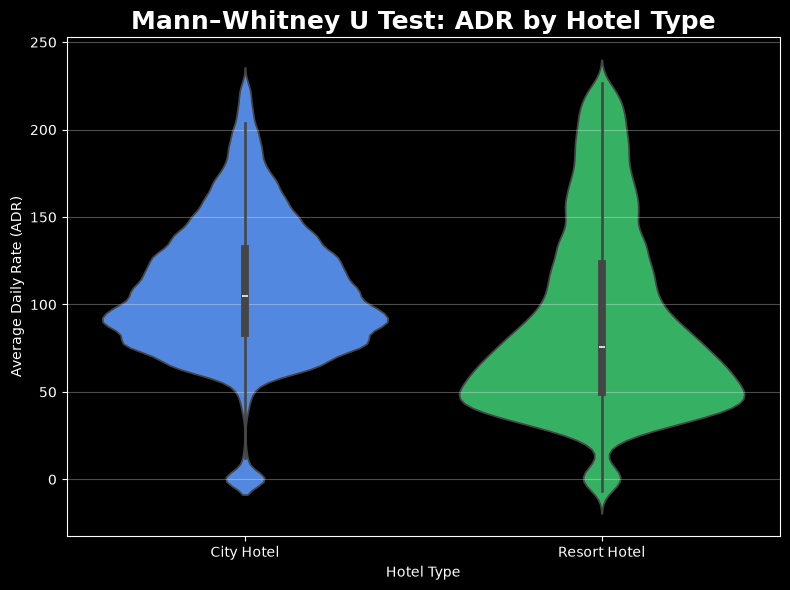

In [237]:
# visualization

plt.style.use("dark_background")

plt.figure(figsize=(8,6))

sns.violinplot(
    data=hotel_df,
    x="hotel",
    y="adr",
    hue="hotel",
    palette=["#3B82F6", "#22C55E"],
    legend=False
)

plt.xticks(
    [0,1],
    ["City Hotel", "Resort Hotel"]
)

plt.title(
    "Mann–Whitney U Test: ADR by Hotel Type",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Hotel Type")
plt.ylabel("Average Daily Rate (ADR)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Save image 
plt.savefig( "static/images/mann_whiteney_u_test(statistical).png", dpi=300, bbox_inches="tight", facecolor="black" )


plt.show()


**Results:**

- U Statistic = **1.108985 × 10⁹**
- P-value = **0.0000**

Since the p-value is less than the significance level of 0.05, the null hypothesis is rejected.

This indicates a statistically significant difference in the distribution of ADR between City Hotels and Resort Hotels.

### Business Impact

The results confirm that room pricing differs significantly between the two hotel types. Since the Mann–Whitney U Test does not assume normality, it provides robust evidence that hotel type influences room pricing, supporting pricing and revenue management decisions.

## Kruskal–Wallis Test

The Kruskal–Wallis Test compares the distribution of Average Daily Rate (ADR) across multiple market segments.

### Null Hypothesis (H₀)

The distribution of ADR is the same across all selected market segments.

### Alternative Hypothesis (H₁)

At least one market segment has a significantly different ADR distribution.

The Kruskal–Wallis Test requires:

- Independent observations ✔
- Numerical dependent variable ✔
- Three or more independent groups ✔
- No assumption of normality ✔

Since the normality assumption was not satisfied, the Kruskal–Wallis Test is an appropriate non-parametric alternative to One-Way ANOVA.

In [238]:
# perform the test

from scipy.stats import kruskal

online_ta = hotel_df.loc[
    hotel_df["market_segment_Online TA"] == 1,
    "adr"
]

groups = hotel_df.loc[
    hotel_df["market_segment_Groups"] == 1,
    "adr"
]

direct = hotel_df.loc[
    hotel_df["market_segment_Direct"] == 1,
    "adr"
]

h_statistic, p_value = kruskal(
    online_ta,
    groups,
    direct
)

print("H Statistic :", round(h_statistic,4))
print("P-value :", p_value)

H Statistic : 3938.9729
P-value : 0.0


In [239]:
# decision
if p_value < 0.05:

    print("Reject Null Hypothesis")

    print("At least one market segment differs significantly.")

else:

    print("Fail to Reject Null Hypothesis")

    print("No significant difference among market segments.")

Reject Null Hypothesis
At least one market segment differs significantly.


In [240]:
# summary table
kruskal_df = pd.DataFrame({

    "Test": ["Kruskal–Wallis Test"],

    "H Statistic": [round(h_statistic,4)],

    "P-value": [p_value]

})

kruskal_df

,Test,H Statistic,P-value
0,Kruskal–Wallis Test,3938.9729,0.0


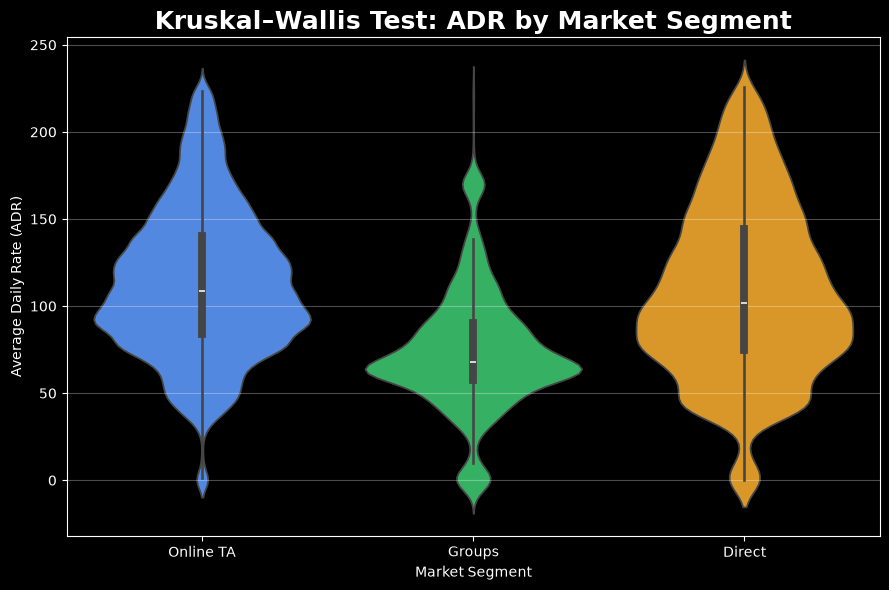

In [241]:
# visualization

plt.style.use("dark_background")

plt.figure(figsize=(9,6))

sns.violinplot(

    data=plot_df,

    x="Market Segment",

    y="ADR",

    hue="Market Segment",

    palette=[
        "#3B82F6",
        "#22C55E",
        "#F59E0B"
    ],

    legend=False

)

plt.title(

    "Kruskal–Wallis Test: ADR by Market Segment",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Market Segment")

plt.ylabel("Average Daily Rate (ADR)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

**Results:**

- H Statistic = **3938.9729**
- P-value = **0.0000**

Since the p-value is less than 0.05, the null hypothesis is rejected.

This indicates that at least one market segment has a significantly different distribution of ADR.

### Business Impact

The results demonstrate that room pricing varies significantly across booking channels. Hotels can use these findings to optimize pricing strategies, promotional campaigns, and revenue management for different market segments.

## Spearman Correlation

The Spearman Correlation measures the strength and direction of the monotonic relationship between **Lead Time** and **Average Daily Rate (ADR)**.

### Null Hypothesis (H₀)

There is no significant monotonic relationship between Lead Time and ADR.

### Alternative Hypothesis (H₁)

There is a significant monotonic relationship between Lead Time and ADR.

The Spearman Correlation requires:

- Numerical or ordinal variables ✔
- Independent observations ✔
- No assumption of normality ✔

Since the Shapiro–Wilk Test indicated that the data are not normally distributed, the Spearman Correlation is an appropriate non-parametric alternative to the Pearson Correlation.

In [242]:
# spearma correalation

from scipy.stats import spearmanr

rho, p_value = spearmanr(
    hotel_df["lead_time"],
    hotel_df["adr"]
)

print("Spearman Correlation :", round(rho,4))
print("P-value :", p_value)


Spearman Correlation : 0.1109
P-value : 4.83347532348581e-230


In [243]:
# decision

if p_value < 0.05:

    print("Reject Null Hypothesis")

    print("There is a significant monotonic relationship.")

else:

    print("Fail to Reject Null Hypothesis")

    print("No significant monotonic relationship.")

Reject Null Hypothesis
There is a significant monotonic relationship.


In [244]:
# summary table

spearman_df = pd.DataFrame({

    "Test": ["Spearman Correlation"],

    "Correlation": [round(rho,4)],

    "P-value": [p_value]

})

spearman_df

,Test,Correlation,P-value
0,Spearman Correlation,0.1109,4.833475e-230


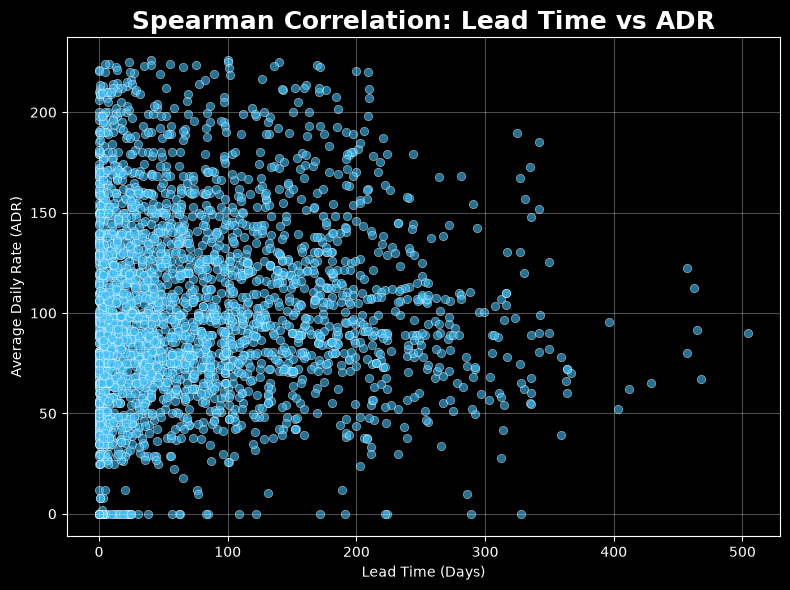

In [245]:
# visualization

plt.style.use("dark_background")

plt.figure(figsize=(8,6))

sns.scatterplot(

    data=hotel_df.sample(3000, random_state=42),

    x="lead_time",

    y="adr",

    color="#38BDF8",

    alpha=0.6

)

plt.title(

    "Spearman Correlation: Lead Time vs ADR",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Lead Time (Days)")
plt.ylabel("Average Daily Rate (ADR)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# Phase 6 – Exploratory Data Analysis (EDA)

## 1. Monthly Booking Trends

In [246]:
# calculate montghly bookings

month_order = [

    "January","February","March","April",

    "May","June","July","August",

    "September","October","November","December"

]

monthly_booking = (

    hotel_df["arrival_date_month"]

    .value_counts()

    .reindex(month_order)

)

monthly_booking

arrival_date_month
January      4680
February     6065
March        7461
April        7823
May          8225
June         7604
July         9469
August       9848
September    6609
October      6891
November     4967
December     5063
Name: count, dtype: int64

In [247]:
hotel_df.shape

(84705, 59)

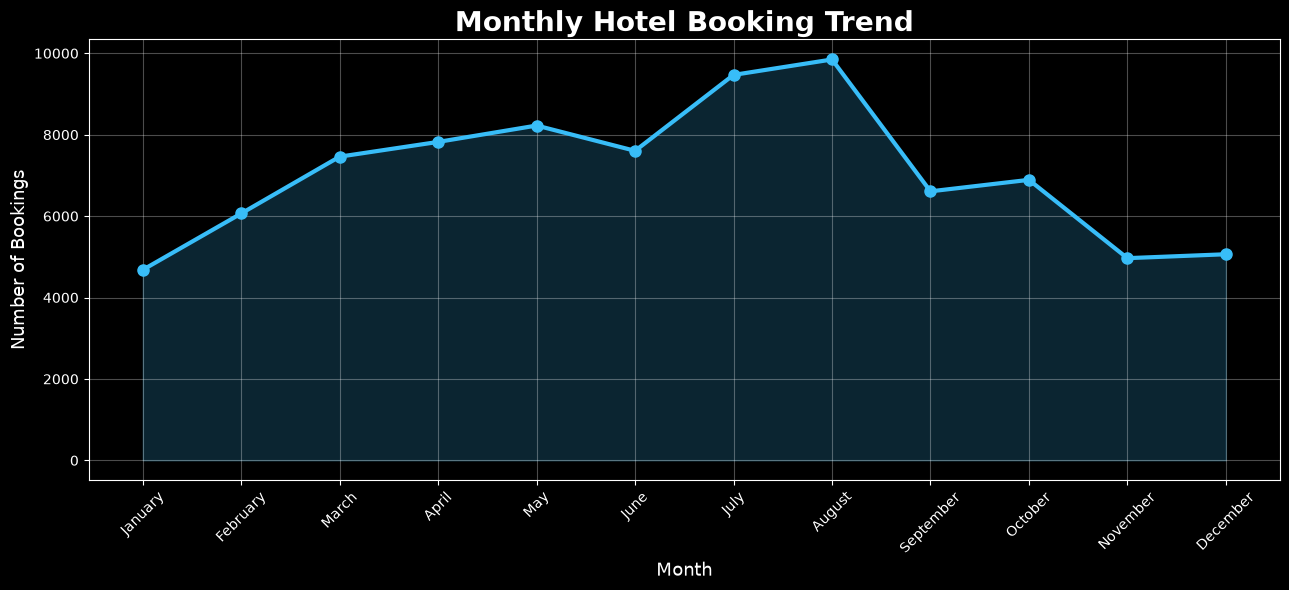

In [248]:
# line chart

plt.style.use("dark_background")

plt.figure(figsize=(13,6))

plt.plot(

    monthly_booking.index,

    monthly_booking.values,

    marker="o",

    markersize=8,

    linewidth=3,

    color="#38BDF8"

)

plt.fill_between(

    monthly_booking.index,

    monthly_booking.values,

    color="#38BDF8",

    alpha=0.20

)

plt.title(

    "Monthly Hotel Booking Trend",

    fontsize=20,

    fontweight="bold"

)

plt.xlabel(

    "Month",

    fontsize=13

)

plt.ylabel(

    "Number of Bookings",

    fontsize=13

)

plt.xticks(rotation=45)

plt.grid(alpha=0.3)

plt.tight_layout()

# Save image
plt.savefig(
    "static/images/monthly_booking_trend(booking).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

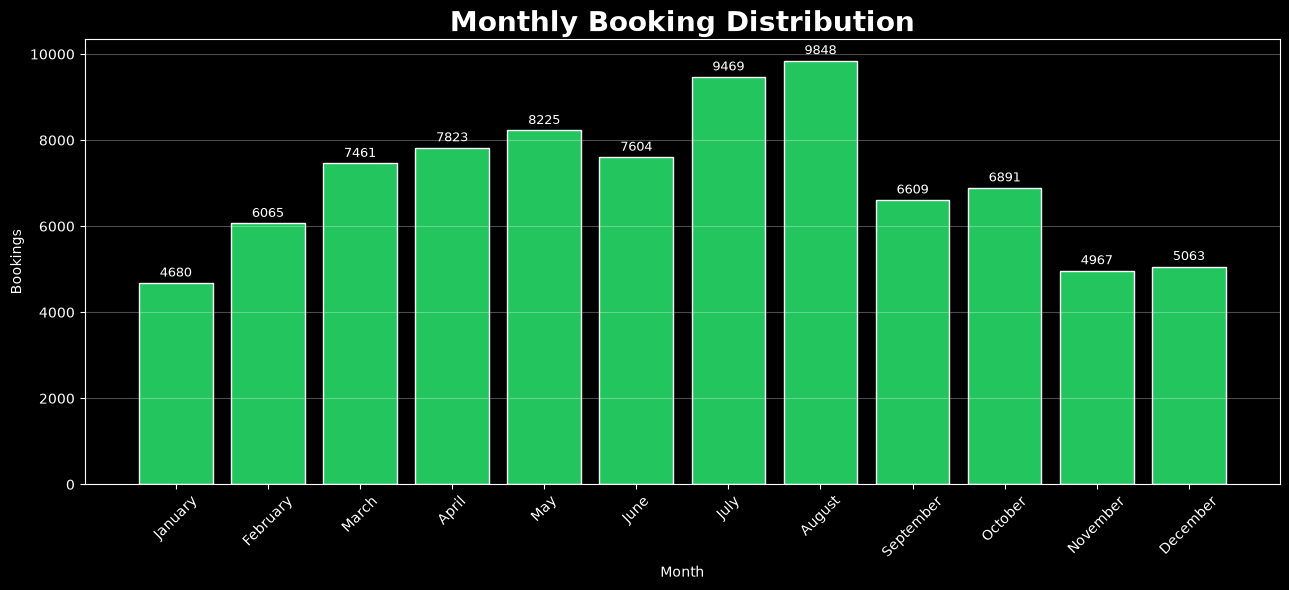

In [249]:
# barchart

plt.style.use("dark_background")

plt.figure(figsize=(13,6))

bars = plt.bar(

    monthly_booking.index,

    monthly_booking.values,

    color="#22C55E",

    edgecolor="white"

)

plt.title(

    "Monthly Booking Distribution",

    fontsize=20,

    fontweight="bold"

)

plt.xlabel("Month")

plt.ylabel("Bookings")

plt.xticks(rotation=45)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+150,

        int(bar.get_height()),

        ha="center",

        fontsize=9,

        color="white"

    )

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()



plt.show()

In [250]:
# summary table
monthly_df = monthly_booking.reset_index()

monthly_df.columns = [

    "Month",

    "Bookings"

]

monthly_df

,Month,Bookings
0,January,4680
1,February,6065
2,March,7461
3,April,7823
4,May,8225
5,June,7604
6,July,9469
7,August,9848
8,September,6609
9,October,6891


## 2. Hotel Type Comparison

In [251]:
# calculate booking counts

hotel_counts = (

    hotel_df["hotel"]

    .map({

        0:"City Hotel",

        1:"Resort Hotel"

    })

    .value_counts()

)

hotel_counts

hotel
City Hotel      52491
Resort Hotel    32214
Name: count, dtype: int64

In [252]:
# percentage distribution

hotel_percentage = round(

    hotel_counts /

    hotel_counts.sum()

    *100,

    2

)

hotel_percentage

hotel
City Hotel      61.97
Resort Hotel    38.03
Name: count, dtype: float64

In [253]:
# table

hotel_summary = pd.DataFrame({

    "Hotel Type":hotel_counts.index,

    "Bookings":hotel_counts.values,

    "Percentage":hotel_percentage.values

})

hotel_summary

,Hotel Type,Bookings,Percentage
0,City Hotel,52491,61.97
1,Resort Hotel,32214,38.03


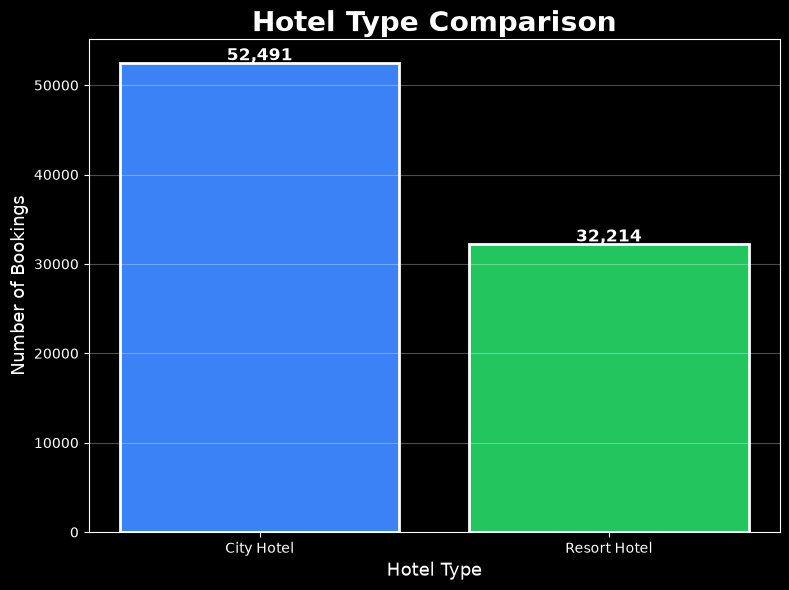

In [254]:
# bar chart

plt.style.use("dark_background")

plt.figure(figsize=(8,6))

bars = plt.bar(

    hotel_counts.index,

    hotel_counts.values,

    color=[

        "#3B82F6",

        "#22C55E"

    ],

    edgecolor="white",

    linewidth=2

)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+300,

        f"{int(bar.get_height()):,}",

        ha="center",

        fontsize=12,

        color="white",

        fontweight="bold"

    )

plt.title(

    "Hotel Type Comparison",

    fontsize=20,

    fontweight="bold"

)

plt.xlabel(

    "Hotel Type",

    fontsize=13

)

plt.ylabel(

    "Number of Bookings",

    fontsize=13

)

plt.grid(

    axis="y",

    alpha=0.3

)

plt.tight_layout()

# Save image
plt.savefig(
    "static/images/hote_type_comparison(booking).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

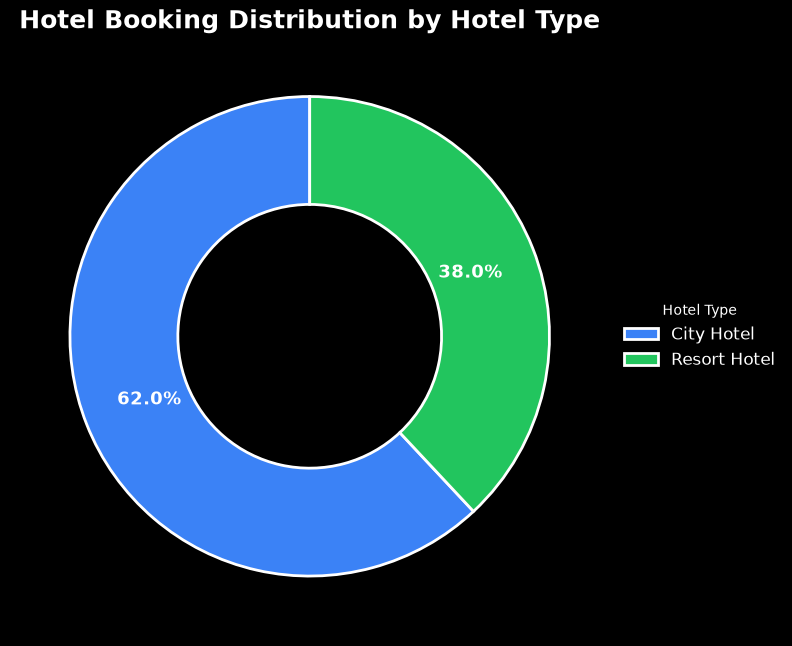

In [255]:
# donut chart

plt.style.use("dark_background")

plt.figure(figsize=(8,8))

colors = [
    "#3B82F6",
    "#22C55E"
]

wedges, texts, autotexts = plt.pie(
    hotel_counts,
    labels=None,
    colors=colors,
    startangle=90,

    autopct="%1.1f%%",
    pctdistance=0.72,

    wedgeprops={
        "width":0.45,
        "edgecolor":"white",
        "linewidth":2
    },

    textprops={
        "color":"white",
        "fontsize":13,
        "fontweight":"bold"
    }
)

plt.legend(
    wedges,
    hotel_counts.index,
    title="Hotel Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=12
)

plt.title(
    "Hotel Booking Distribution by Hotel Type",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## 3. Booking Lead Time Analysis


In [256]:
# summary statistics
lead_summary = hotel_df["lead_time"].describe().round(2)
lead_summary

count    84705.00
mean        80.24
std         86.47
min          0.00
25%         11.00
50%         49.00
75%        126.00
max        737.00
Name: lead_time, dtype: float64

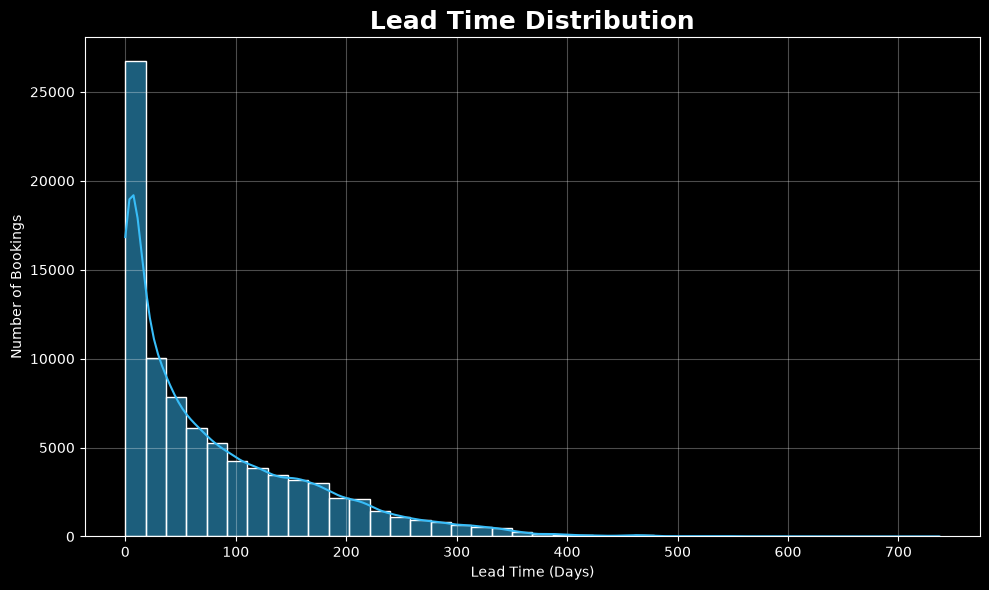

In [257]:
# histogram with KDE
plt.style.use("dark_background")

plt.figure(figsize=(10,6))

sns.histplot(
    hotel_df["lead_time"],
    bins=40,
    kde=True,
    color="#38BDF8",
    edgecolor="white"
)

plt.title(
    "Lead Time Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Bookings")

plt.grid(alpha=0.3)

plt.tight_layout()

# Save image
plt.savefig(
    "static/images/booking_lead_time(booking).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

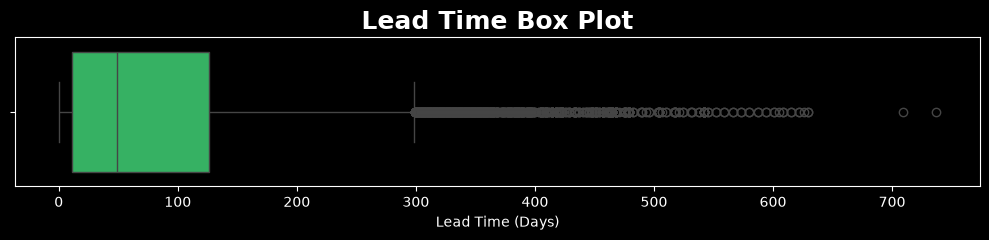

In [258]:
# boxplot
plt.style.use("dark_background")

plt.figure(figsize=(10,2.5))

sns.boxplot(
    x=hotel_df["lead_time"],
    color="#22C55E"
)

plt.title(
    "Lead Time Box Plot",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Lead Time (Days)")

plt.tight_layout()

plt.show()

In [259]:
# lead time categories
lead_category = (

    hotel_df["lead_time_category"]

    .value_counts()

)

lead_category

lead_time_category
Short        33557
Medium       21947
Long         17644
Very Long    11557
Name: count, dtype: int64

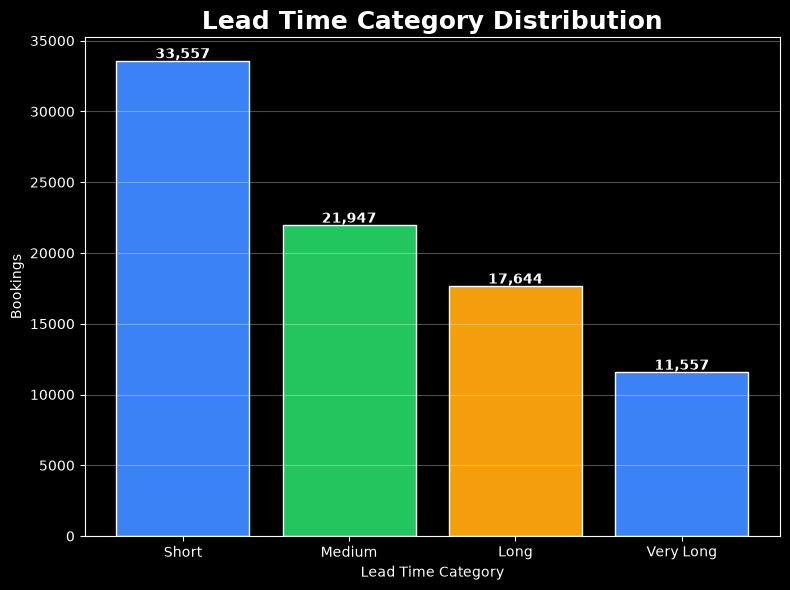

In [260]:
# lead time category chart

plt.style.use("dark_background")

plt.figure(figsize=(8,6))

bars = plt.bar(

    lead_category.index,

    lead_category.values,

    color=[
        "#3B82F6",
        "#22C55E",
        "#F59E0B"
    ],

    edgecolor="white"

)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+200,

        f"{int(bar.get_height()):,}",

        ha="center",

        color="white",

        fontweight="bold"

    )

plt.title(

    "Lead Time Category Distribution",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Lead Time Category")

plt.ylabel("Bookings")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

## 4. Seasonal Booking Trends


In [261]:
# seasonal booking counts

season_counts = (

    hotel_df["booking_season"]

    .value_counts()

)

season_counts

booking_season
Summer    26921
Spring    23509
Autumn    18467
Winter    15808
Name: count, dtype: int64

In [262]:
# table
season_df = pd.DataFrame({

    "Season":season_counts.index,

    "Bookings":season_counts.values,

    "Percentage":round(

        season_counts/season_counts.sum()*100,

        2

    ).values

})

season_df

,Season,Bookings,Percentage
0,Summer,26921,31.78
1,Spring,23509,27.75
2,Autumn,18467,21.80
3,Winter,15808,18.66


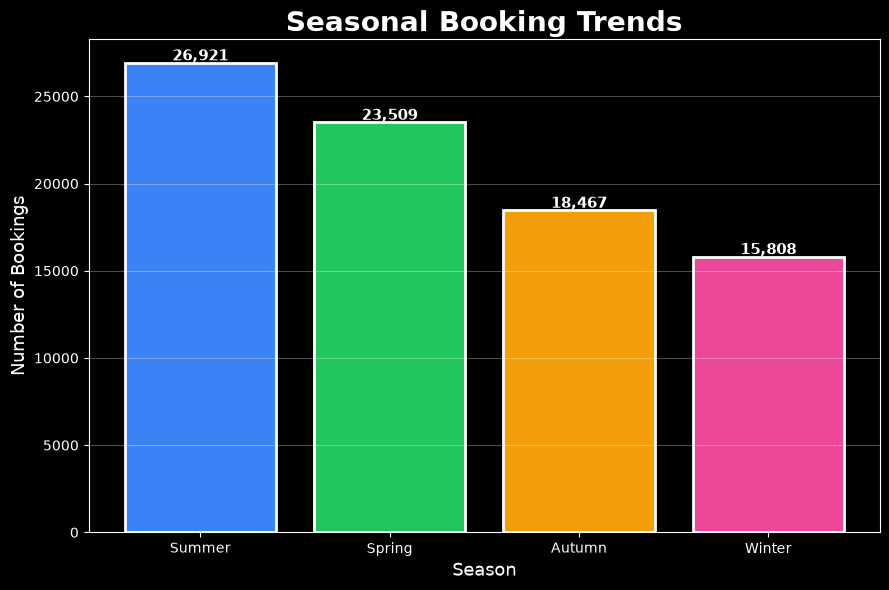

In [263]:
# bar chart

plt.style.use("dark_background")

plt.figure(figsize=(9,6))

bars = plt.bar(

    season_counts.index,

    season_counts.values,

    color=[
        "#3B82F6",
        "#22C55E",
        "#F59E0B",
        "#EC4899"
    ],

    edgecolor="white",
    linewidth=2

)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+150,

        f"{int(bar.get_height()):,}",

        ha="center",

        fontsize=11,

        color="white",

        fontweight="bold"

    )

plt.title(

    "Seasonal Booking Trends",

    fontsize=20,

    fontweight="bold"

)

plt.xlabel("Season", fontsize=13)

plt.ylabel("Number of Bookings", fontsize=13)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Save image
plt.savefig(
    "static/images/seasonal_booking_trend(booking).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

## 5. Booking by Week Number


In [264]:
# weekly booking counts

weekly_booking = (

    hotel_df["arrival_date_week_number"]

    .value_counts()

    .sort_index()

)

weekly_booking.head()

arrival_date_week_number
1     859
2     943
3    1047
4    1122
5    1097
Name: count, dtype: int64

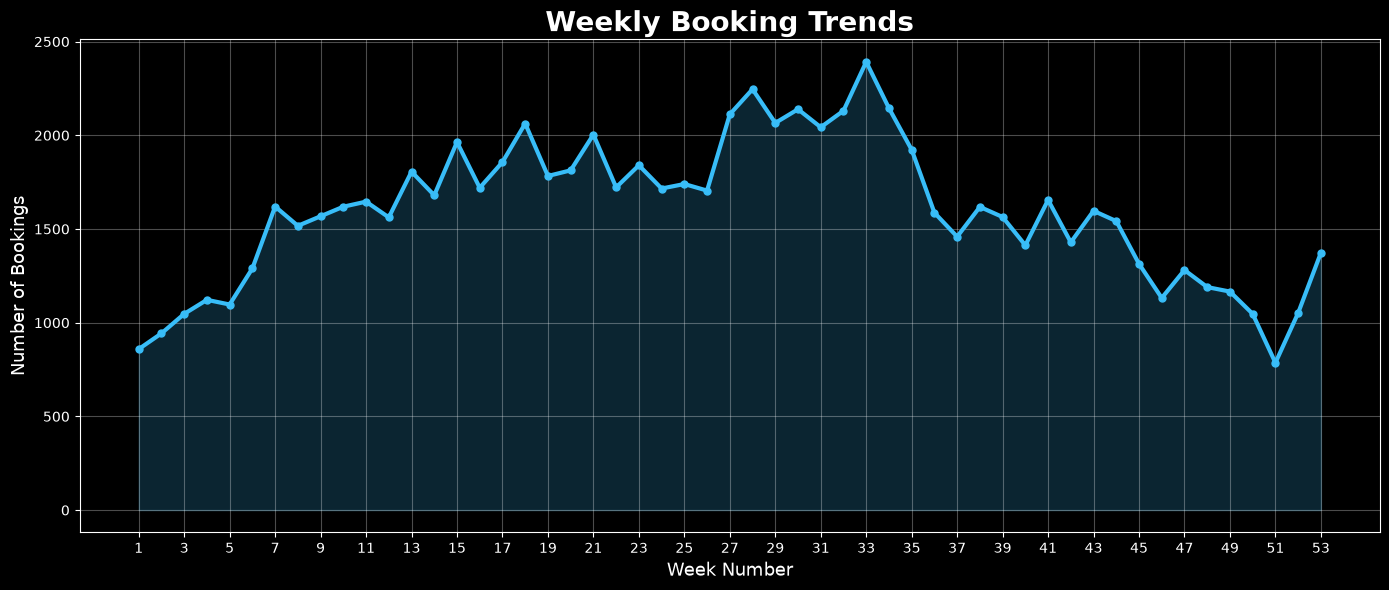

In [265]:
# linechart
plt.style.use("dark_background")

plt.figure(figsize=(14,6))

plt.plot(

    weekly_booking.index,

    weekly_booking.values,

    color="#38BDF8",

    linewidth=3,

    marker="o",

    markersize=5

)

plt.fill_between(

    weekly_booking.index,

    weekly_booking.values,

    color="#38BDF8",

    alpha=0.20

)

plt.title(

    "Weekly Booking Trends",

    fontsize=20,

    fontweight="bold"

)

plt.xlabel("Week Number", fontsize=13)

plt.ylabel("Number of Bookings", fontsize=13)

plt.xticks(range(1,54,2))

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

##  6. Booking Value Segment Analysis

In [266]:
# calculate booking value segments
booking_value = (

    hotel_df["booking_value_segment"]

    .value_counts()

)

booking_value


booking_value_segment
Low Value        21446
High Value       21171
Premium Value    21145
Medium Value     20943
Name: count, dtype: int64

In [267]:
# summary table
booking_value_df = pd.DataFrame({

    "Booking Value Segment": booking_value.index,

    "Bookings": booking_value.values

})

booking_value_df["Percentage"] = (
    booking_value_df["Bookings"] /
    booking_value_df["Bookings"].sum() * 100
).round(2)

booking_value_df

,Booking Value Segment,Bookings,Percentage
0,Low Value,21446,25.32
1,High Value,21171,24.99
2,Premium Value,21145,24.96
3,Medium Value,20943,24.72


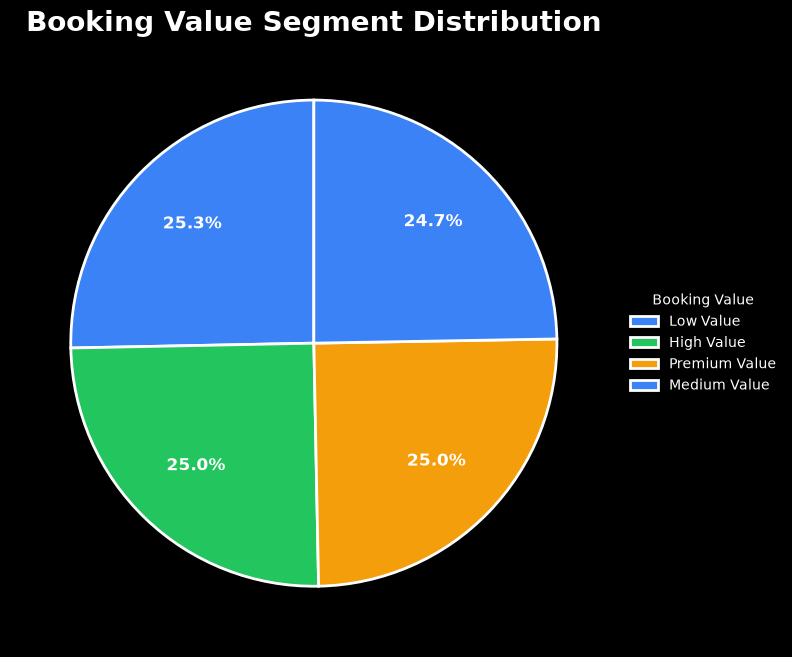

In [268]:
# pie chart

plt.style.use("dark_background")

plt.figure(figsize=(8,8))

colors = [

    "#3B82F6",

    "#22C55E",

    "#F59E0B"

]

wedges, texts, autotexts = plt.pie(

    booking_value,

    labels=None,

    colors=colors,

    autopct="%1.1f%%",

    startangle=90,

    pctdistance=0.70,

    wedgeprops={

        "edgecolor":"white",

        "linewidth":2

    },

    textprops={

        "color":"white",

        "fontsize":12,

        "fontweight":"bold"

    }

)

plt.legend(

    wedges,

    booking_value.index,

    title="Booking Value",

    loc="center left",

    bbox_to_anchor=(1,0.5),

    frameon=False

)

plt.title(

    "Booking Value Segment Distribution",

    fontsize=20,

    fontweight="bold"

)

plt.tight_layout()

plt.show()

## CUSTOMER ANALYSIS

## 1.Customer type distribution

In [269]:
# customer type counts

customer_counts = (

    hotel_df["customer_type"]

    .value_counts()

)

customer_counts

customer_type
2    69498
3    11543
0     3133
1      531
Name: count, dtype: int64

In [270]:
# summary table

customer_df = pd.DataFrame({

    "Customer Type": customer_counts.index,

    "Bookings": customer_counts.values

})

customer_df["Percentage"] = (

    customer_df["Bookings"]

    / customer_df["Bookings"].sum()

    *100

).round(2)

customer_df

,Customer Type,Bookings,Percentage
0,2,69498,82.05
1,3,11543,13.63
2,0,3133,3.70
3,1,531,0.63


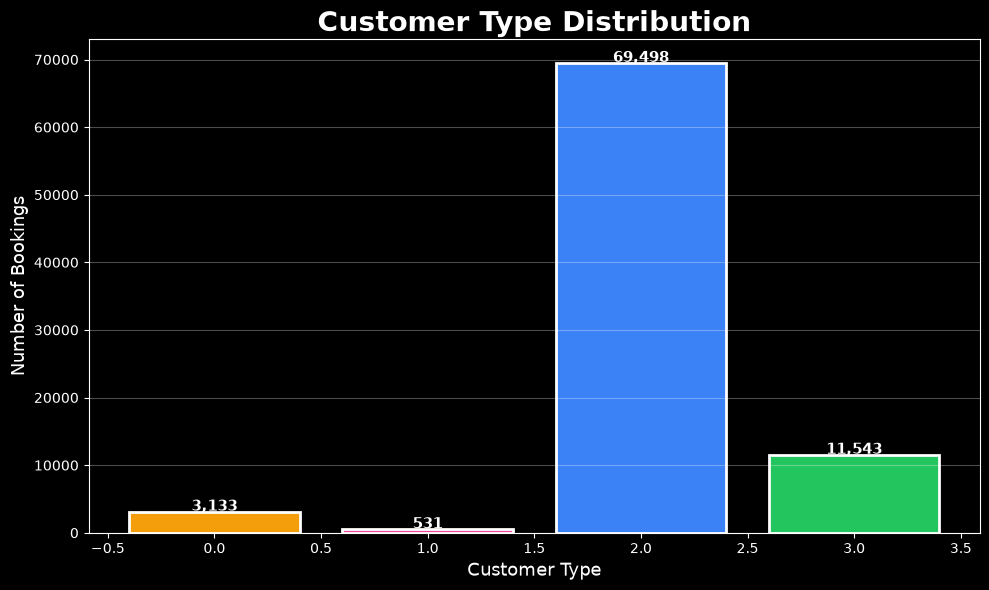

In [271]:
# bar chart

plt.style.use("dark_background")

plt.figure(figsize=(10,6))

bars = plt.bar(

    customer_counts.index,

    customer_counts.values,

    color=[

        "#3B82F6",

        "#22C55E",

        "#F59E0B",

        "#EC4899"

    ],

    edgecolor="white",

    linewidth=2

)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+150,

        f"{int(bar.get_height()):,}",

        ha="center",

        color="white",

        fontsize=11,

        fontweight="bold"

    )

plt.title(

    "Customer Type Distribution",

    fontsize=20,

    fontweight="bold"

)

plt.xlabel("Customer Type", fontsize=13)

plt.ylabel("Number of Bookings", fontsize=13)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Save image
plt.savefig(
    "static/images/customer_type_distribution(customer).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

## 2. Country Wise Bookings

In [272]:
# top 10 countries
top_countries = (

    hotel_df["country"]

    .value_counts()

    .head(10)

)

top_countries


country
PRT    26907
GBR    10244
FRA     8625
ESP     6779
DEU     5332
ITA     2989
IRL     2980
BEL     2048
BRA     1953
NLD     1879
Name: count, dtype: int64

In [273]:
# summary table

country_df = pd.DataFrame({

    "Country": top_countries.index,

    "Bookings": top_countries.values

})

country_df["Percentage"] = (

    country_df["Bookings"]

    / country_df["Bookings"].sum()

    *100

).round(2)

country_df

,Country,Bookings,Percentage
0,PRT,26907,38.58
1,GBR,10244,14.69
2,FRA,8625,12.37
3,ESP,6779,9.72
4,DEU,5332,7.65
5,ITA,2989,4.29
6,IRL,2980,4.27
7,BEL,2048,2.94
8,BRA,1953,2.80
9,NLD,1879,2.69


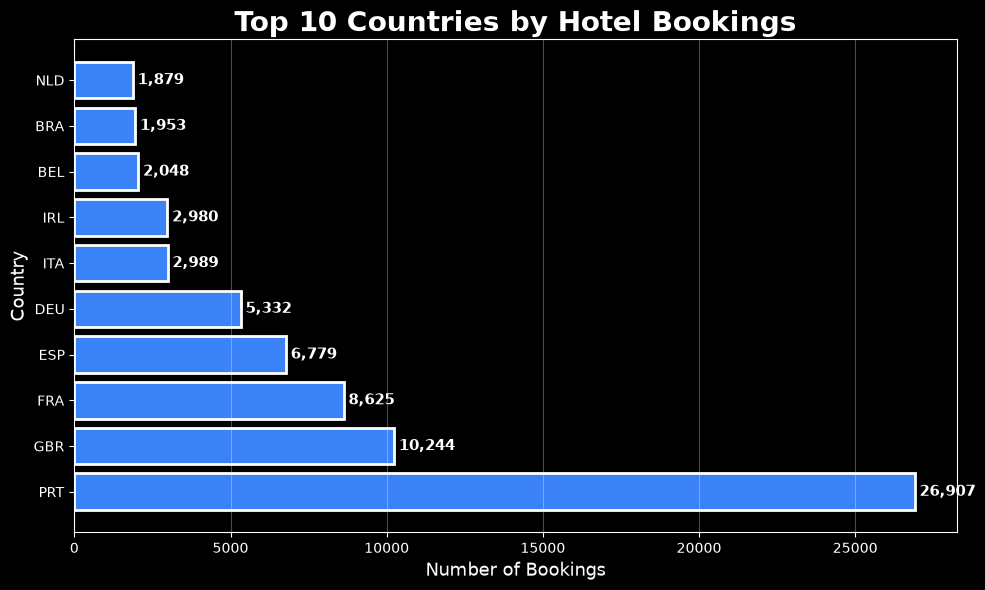

In [274]:
# horizontal bar chart

plt.style.use("dark_background")

plt.figure(figsize=(10,6))

bars = plt.barh(

    top_countries.index,

    top_countries.values,

    color="#3B82F6",

    edgecolor="white",

    linewidth=2

)

for bar in bars:

    plt.text(

        bar.get_width()+150,

        bar.get_y()+bar.get_height()/2,

        f"{int(bar.get_width()):,}",

        va="center",

        color="white",

        fontsize=11,

        fontweight="bold"

    )

plt.title(

    "Top 10 Countries by Hotel Bookings",

    fontsize=20,

    fontweight="bold"

)

plt.xlabel("Number of Bookings", fontsize=13)

plt.ylabel("Country", fontsize=13)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

# Save image
plt.savefig(
    "static/images/top10_countries_byhotel_book(customers).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

# Save image
plt.savefig(
    "static/images/country_wise_booking(customer).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

## 3. Repeat Guest Analysis

In [275]:
# calculate repeat guest

repeat_guest = (

    hotel_df["is_repeated_guest"]

    .map({

        0: "New Guest",

        1: "Repeat Guest"

    })

    .value_counts()

)

repeat_guest

is_repeated_guest
New Guest       81379
Repeat Guest     3326
Name: count, dtype: int64

In [276]:
# summary table

repeat_df = pd.DataFrame({

    "Guest Type": repeat_guest.index,

    "Bookings": repeat_guest.values

})

repeat_df["Percentage"] = (

    repeat_df["Bookings"]

    / repeat_df["Bookings"].sum()

    *100

).round(2)

repeat_df

,Guest Type,Bookings,Percentage
0,New Guest,81379,96.07
1,Repeat Guest,3326,3.93


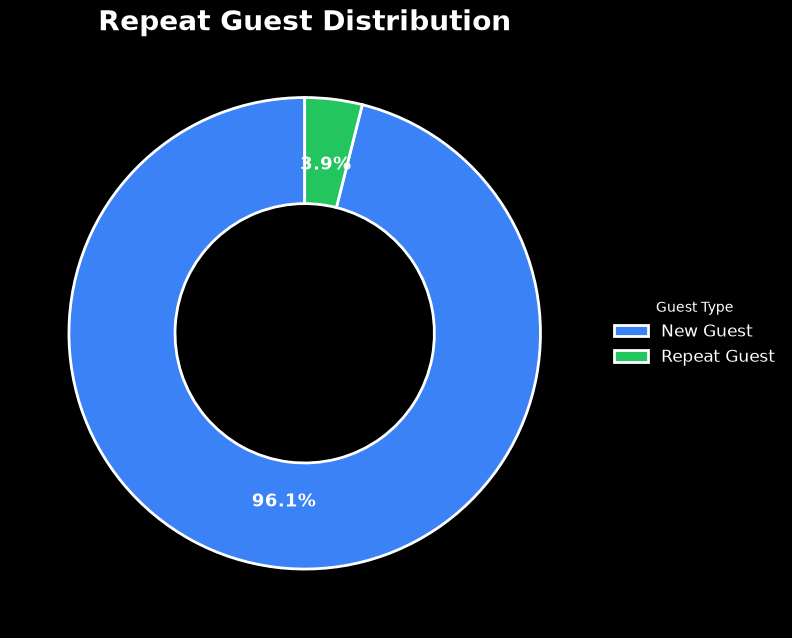

In [277]:
# donut chart

plt.style.use("dark_background")

plt.figure(figsize=(8,8))

colors = [

    "#3B82F6",

    "#22C55E"

]

wedges, texts, autotexts = plt.pie(

    repeat_guest,

    labels=None,

    colors=colors,

    startangle=90,

    autopct="%1.1f%%",

    pctdistance=0.72,

    wedgeprops={

        "width":0.45,

        "edgecolor":"white",

        "linewidth":2

    },

    textprops={

        "color":"white",

        "fontsize":13,

        "fontweight":"bold"

    }

)

plt.legend(

    wedges,

    repeat_guest.index,

    title="Guest Type",

    loc="center left",

    bbox_to_anchor=(1,0.5),

    frameon=False,

    fontsize=12

)

plt.title(

    "Repeat Guest Distribution",

    fontsize=20,

    fontweight="bold"

)

# Save image
plt.savefig(
    "static/images/repeat_guest_analysis(customer).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.tight_layout()

plt.show()

## 4. Market Segment Analysis

In [278]:
# market segment counts
market_segments = {

    "Complementary": hotel_df["market_segment_Complementary"].sum(),

    "Corporate": hotel_df["market_segment_Corporate"].sum(),

    "Direct": hotel_df["market_segment_Direct"].sum(),

    "Groups": hotel_df["market_segment_Groups"].sum(),

    "Offline TA/TO": hotel_df["market_segment_Offline TA/TO"].sum(),

    "Online TA": hotel_df["market_segment_Online TA"].sum(),

    "Undefined": hotel_df["market_segment_Undefined"].sum()

}

market_segment_df = pd.DataFrame(

    market_segments.items(),

    columns=["Market Segment","Bookings"]

)

market_segment_df = market_segment_df.sort_values(

    by="Bookings",

    ascending=False

)

market_segment_df

,Market Segment,Bookings
5,Online TA,49768
4,Offline TA/TO,13801
2,Direct,11131
3,Groups,4895
1,Corporate,4190
0,Complementary,692
6,Undefined,2


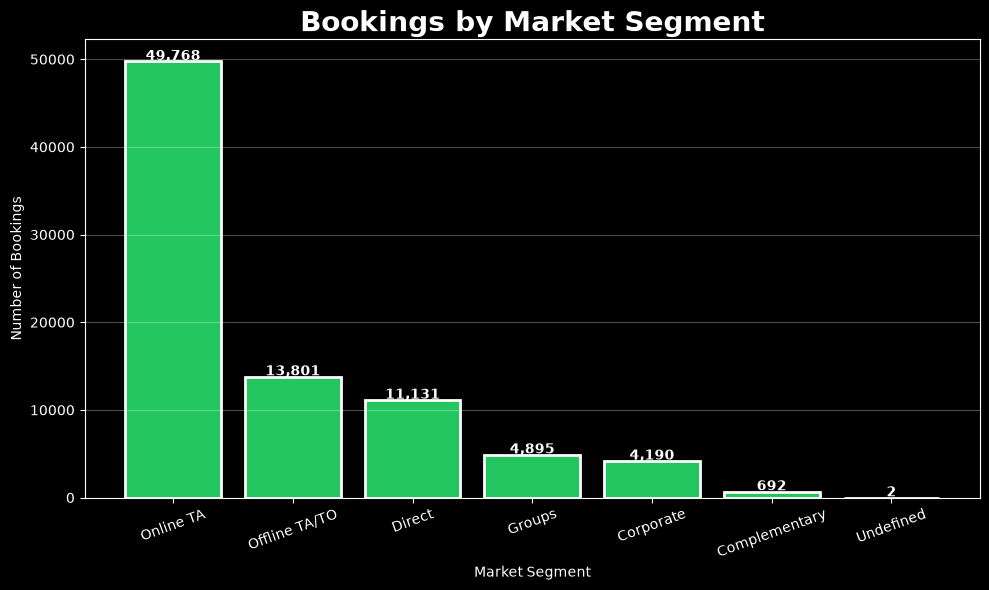

In [279]:
# bar chart

plt.style.use("dark_background")

plt.figure(figsize=(10,6))

bars = plt.bar(

    market_segment_df["Market Segment"],

    market_segment_df["Bookings"],

    color="#22C55E",

    edgecolor="white",

    linewidth=2

)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+150,

        f"{int(bar.get_height()):,}",

        ha="center",

        color="white",

        fontsize=10,

        fontweight="bold"

    )

plt.title(

    "Bookings by Market Segment",

    fontsize=20,

    fontweight="bold"

)

plt.xlabel("Market Segment")

plt.ylabel("Number of Bookings")

plt.xticks(rotation=20)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Save image
plt.savefig(
    "static/images/market_segment_analysis(customer).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

## 5. Customer group distribution

In [280]:
# customer group counts
customer_group = (

    hotel_df["customer_group"]

    .value_counts()

)

customer_group

customer_group
New Guest          81379
Returning Guest     3326
Name: count, dtype: int64

In [281]:
# summary table

customer_group_df = pd.DataFrame({

    "Customer Group": customer_group.index,

    "Bookings": customer_group.values

})

customer_group_df["Percentage"] = (

    customer_group_df["Bookings"]

    / customer_group_df["Bookings"].sum()

    *100

).round(2)

customer_group_df

,Customer Group,Bookings,Percentage
0,New Guest,81379,96.07
1,Returning Guest,3326,3.93


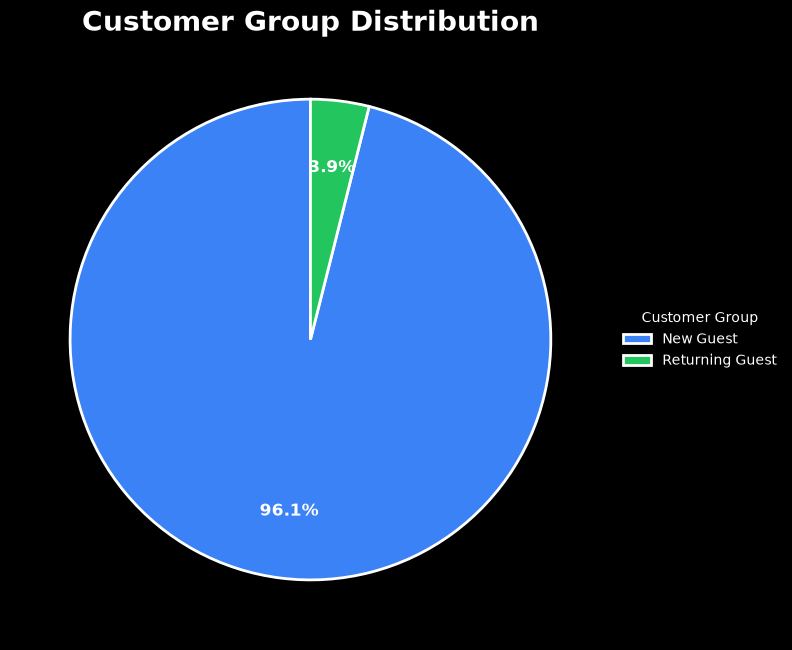

In [282]:
# pie chart
plt.style.use("dark_background")

plt.figure(figsize=(8,8))

colors = [

    "#3B82F6",

    "#22C55E",

    "#F59E0B",

    "#EC4899"

]

wedges, texts, autotexts = plt.pie(

    customer_group,

    labels=None,

    colors=colors,

    autopct="%1.1f%%",

    pctdistance=0.72,

    startangle=90,

    wedgeprops={

        "edgecolor":"white",

        "linewidth":2

    },

    textprops={

        "color":"white",

        "fontsize":12,

        "fontweight":"bold"

    }

)

plt.legend(

    wedges,

    customer_group.index,

    title="Customer Group",

    loc="center left",

    bbox_to_anchor=(1,0.5),

    frameon=False

)

plt.title(

    "Customer Group Distribution",

    fontsize=20,

    fontweight="bold"

)

plt.tight_layout()

plt.show()

## 6. Booking size analysis



In [283]:
# bookig size count
booking_size = (

    hotel_df["booking_size"]

    .value_counts()

)

booking_size

booking_size
Couple           56204
Solo Traveler    16006
Family           12408
Group               87
Name: count, dtype: int64

In [284]:
# summary table

booking_size_df = pd.DataFrame({

    "Booking Size": booking_size.index,

    "Bookings": booking_size.values

})

booking_size_df["Percentage"] = (

    booking_size_df["Bookings"]

    / booking_size_df["Bookings"].sum()

    *100

).round(2)

booking_size_df

,Booking Size,Bookings,Percentage
0,Couple,56204,66.35
1,Solo Traveler,16006,18.90
2,Family,12408,14.65
3,Group,87,0.10


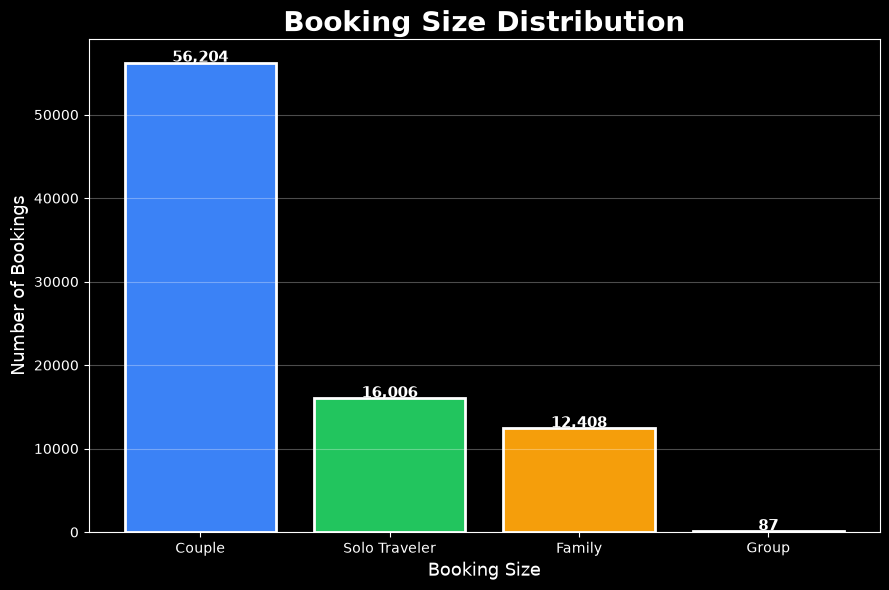

In [285]:
# bar chart
plt.style.use("dark_background")

plt.figure(figsize=(9,6))

bars = plt.bar(

    booking_size.index,

    booking_size.values,

    color=[
        "#3B82F6",
        "#22C55E",
        "#F59E0B"
    ],

    edgecolor="white",

    linewidth=2

)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+150,

        f"{int(bar.get_height()):,}",

        ha="center",

        color="white",

        fontsize=11,

        fontweight="bold"

    )

plt.title(

    "Booking Size Distribution",

    fontsize=20,

    fontweight="bold"

)

plt.xlabel(

    "Booking Size",

    fontsize=13

)

plt.ylabel(

    "Number of Bookings",

    fontsize=13

)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Save image
plt.savefig(
    "static/images/bookingsize_dist(customers).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

# Cancellation Analysis

## 1. Overall Cancellation Rate

In [286]:
# calculate cancellation counts
cancellation = (

    hotel_df["is_canceled"]

    .map({

        0: "Not Cancelled",

        1: "Cancelled"

    })

    .value_counts()

)

cancellation

is_canceled
Not Cancelled    61667
Cancelled        23038
Name: count, dtype: int64

In [287]:
# summary table

cancellation_df = pd.DataFrame({

    "Booking Status": cancellation.index,

    "Bookings": cancellation.values

})

cancellation_df["Percentage"] = (

    cancellation_df["Bookings"]

    / cancellation_df["Bookings"].sum()

    *100

).round(2)

cancellation_df

,Booking Status,Bookings,Percentage
0,Not Cancelled,61667,72.8
1,Cancelled,23038,27.2


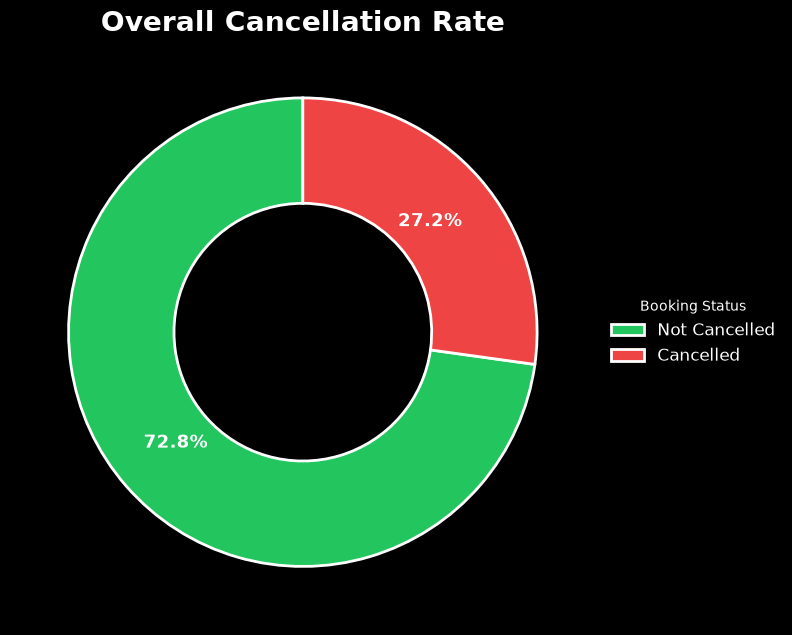

In [288]:
# donut chart
plt.style.use("dark_background")

plt.figure(figsize=(8,8))

colors = [

    "#22C55E",   # Not Cancelled

    "#EF4444"    # Cancelled

]

wedges, texts, autotexts = plt.pie(

    cancellation,

    labels=None,

    colors=colors,

    autopct="%1.1f%%",

    pctdistance=0.72,

    startangle=90,

    wedgeprops={

        "width":0.45,

        "edgecolor":"white",

        "linewidth":2

    },

    textprops={

        "color":"white",

        "fontsize":13,

        "fontweight":"bold"

    }

)

plt.legend(

    wedges,

    cancellation.index,

    title="Booking Status",

    loc="center left",

    bbox_to_anchor=(1,0.5),

    frameon=False,

    fontsize=12

)

plt.title(

    "Overall Cancellation Rate",

    fontsize=20,

    fontweight="bold"

)

plt.tight_layout()

# Save image
plt.savefig(
    "static/images/cancellation_rate(cancel).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

## 2. Cancellation by hotel type

In [289]:
# summary table

cancel_hotel = pd.crosstab(

    hotel_df["hotel"],

    hotel_df["is_canceled"]

)

cancel_hotel.index = [

    "City Hotel",

    "Resort Hotel"

]

cancel_hotel.columns = [

    "Not Cancelled",

    "Cancelled"

]

cancel_hotel

,Not Cancelled,Cancelled
City Hotel,36737,15754
Resort Hotel,24930,7284


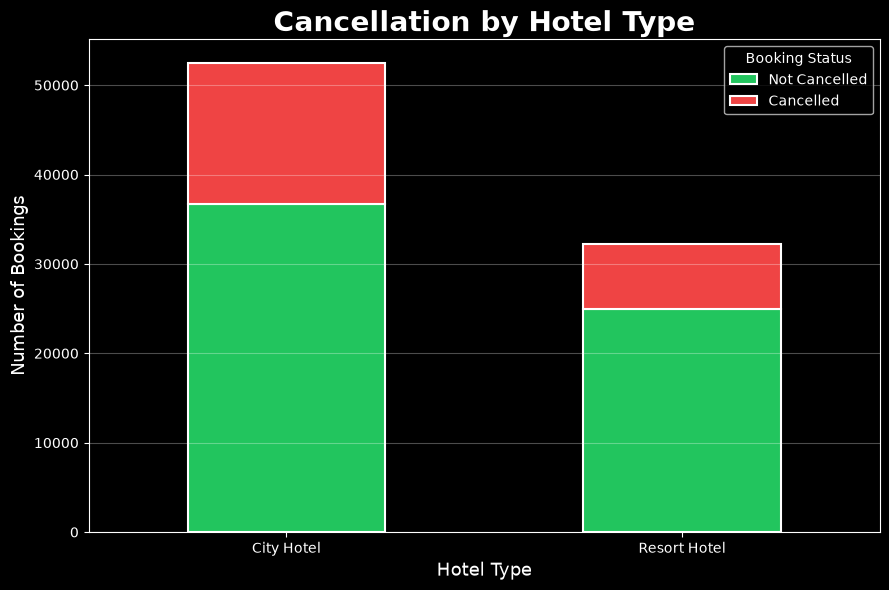

In [290]:
# stacked bar chart
plt.style.use("dark_background")

ax = cancel_hotel.plot(

    kind="bar",

    stacked=True,

    figsize=(9,6),

    color=["#22C55E", "#EF4444"],

    edgecolor="white",

    linewidth=1.5

)

plt.title(

    "Cancellation by Hotel Type",

    fontsize=20,

    fontweight="bold"

)

plt.xlabel(

    "Hotel Type",

    fontsize=13

)

plt.ylabel(

    "Number of Bookings",

    fontsize=13

)

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.legend(

    title="Booking Status"

)

plt.tight_layout()

# Save image
plt.savefig(
    "static/images/cancellation_by_hotel_type(cancel).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

In [291]:
# cancellation percentage table
cancel_percent = (

    cancel_hotel.div(

        cancel_hotel.sum(axis=1),

        axis=0

    )*100

).round(2)

cancel_percent

,Not Cancelled,Cancelled
City Hotel,69.99,30.01
Resort Hotel,77.39,22.61


## 3. Cancellation by Market Segment

In [292]:
#Create Market Segment Column
market_columns = [

    "market_segment_Complementary",

    "market_segment_Corporate",

    "market_segment_Direct",

    "market_segment_Groups",

    "market_segment_Offline TA/TO",

    "market_segment_Online TA",

    "market_segment_Undefined"

]

hotel_df["market_segment"] = (

    hotel_df[market_columns]

    .idxmax(axis=1)

    .str.replace("market_segment_", "", regex=False)

)

In [293]:
#Cancelled Bookings by Market Segment
cancel_market = (

    hotel_df[hotel_df["is_canceled"] == 1]

    .groupby("market_segment")

    .size()

    .sort_values(ascending=False)

)

cancel_market

market_segment
Online TA        17420
Offline TA/TO     2046
Direct            1606
Groups            1327
Corporate          507
Complementary      130
Undefined            2
dtype: int64

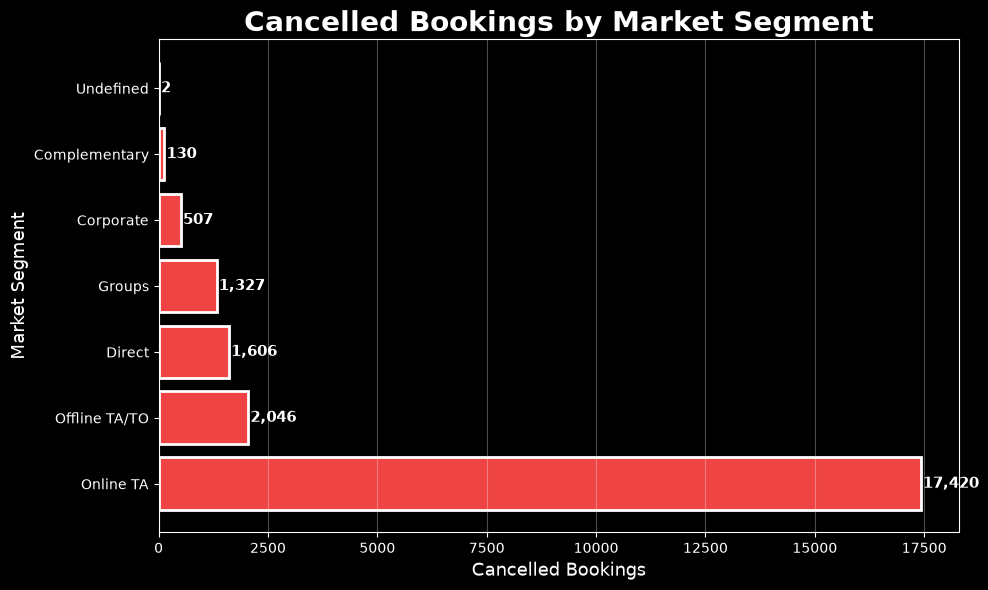

In [294]:
# Professional Horizontal Bar Chart
plt.style.use("dark_background")

plt.figure(figsize=(10,6))

bars = plt.barh(

    cancel_market.index,

    cancel_market.values,

    color="#EF4444",

    edgecolor="white",

    linewidth=2

)

for bar in bars:

    plt.text(

        bar.get_width()+50,

        bar.get_y()+bar.get_height()/2,

        f"{int(bar.get_width()):,}",

        va="center",

        color="white",

        fontsize=11,

        fontweight="bold"

    )

plt.title(

    "Cancelled Bookings by Market Segment",

    fontsize=20,

    fontweight="bold"

)

plt.xlabel("Cancelled Bookings", fontsize=13)

plt.ylabel("Market Segment", fontsize=13)

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

# Save image
plt.savefig(
    "static/images/cancellation_by_market_segment(cancel).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

In [295]:
# cancellation rate table

market_cancel_table = pd.crosstab(

    hotel_df["market_segment"],

    hotel_df["is_canceled"]

)

market_cancel_table.columns = [

    "Not Cancelled",

    "Cancelled"

]

market_cancel_table["Cancellation Rate (%)"] = (

    market_cancel_table["Cancelled"]

    /

    (

        market_cancel_table["Cancelled"]

        +

        market_cancel_table["Not Cancelled"]

    )

    *100

).round(2)

market_cancel_table.sort_values(

    by="Cancellation Rate (%)",

    ascending=False

)


,Not Cancelled,Cancelled,Cancellation Rate (%)
market_segment,,,
Undefined,0,2,100.00
Online TA,32348,17420,35.00
Groups,3568,1327,27.11
Offline TA/TO,11755,2046,14.83
Direct,9525,1606,14.43
Complementary,788,130,14.16
Corporate,3683,507,12.10


In [296]:
hotel_df.shape


(84705, 60)

## 4. Lead Time vs Cancellation

In [297]:
lead_cancel_df = (

    hotel_df

    .groupby("is_canceled")["lead_time"]

    .agg(

        Average_Lead_Time="mean",

        Median_Lead_Time="median",

        Minimum_Lead_Time="min",

        Maximum_Lead_Time="max",

        Total_Bookings="count"

    )

    .round(2)

)

lead_cancel_df.index = [

    "Not Cancelled",

    "Cancelled"

]

lead_cancel_df

,Average_Lead_Time,Median_Lead_Time,Minimum_Lead_Time,Maximum_Lead_Time,Total_Bookings
Not Cancelled,70.48,38.0,0,737,61667
Cancelled,106.36,80.0,0,629,23038


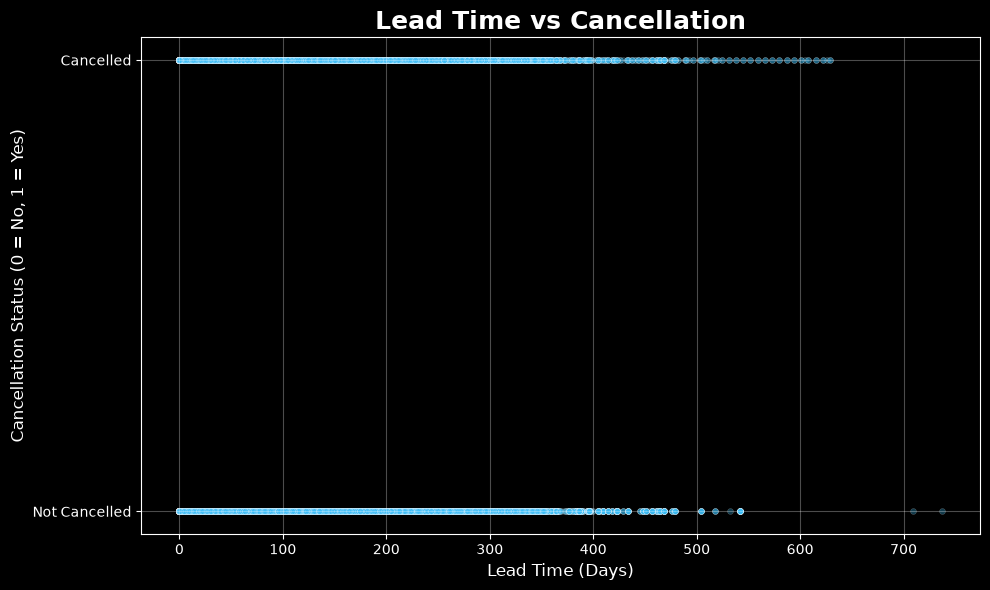

In [298]:
# scatter plot

plt.style.use("dark_background")

plt.figure(figsize=(10,6))

sns.scatterplot(

    data=hotel_df,

    x="lead_time",

    y="is_canceled",

    color="#38BDF8",

    alpha=0.30,

    s=18

)

plt.title(

    "Lead Time vs Cancellation",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Lead Time (Days)", fontsize=12)

plt.ylabel("Cancellation Status (0 = No, 1 = Yes)", fontsize=12)

plt.yticks([0,1],["Not Cancelled","Cancelled"])

plt.grid(alpha=0.3)

plt.tight_layout()

# Save image
plt.savefig(
    "static/images/leadtime_vs_cancellation(cancel).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

## 5. Cancellation ny season

In [299]:
season_cancel = pd.crosstab(

    hotel_df["booking_season"],

    hotel_df["is_canceled"]

)

season_cancel.columns = [

    "Not Cancelled",

    "Cancelled"

]

season_cancel["Cancellation Rate (%)"] = (

    season_cancel["Cancelled"]

    /

    (

        season_cancel["Cancelled"]

        +

        season_cancel["Not Cancelled"]

    )

    *100

).round(2)

season_cancel

,Not Cancelled,Cancelled,Cancellation Rate (%)
booking_season,,,
Autumn,14174,4293,23.25
Spring,16924,6585,28.01
Summer,18570,8351,31.02
Winter,11999,3809,24.10


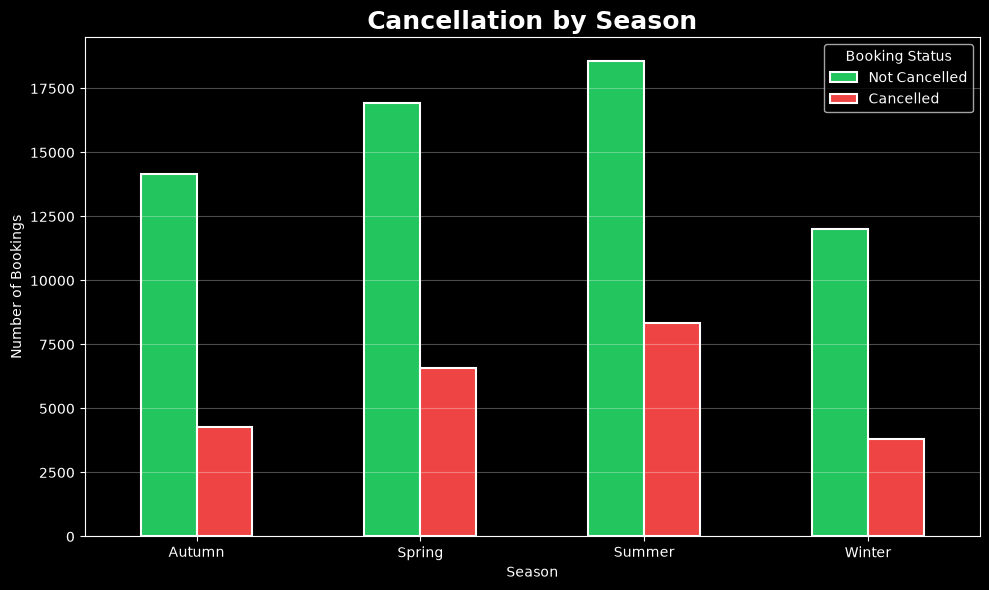

In [300]:
# grouped bar chart

plt.style.use("dark_background")

season_cancel = pd.crosstab(

    hotel_df["booking_season"],

    hotel_df["is_canceled"]

)

season_cancel.columns = [

    "Not Cancelled",

    "Cancelled"

]

season_cancel.plot(

    kind="bar",

    figsize=(10,6),

    color=["#22C55E","#EF4444"],

    edgecolor="white",

    linewidth=1.5

)

plt.title(

    "Cancellation by Season",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Season")

plt.ylabel("Number of Bookings")

plt.xticks(rotation=0)

plt.grid(axis="y", alpha=0.3)

plt.legend(title="Booking Status")

plt.tight_layout()

plt.show()

## REVENUE ANALYSIS

## 1. Average Daily Rate(ADR) Distribution

In [301]:
# calculation
adr_stats = hotel_df["adr"].describe().round(2)

adr_stats

count    84705.00
mean       101.94
std         45.02
min         -6.38
25%         71.21
50%         96.90
75%        130.00
max        226.84
Name: adr, dtype: float64

In [302]:
# summary table
adr_summary = pd.DataFrame({

    "Statistic":[

        "Count",

        "Mean",

        "Standard Deviation",

        "Minimum",

        "25%",

        "Median",

        "75%",

        "Maximum"

    ],

    "Value":[

        adr_stats["count"],

        adr_stats["mean"],

        adr_stats["std"],

        adr_stats["min"],

        adr_stats["25%"],

        adr_stats["50%"],

        adr_stats["75%"],

        adr_stats["max"]

    ]

})

adr_summary

,Statistic,Value
0,Count,84705.00
1,Mean,101.94
2,Standard Deviation,45.02
3,Minimum,-6.38
4,25%,71.21
5,Median,96.90
6,75%,130.00
7,Maximum,226.84


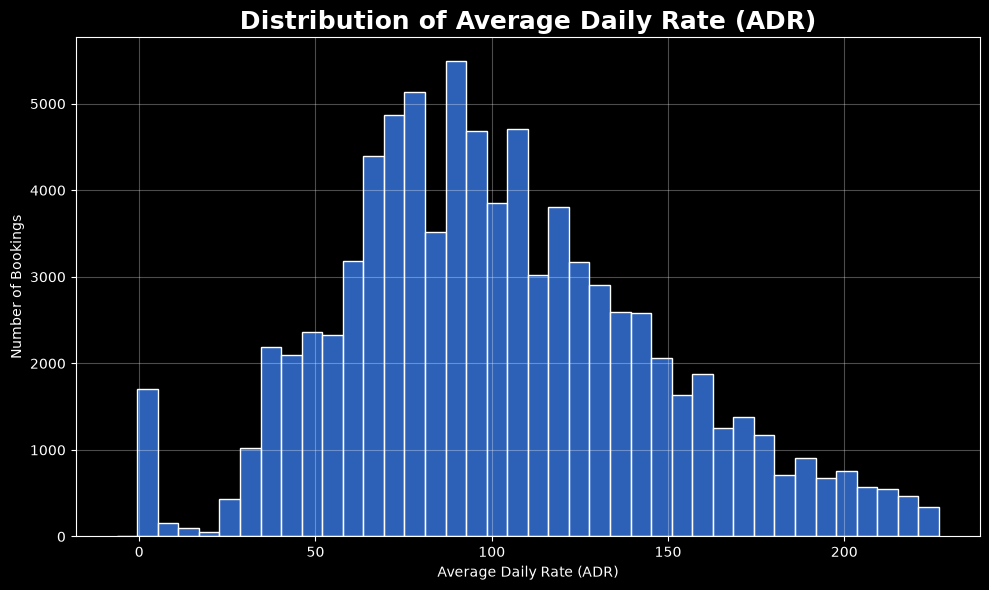

In [303]:
# visualization (histogram)
plt.style.use("dark_background")
plt.figure(figsize=(10,6))
sns.histplot(

    hotel_df["adr"],

    bins=40,

    color="#3B82F6",

    edgecolor="white"

)

plt.title(

    "Distribution of Average Daily Rate (ADR)",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Average Daily Rate (ADR)")
plt.ylabel("Number of Bookings")
plt.grid(alpha=0.3)
plt.tight_layout()

# Save image 
plt.savefig( "static/images/dist_avg_daily_rate(revenue).png", dpi=300, bbox_inches="tight", facecolor="black" )


plt.show()



## 2. Revenue by hotel type

In [304]:
# calculation

hotel_revenue = (

    hotel_df

    .groupby("hotel")["adr"]

    .agg(

        Count="count",

        Mean="mean",

        Median="median",

        Minimum="min",

        Maximum="max",

        Std="std"

    )

    .round(2)

)

hotel_revenue.index = [

    "City Hotel",

    "Resort Hotel"

]

hotel_revenue

,Count,Mean,Median,Minimum,Maximum,Std
City Hotel,52491,109.05,105.00,0.00,226.84,38.33
Resort Hotel,32214,90.35,75.53,-6.38,226.73,52.13


In [305]:
# table
hotel_revenue.reset_index(names="Hotel Type")

,Hotel Type,Count,Mean,Median,Minimum,Maximum,Std
0,City Hotel,52491,109.05,105.00,0.00,226.84,38.33
1,Resort Hotel,32214,90.35,75.53,-6.38,226.73,52.13


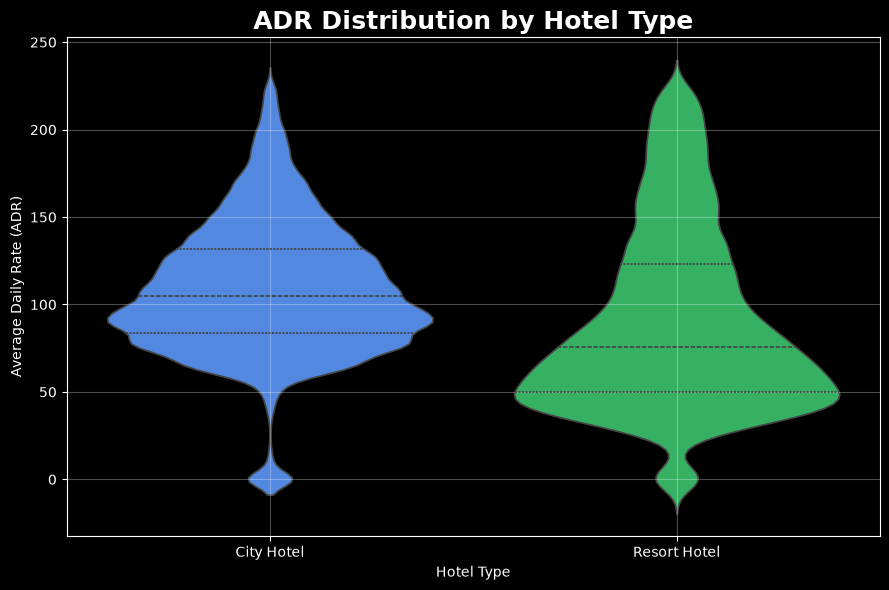

In [306]:
# violin plot
plt.style.use("dark_background")

plt.figure(figsize=(9,6))

sns.violinplot(

    data=hotel_df,

    x="hotel",

    y="adr",

    palette=["#3B82F6","#22C55E"],

    inner="quartile"

)

plt.xticks(

    [0,1],

    ["City Hotel","Resort Hotel"]

)

plt.title(

    "ADR Distribution by Hotel Type",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Hotel Type")

plt.ylabel("Average Daily Rate (ADR)")

plt.grid(alpha=0.3)

plt.tight_layout()

# Save image 
plt.savefig( "static/images/dist_adr_hotel_type(revenue).png", dpi=300, bbox_inches="tight", facecolor="black" )


plt.show()


The violin plot compares the distribution of Average Daily Rate (ADR) between City Hotels and Resort Hotels.

The width of each violin represents the concentration of bookings at different ADR values, while the quartile lines indicate the median and spread of room prices.

### Business Impact

- Compare pricing strategies between hotel types.
- Identify which hotel type generates higher room revenue.
- Support pricing optimization and revenue management.

## 3. Revenue by Season

In [307]:
# calculation
season_revenue = (

    hotel_df

    .groupby("booking_season")["adr"]

    .agg(

        Count="count",

        Average_ADR="mean",

        Median_ADR="median",

        Minimum_ADR="min",

        Maximum_ADR="max",

        Std_Deviation="std"

    )

    .round(2)

)

season_revenue

,Count,Average_ADR,Median_ADR,Minimum_ADR,Maximum_ADR,Std_Deviation
booking_season,,,,,,
Autumn,18467,92.66,89.2,0.00,226.50,41.72
Spring,23509,97.82,95.0,-6.38,225.50,40.39
Summer,26921,127.80,125.0,0.00,226.84,43.60
Winter,15808,74.87,74.8,0.00,226.00,34.15


In [308]:
# table
season_revenue = season_revenue.reset_index()
season_revenue

,booking_season,Count,Average_ADR,Median_ADR,Minimum_ADR,Maximum_ADR,Std_Deviation
0,Autumn,18467,92.66,89.2,0.00,226.50,41.72
1,Spring,23509,97.82,95.0,-6.38,225.50,40.39
2,Summer,26921,127.80,125.0,0.00,226.84,43.60
3,Winter,15808,74.87,74.8,0.00,226.00,34.15


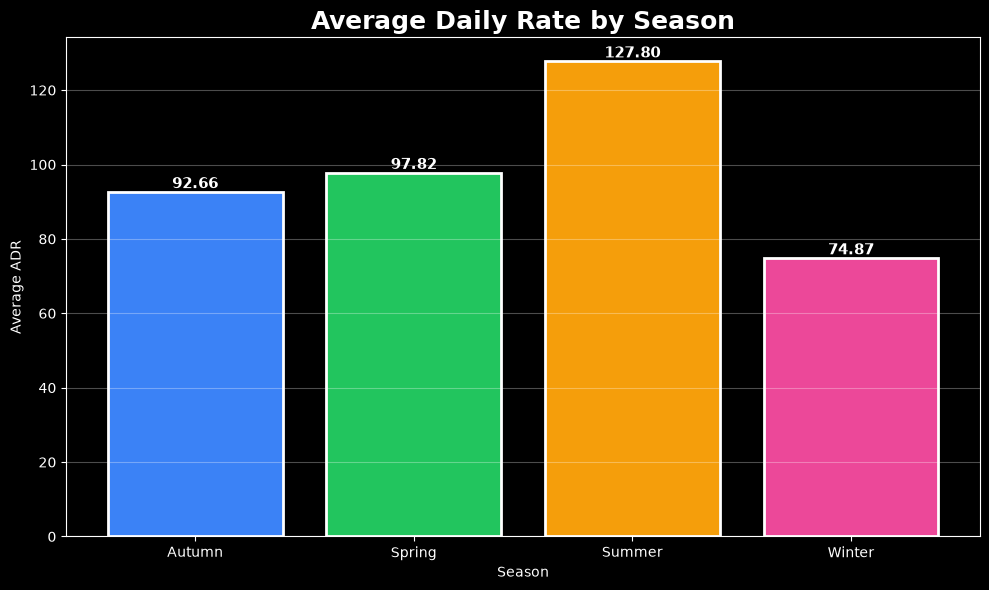

In [309]:
# Bar Chrat
plt.style.use("dark_background")

plt.figure(figsize=(10,6))

bars = plt.bar(

    season_revenue["booking_season"],

    season_revenue["Average_ADR"],

    color=[

        "#3B82F6",

        "#22C55E",

        "#F59E0B",

        "#EC4899"

    ],

    edgecolor="white",

    linewidth=2

)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height()+1,

        f"{bar.get_height():.2f}",

        ha="center",

        fontsize=11,

        color="white",

        fontweight="bold"

    )

plt.title(

    "Average Daily Rate by Season",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Season")

plt.ylabel("Average ADR")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Save image 
plt.savefig( "static/images/revenue_by_season(revenue).png", dpi=300, bbox_inches="tight", facecolor="black" )


plt.show()

## 4. Weekend vs Weekday Revenue

In [310]:
# calculation
revenue_stay = (

    hotel_df

    .groupby("stay_type")["adr"]

    .agg(

        Count="count",

        Average_ADR="mean",

        Median_ADR="median",

        Minimum_ADR="min",

        Maximum_ADR="max",

        Std_Deviation="std"

    )

    .round(2)

)

revenue_stay


,Count,Average_ADR,Median_ADR,Minimum_ADR,Maximum_ADR,Std_Deviation
stay_type,,,,,,
Balanced Stay,10086,97.73,95.00,0.00,226.35,47.75
Weekday Stay,64899,102.76,97.16,-6.38,226.84,44.92
Weekend Stay,9720,100.86,96.30,0.00,226.00,42.42


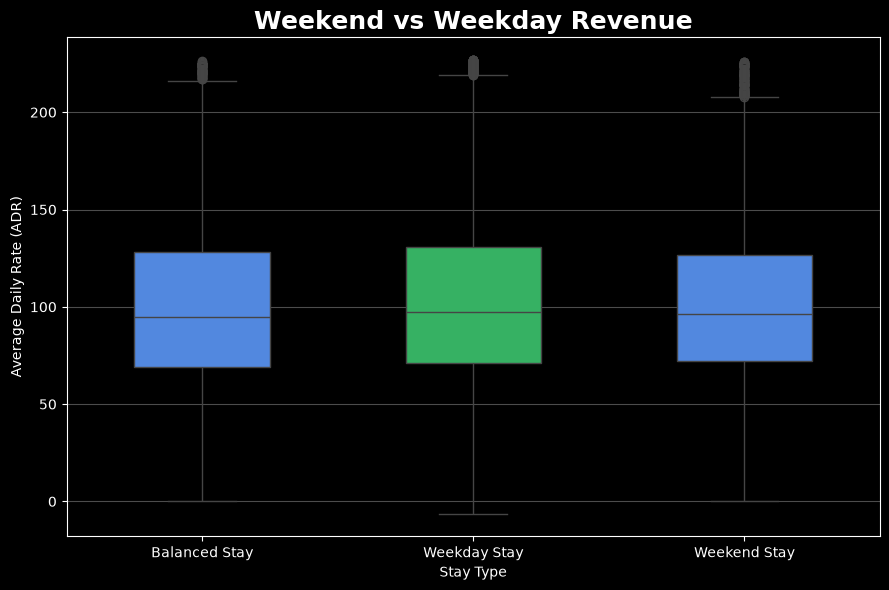

In [311]:
# box plot
plt.style.use("dark_background")

plt.figure(figsize=(9,6))

sns.boxplot(

    data=hotel_df,

    x="stay_type",

    y="adr",

    palette=["#3B82F6","#22C55E"],

    width=0.5

)

plt.title(

    "Weekend vs Weekday Revenue",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Stay Type")

plt.ylabel("Average Daily Rate (ADR)")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Save image
plt.savefig(
    "static/images/weekend_vs_weekday_revenue(revenue).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)


plt.show()

The box plot compares the distribution of Average Daily Rate (ADR) for weekend and weekday stays.

Differences in the median and spread of ADR indicate how hotel pricing varies depending on the type of stay.

# Stay Analysis

## 1. Stay Duration Distribution

In [312]:
# calculate
stay_duration = hotel_df["total_stay_duration"].describe().round(2)

stay_duration

count    84705.00
mean         3.61
std          2.75
min          0.00
25%          2.00
50%          3.00
75%          5.00
max         69.00
Name: total_stay_duration, dtype: float64

In [313]:
# summary table
stay_summary = pd.DataFrame({

    "Statistic":[

        "Count",

        "Mean",

        "Standard Deviation",

        "Minimum",

        "25%",

        "Median",

        "75%",

        "Maximum"

    ],

    "Value":[

        stay_duration["count"],

        stay_duration["mean"],

        stay_duration["std"],

        stay_duration["min"],

        stay_duration["25%"],

        stay_duration["50%"],

        stay_duration["75%"],

        stay_duration["max"]

    ]

})

stay_summary


,Statistic,Value
0,Count,84705.00
1,Mean,3.61
2,Standard Deviation,2.75
3,Minimum,0.00
4,25%,2.00
5,Median,3.00
6,75%,5.00
7,Maximum,69.00


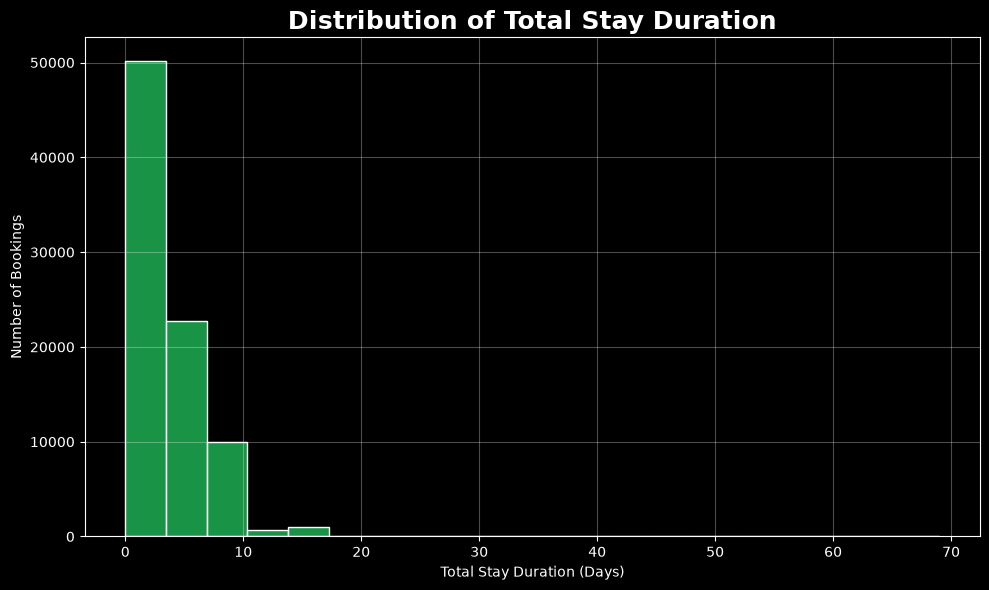

In [314]:
# histogram
plt.style.use("dark_background")

plt.figure(figsize=(10,6))

sns.histplot(

    hotel_df["total_stay_duration"],

    bins=20,

    color="#22C55E",

    edgecolor="white"

)

plt.title(

    "Distribution of Total Stay Duration",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Total Stay Duration (Days)")

plt.ylabel("Number of Bookings")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "static/images/total_stay_duration(stay).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

## 2. Adults, Children & Babies Distribution

In [315]:
# calcculate
guest_counts = pd.DataFrame({

    "Guest Type": [

        "Adults",

        "Children",

        "Babies"

    ],

    "Total Guests": [

        hotel_df["adults"].sum(),

        hotel_df["children"].sum(),

        hotel_df["babies"].sum()

    ]

})

guest_counts

,Guest Type,Total Guests
0,Adults,158429.0
1,Children,9974.0
2,Babies,887.0


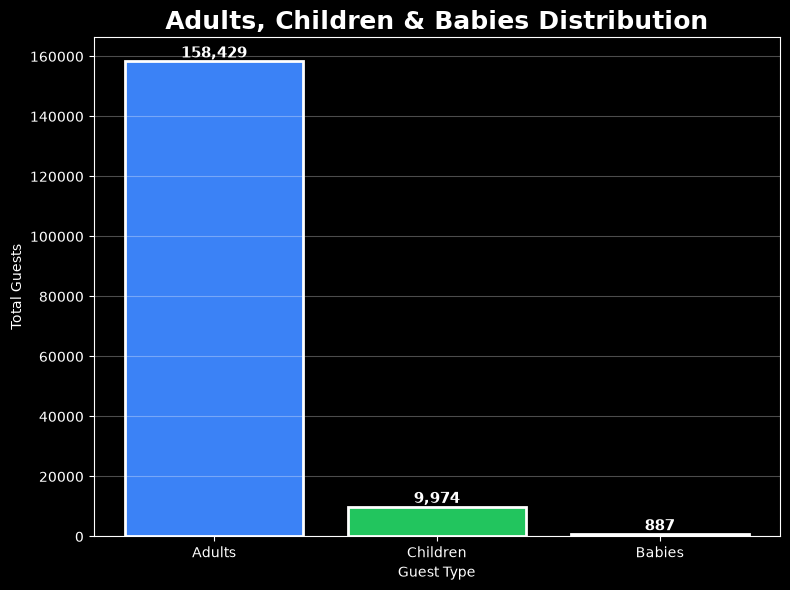

In [316]:
# grouped bar chart
plt.style.use("dark_background")

plt.figure(figsize=(8,6))

bars = plt.bar(

    guest_counts["Guest Type"],

    guest_counts["Total Guests"],

    color=[

        "#3B82F6",

        "#22C55E",

        "#F59E0B"

    ],

    edgecolor="white",

    linewidth=2

)

for bar in bars:

    plt.text(

        bar.get_x()+bar.get_width()/2,

        bar.get_height(),

        f"{int(bar.get_height()):,}",

        ha="center",

        va="bottom",

        fontsize=11,

        color="white",

        fontweight="bold"

    )

plt.title(

    "Adults, Children & Babies Distribution",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Guest Type")

plt.ylabel("Total Guests")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "static/images/adults_child_bby_dist(stay).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

## 3. Special Requests Analysis

In [317]:
# calculate
special_requests = (

    hotel_df["total_of_special_requests"]

    .value_counts()

    .sort_index()

)

special_requests

total_of_special_requests
0    42691
1    28133
2    11363
3     2193
4      292
5       33
Name: count, dtype: int64

In [318]:
# table
special_request_df = pd.DataFrame({

    "Number of Special Requests": special_requests.index,

    "Bookings": special_requests.values

})

special_request_df["Percentage"] = (

    special_request_df["Bookings"]

    /

    special_request_df["Bookings"].sum()

    *100

).round(2)

special_request_df

,Number of Special Requests,Bookings,Percentage
0,0,42691,50.40
1,1,28133,33.21
2,2,11363,13.41
3,3,2193,2.59
4,4,292,0.34
5,5,33,0.04


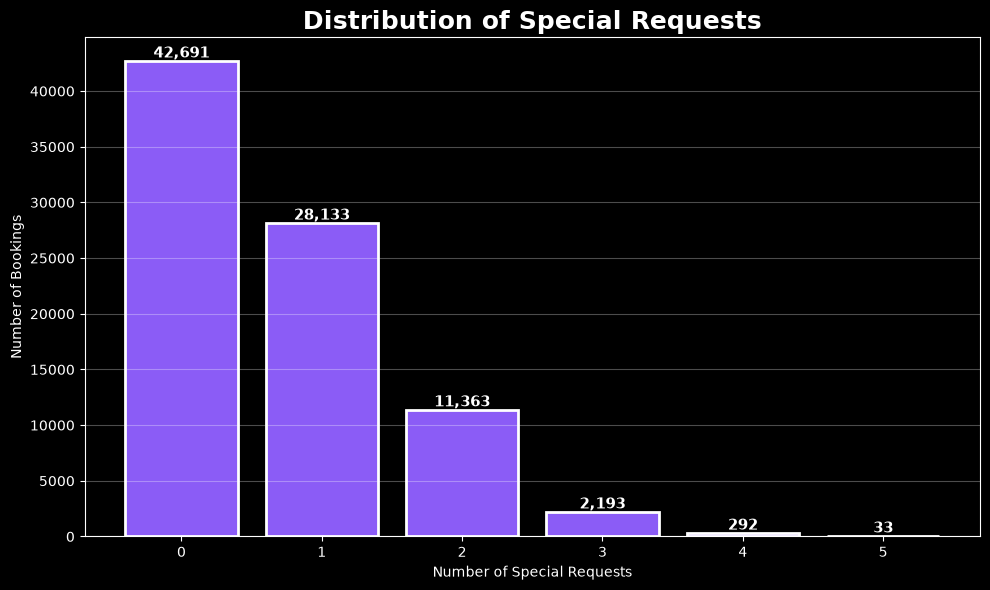

In [319]:
# bar chart

plt.style.use("dark_background")

plt.figure(figsize=(10,6))

bars = plt.bar(

    special_request_df["Number of Special Requests"].astype(str),

    special_request_df["Bookings"],

    color="#8B5CF6",

    edgecolor="white",

    linewidth=2

)

for bar in bars:

    plt.text(

        bar.get_x() + bar.get_width()/2,

        bar.get_height(),

        f"{int(bar.get_height()):,}",

        ha="center",

        va="bottom",

        fontsize=11,

        color="white",

        fontweight="bold"

    )

plt.title(

    "Distribution of Special Requests",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Number of Special Requests")

plt.ylabel("Number of Bookings")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    "static/images/special_request_dist(stay).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

## 4. Special Requests Trend

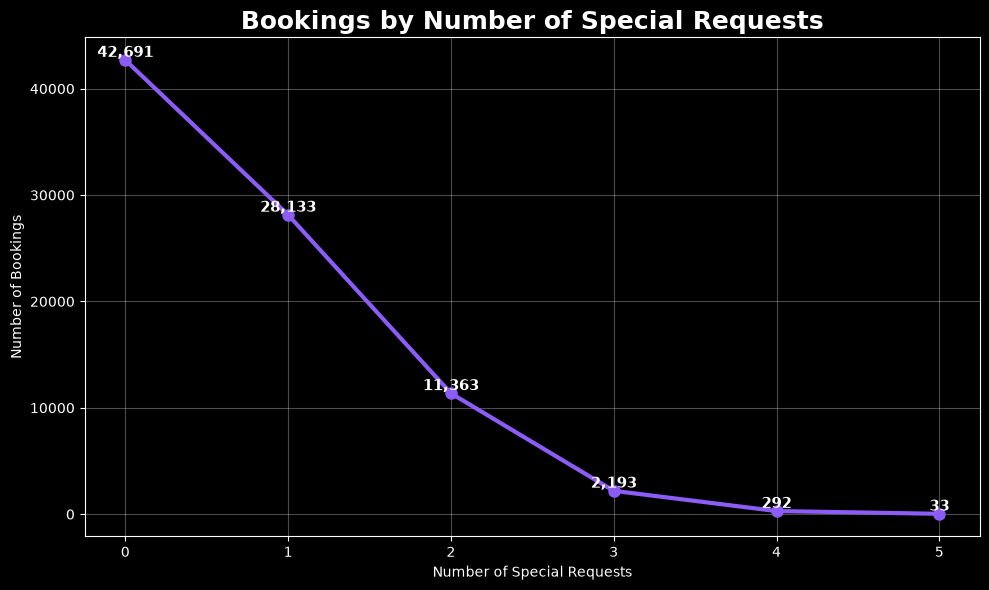

In [320]:
# line chart

plt.style.use("dark_background")

plt.figure(figsize=(10,6))

plt.plot(

    special_request_df["Number of Special Requests"],

    special_request_df["Bookings"],

    marker="o",

    linewidth=3,

    markersize=8,

    color="#8B5CF6"

)

for x, y in zip(

    special_request_df["Number of Special Requests"],

    special_request_df["Bookings"]

):

    plt.text(

        x,

        y + 300,

        f"{y:,}",

        ha="center",

        color="white",

        fontsize=11,

        fontweight="bold"

    )

plt.title(

    "Bookings by Number of Special Requests",

    fontsize=18,

    fontweight="bold"

)

plt.xlabel("Number of Special Requests")

plt.ylabel("Number of Bookings")

plt.xticks(special_request_df["Number of Special Requests"])

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "static/images/special_requests_trends(stay).png",
    dpi=300,
    bbox_inches="tight",
    facecolor="black"
)

plt.show()

# Phase 7 – Statistical Decision Report

## Objective

The Statistical Decision Report summarizes the results of all statistical analyses performed on the Hotel Booking Demand dataset. It includes assumption testing, hypothesis testing, statistical significance, business conclusions, and recommendations.

The report provides evidence-based insights that support hotel management in improving booking strategies, reducing cancellations, optimizing pricing, and enhancing customer satisfaction.

## Assumption Testing Summary

In [321]:
pip install dataframe_image

Note: you may need to restart the kernel to use updated packages.


In [322]:
import dataframe_image as dfi
assumption_summary = pd.DataFrame({

    "Assumption":[

        "Normality",

        "Homogeneity of Variance"

    ],

    "Statistical Test":[

        "Shapiro-Wilk",

        "Levene Test"

    ],

    "Test Statistic":[

        0.9846,

        3113.0008

    ],

    "P-value":[

        0.0000,

        0.0000

    ],

    "Decision":[

        "Reject Normality",

        "Reject Equal Variance"

    ]

})

assumption_summary




,Assumption,Statistical Test,Test Statistic,P-value,Decision
0,Normality,Shapiro-Wilk,0.9846,0.0,Reject Normality
1,Homogeneity of Variance,Levene Test,3113.0008,0.0,Reject Equal Variance


In [323]:
assumption_summary = assumption_summary.astype(str)

In [324]:
import dataframe_image as dfi

# Convert values to string
assumption_summary = assumption_summary.astype(str)

dfi.export(
    assumption_summary,
    "dataset/assumption_summary.png",
    table_conversion="matplotlib"
)

print("Image saved")

Image saved


The dataset was evaluated using standard statistical assumption tests before conducting hypothesis testing.

The Shapiro-Wilk test indicated that the data is not normally distributed. Similarly, Levene's Test confirmed unequal variances between comparison groups. Correlation analysis identified significant relationships among several variables, while Variance Inflation Factor (VIF) analysis revealed multicollinearity among engineered features.

Therefore, both parametric and non-parametric statistical methods were selected based on the validity of assumptions.

## Statistical Test Selection

Different statistical tests were selected based on the research objective, data type, and the results of assumption testing. Since the dataset did not satisfy all parametric assumptions, both parametric and non-parametric statistical tests were used to ensure reliable and valid conclusions.

In [325]:
test_selection = pd.DataFrame({

    "Research Objective":[

        "Compare ADR between Hotel Types",

        "Compare ADR across Booking Seasons",

        "Measure relationship between Lead Time and ADR",

        "Measure association between Hotel Type and Cancellation",

        "Compare Lead Time between Cancelled and Non-Cancelled Bookings",

        "Compare ADR across Customer Types",

        "Measure monotonic relationship between Lead Time and Special Requests"

    ],

    "Statistical Test":[

        "Independent t-Test",

        "One-Way ANOVA",

        "Pearson Correlation",

        "Chi-Square Test",

        "Mann–Whitney U Test",

        "Kruskal–Wallis Test",

        "Spearman Correlation"

    ],

    "Reason for Selection":[

        "Compare the means of two independent groups.",

        "Compare the means of more than two groups.",

        "Measure the strength of a linear relationship.",

        "Determine the association between categorical variables.",

        "Compare two independent groups when normality is violated.",

        "Compare more than two independent groups when assumptions are violated.",

        "Measure the strength of a monotonic relationship between variables."

    ]

})

test_selection

,Research Objective,Statistical Test,Reason for Selection
0,Compare ADR between Hotel Types,Independent t-Test,Compare the means of two independent groups.
1,Compare ADR across Booking Seasons,One-Way ANOVA,Compare the means of more than two groups.
2,Measure relationship between Lead Time and ADR,Pearson Correlation,Measure the strength of a linear relationship.
3,Measure association between Hotel Type and Can...,Chi-Square Test,Determine the association between categorical ...
4,Compare Lead Time between Cancelled and Non-Ca...,Mann–Whitney U Test,Compare two independent groups when normality ...
5,Compare ADR across Customer Types,Kruskal–Wallis Test,Compare more than two independent groups when ...
6,Measure monotonic relationship between Lead Ti...,Spearman Correlation,Measure the strength of a monotonic relationsh...


Appropriate statistical tests were selected according to the research objective, data characteristics, and assumption testing results.

Parametric tests were applied where suitable, while non-parametric alternatives were used whenever the assumptions of normality or equal variance were violated. This approach ensures reliable and statistically valid conclusions.

## Hypothesis Testing Outcomes

This section summarizes the results of all hypothesis tests performed during the statistical analysis. Each test is evaluated using its test statistic, p-value, decision, and business interpretation.

In [326]:
hypothesis_report = pd.DataFrame({

    "Statistical Test":[

        "Independent t-Test",

        "One-Way ANOVA",

        "Pearson Correlation",

        "Chi-Square Test",

        "Mann–Whitney U Test",

        "Kruskal–Wallis Test",

        "Spearman Correlation"

    ],

    "Test Statistic":[

        "t = 55.8138",

        "F = 1857.6878",

        "r = 0.0383",

        "χ² = 551.9297",

        "U = 1.108985e+09",

        "H = 3938.9729",

        "ρ = 0.1109"

    ],

    "P-value":[

        "0.0000",

        "0.0000",

        "7.31 × 10⁻²⁹",

        "4.79 × 10⁻¹²²",

        "0.0000",

        "0.0000",

        "4.83 × 10⁻²³⁰"

    ],

    "Decision":[

        "Reject H₀",

        "Reject H₀",

        "Reject H₀",

        "Reject H₀",

        "Reject H₀",

        "Reject H₀",

        "Reject H₀"

    ]

})

hypothesis_report

,Statistical Test,Test Statistic,P-value,Decision
0,Independent t-Test,t = 55.8138,0.0000,Reject H₀
1,One-Way ANOVA,F = 1857.6878,0.0000,Reject H₀
2,Pearson Correlation,r = 0.0383,7.31 × 10⁻²⁹,Reject H₀
3,Chi-Square Test,χ² = 551.9297,4.79 × 10⁻¹²²,Reject H₀
4,Mann–Whitney U Test,U = 1.108985e+09,0.0000,Reject H₀
5,Kruskal–Wallis Test,H = 3938.9729,0.0000,Reject H₀
6,Spearman Correlation,ρ = 0.1109,4.83 × 10⁻²³⁰,Reject H₀


### Interpretation

Seven statistical hypothesis tests were conducted to evaluate differences and relationships among key hotel booking variables.

All tests produced p-values less than the significance level of 0.05. Therefore, the null hypothesis (H₀) was rejected for every statistical test.

## Statistical Decision Summary

In [327]:
decision_summary = pd.DataFrame({

    "Decision Criterion":[

        "Significance Level (α)",

        "Confidence Level",

        "Number of Tests Performed",

        "Tests with p < 0.05",

        "Overall Statistical Decision"

    ],

    "Result":[

        "0.05",

        "95%",

        "7",

        "7",

        "Reject All Null Hypotheses"

    ]

})

decision_summary

,Decision Criterion,Result
0,Significance Level (α),0.05
1,Confidence Level,95%
2,Number of Tests Performed,7
3,Tests with p < 0.05,7
4,Overall Statistical Decision,Reject All Null Hypotheses


### Statistical Decision Summary

All seven hypothesis tests produced statistically significant results at the 95% confidence level (α = 0.05).

Since every p-value was less than 0.05, the null hypothesis was rejected in each case. This confirms that the observed differences and relationships within the hotel booking dataset are statistically significant and unlikely to have occurred by random chance.

The statistical evidence supports the reliability of the findings and provides a strong foundation for business decision-making.

## Business Conclusions

The statistical analysis of the Hotel Booking Demand dataset provides valuable insights into customer booking behaviour, cancellation patterns, hotel pricing, and seasonal demand. The results obtained from descriptive statistics, assumption testing, hypothesis testing, and exploratory data analysis support evidence-based business decision-making.

In [328]:
# table

business_conclusion = pd.DataFrame({

    "Business Area":[

        "Booking Behaviour",

        "Customer Behaviour",

        "Cancellation Analysis",

        "Revenue Analysis",

        "Seasonal Trends",

        "Statistical Analysis"

    ],

    "Conclusion":[

        "Booking patterns vary significantly across different hotel types and seasons.",

        "Customer characteristics influence booking behaviour and stay preferences.",

        "Booking cancellations are significantly associated with hotel type, market segment, and lead time.",

        "Average Daily Rate (ADR) differs across hotel types and seasons, affecting revenue generation.",

        "Seasonal demand influences occupancy levels and pricing strategies.",

        "All hypothesis tests confirmed statistically significant relationships within the dataset."

    ]

})

business_conclusion

,Business Area,Conclusion
0,Booking Behaviour,Booking patterns vary significantly across dif...
1,Customer Behaviour,Customer characteristics influence booking beh...
2,Cancellation Analysis,Booking cancellations are significantly associ...
3,Revenue Analysis,Average Daily Rate (ADR) differs across hotel ...
4,Seasonal Trends,Seasonal demand influences occupancy levels an...
5,Statistical Analysis,All hypothesis tests confirmed statistically s...


## Key Recommendations

Based on the statistical findings and business insights obtained from the analysis, the following recommendations are proposed to improve hotel performance and customer satisfaction.

In [329]:
# table

recommendation_report = pd.DataFrame({

    "Recommendation":[

        "Reduce Booking Cancellations",

        "Improve Revenue Management",

        "Optimize Seasonal Pricing",

        "Increase Direct Bookings",

        "Enhance Customer Experience",

        "Use Predictive Analytics"

    ],

    "Expected Benefit":[

        "Lower revenue loss caused by cancellations.",

        "Increase profitability through optimized room pricing.",

        "Maximize occupancy during peak and off-peak seasons.",

        "Reduce dependency on third-party booking channels.",

        "Improve customer satisfaction and guest retention.",

        "Forecast demand and support strategic decision-making."

    ]

})

recommendation_report

,Recommendation,Expected Benefit
0,Reduce Booking Cancellations,Lower revenue loss caused by cancellations.
1,Improve Revenue Management,Increase profitability through optimized room ...
2,Optimize Seasonal Pricing,Maximize occupancy during peak and off-peak se...
3,Increase Direct Bookings,Reduce dependency on third-party booking chann...
4,Enhance Customer Experience,Improve customer satisfaction and guest retent...
5,Use Predictive Analytics,Forecast demand and support strategic decision...


In [332]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
PageBreak
)

from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from reportlab.lib.pagesizes import A4


pdf_path = "dataset/statistical_summary_report.pdf"

from reportlab.lib.enums import TA_CENTER
from reportlab.lib.colors import HexColor
from reportlab.lib.styles import ParagraphStyle
from reportlab.lib.units import inch

doc = SimpleDocTemplate(
    pdf_path,
    pagesize=A4,
    rightMargin=0.5*inch,
    leftMargin=0.5*inch,
    topMargin=0.6*inch,
    bottomMargin=0.6*inch
)

styles = getSampleStyleSheet()
styles.add(
    ParagraphStyle(
        name="MainTitle",
        fontSize=22,
        leading=28,
        alignment=TA_CENTER,
        textColor=HexColor("#0B5394"),
        spaceAfter=15
    )
)

styles.add(
    ParagraphStyle(
        name="Section",
        fontSize=15,
        leading=20,
        textColor=HexColor("#0B5394"),
        spaceBefore=12,
        spaceAfter=8
    )
)

styles.add(
    ParagraphStyle(
        name="NormalText",
        fontSize=10,
        leading=16,
        spaceAfter=8
    )
)

styles.add(
    ParagraphStyle(
        name="TableHeader",
        parent=styles["BodyText"],
        fontName="Helvetica-Bold",
        fontSize=10,
        textColor=colors.white,
        alignment=TA_CENTER
    )
)

content = []


# Replace Unicode H₀ with HTML subscript
hypothesis_report = hypothesis_report.replace(
    "H₀",
    "H<sub>0</sub>",
    regex=True
)

decision_summary = decision_summary.replace(
    "H₀",
    "H<sub>0</sub>",
    regex=True
)

def add_dataframe_table(title, dataframe):

    content.append(
        Paragraph(title, styles["Section"])
    )

    # -------------------------
    # Header
    # -------------------------

    table_data = [[
        Paragraph(col, styles["TableHeader"])
        for col in dataframe.columns
    ]]

    # -------------------------
    # Rows
    # -------------------------

    for row in dataframe.values.tolist():

        table_data.append([
            Paragraph(str(item), styles["BodyText"])
            for item in row
        ])

    # -------------------------
    # Different widths
    # -------------------------

    cols = len(dataframe.columns)

    if cols == 3:

        col_widths = [
            2.8*inch,
            1.7*inch,
            2.5*inch
        ]

    elif cols == 4:

        col_widths = [
            2.0*inch,
            1.5*inch,
            1.2*inch,
            2.3*inch
        ]

    elif cols == 5:

        col_widths = [
            1.8*inch,
            1.2*inch,
            1.2*inch,
            1.2*inch,
            1.8*inch
        ]

    else:

        col_widths = [doc.width/cols]*cols

    table = Table(
        table_data,
        colWidths=col_widths,
        repeatRows=1
    )

    table.setStyle(TableStyle([

        ("BACKGROUND",(0,0),(-1,0),HexColor("#1E3A8A")),
        ("TEXTCOLOR",(0,0),(-1,0),colors.white),

        ("FONTNAME",(0,0),(-1,0),"Helvetica-Bold"),
        ("FONTSIZE",(0,0),(-1,0),10),

        ("BACKGROUND",(0,1),(-1,-1),colors.whitesmoke),

        ("GRID",(0,0),(-1,-1),0.5,colors.grey),

        ("BOX",(0,0),(-1,-1),1,colors.black),

        ("VALIGN",(0,0),(-1,-1),"TOP"),

        ("LEFTPADDING",(0,0),(-1,-1),6),
        ("RIGHTPADDING",(0,0),(-1,-1),6),

        ("TOPPADDING",(0,0),(-1,-1),6),
        ("BOTTOMPADDING",(0,0),(-1,-1),6),

    ]))

    content.append(table)

    content.append(Spacer(1,12))



# Title

content.append(
    Paragraph(
        "HOTEL BOOKING DEMAND ANALYTICS",
        styles["MainTitle"]
    )
)

content.append(
    Paragraph(
        "Statistical Summary Report",
        styles["Heading2"]
    )
)

content.append(Spacer(1,18))


# Introduction

content.append(
    Paragraph(
        """
        This report summarizes the statistical analysis performed on the Hotel
        Booking Demand dataset. The analysis includes assumption testing,
        statistical test selection, hypothesis testing, business conclusions,
        and recommendations.
        """,
        styles["NormalText"]
    )
)

content.append(Spacer(1,10))



# 1 Assumption Testing

add_dataframe_table(
    "1. Assumption Testing Summary",
    assumption_summary
)


content.append(
    Paragraph(
        """
        The Shapiro-Wilk test indicated that the dataset is not normally distributed.
        Levene's test confirmed unequal variances. Based on these results,
        suitable parametric and non-parametric statistical methods were selected.
        """,
        styles["NormalText"]
    )
)

content.append(Spacer(1,10))



# 2 Test Selection

add_dataframe_table(
    "2. Statistical Test Selection",
    test_selection
)


content.append(
    Paragraph(
        """
        Statistical tests were selected based on research objectives,
        variable types, and assumption testing results.
        """,
        styles["NormalText"]
    )
)

content.append(Spacer(1,10))



# 3 Hypothesis Testing

add_dataframe_table(
    "3. Hypothesis Testing Outcomes",
    hypothesis_report
)


content.append(
    Paragraph(
        """
        Seven hypothesis tests were performed. All tests produced p-values
        below the significance level of 0.05. Therefore, all null hypotheses
        were rejected, confirming statistically significant results.
        """,
        styles["NormalText"]
    )
)

content.append(Spacer(1,10))



# 4 Decision Summary

add_dataframe_table(
    "4. Statistical Decision Summary",
    decision_summary
)


content.append(PageBreak())



# 5 Business Conclusions

add_dataframe_table(
    "5. Business Conclusions",
    business_conclusion
)



# 6 Recommendations

add_dataframe_table(
    "6. Key Recommendations",
    recommendation_report
)



content.append(
    Paragraph(
        """
        Final Conclusion:

        The statistical analysis provides evidence-based insights for improving
        hotel revenue management, reducing cancellations, optimizing seasonal
        pricing, increasing direct bookings, and enhancing customer satisfaction.
        """,
        styles["NormalText"]
    )
)



doc.build(content)


print("Statistical Summary Report Created Successfully")

Statistical Summary Report Created Successfully


In [333]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Table,
    TableStyle,
PageBreak,
Image
)

from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY
from reportlab.lib import colors

import pandas as pd

from reportlab.lib.styles import getSampleStyleSheet
styles = getSampleStyleSheet()

pdf_path = "dataset/EDA_summary_report.pdf"

doc = SimpleDocTemplate(
    pdf_path,
    rightMargin=40,
    leftMargin=40,
    topMargin=40,
    bottomMargin=40
)

# Modify Existing Styles

# Title
styles["Title"].fontName = "Helvetica-Bold"
styles["Title"].fontSize = 24
styles["Title"].leading = 30
styles["Title"].alignment = TA_CENTER
styles["Title"].spaceAfter = 20

# Heading 2
styles["Heading2"].fontName = "Helvetica-Bold"
styles["Heading2"].fontSize = 18
styles["Heading2"].leading = 24
styles["Heading2"].spaceBefore = 12
styles["Heading2"].spaceAfter = 10
styles["Heading2"].textColor = colors.HexColor("#1F4E79")

# Heading 3
styles["Heading3"].fontName = "Helvetica-Bold"
styles["Heading3"].fontSize = 14
styles["Heading3"].leading = 18
styles["Heading3"].spaceBefore = 8
styles["Heading3"].spaceAfter = 8
styles["Heading3"].textColor = colors.HexColor("#1F4E79")

# Body Text
styles["BodyText"].fontName = "Helvetica"
styles["BodyText"].fontSize = 11
styles["BodyText"].leading = 20
styles["BodyText"].alignment = TA_JUSTIFY
styles["BodyText"].spaceAfter = 12

content = []


def add_dataframe_table(title, dataframe):

    content.append(
        Paragraph(title, styles["Heading3"])
    )

    table_data = [
        list(dataframe.columns)
    ] + dataframe.values.tolist()


    table = Table(
        table_data,
        repeatRows=1
    )


    table.setStyle(
    TableStyle([

        ("BACKGROUND", (0,0), (-1,0), colors.HexColor("#1F4E79")),
        ("TEXTCOLOR", (0,0), (-1,0), colors.white),
        ("FONTNAME", (0,0), (-1,0), "Helvetica-Bold"),
        ("FONTSIZE", (0,0), (-1,0), 10),

        ("FONTNAME", (0,1), (-1,-1), "Helvetica"),
        ("FONTSIZE", (0,1), (-1,-1), 9),

        ("BACKGROUND", (0,1), (-1,-1), colors.whitesmoke),

        ("GRID", (0,0), (-1,-1), 0.5, colors.grey),

        ("BOX", (0,0), (-1,-1), 1, colors.black),

        ("ALIGN", (0,0), (-1,-1), "CENTER"),

        ("VALIGN", (0,0), (-1,-1), "MIDDLE"),

        ("TOPPADDING", (0,0), (-1,-1), 8),

        ("BOTTOMPADDING", (0,0), (-1,-1), 8),

        ("LEFTPADDING", (0,0), (-1,-1), 6),

        ("RIGHTPADDING", (0,0), (-1,-1), 6),
    ])
)

    content.append(table)
    content.append(Spacer(1,10))



# Title

content.append(
    Paragraph(
        "Hotel Booking Demand Analytics Platform",
        styles["Title"]
    )
)

content.append(
    Paragraph(
        "Exploratory Data Analysis (EDA) Summary Report",
        styles["Heading2"]
    )
)

content.append(Spacer(1,15))


# Introduction

content.append(
    Paragraph(
        """
        Exploratory Data Analysis (EDA) was performed on the Hotel Booking Demand
        dataset to understand booking patterns, customer behavior, cancellation
        trends, revenue performance, and hotel operations. The analysis utilizes
        descriptive statistics and data visualization techniques to identify
        meaningful trends, relationships, and business insights.

        This report presents a comprehensive summary of the dataset, key business
        performance indicators, booking trends, customer characteristics,
        cancellation behavior, revenue analysis, stay patterns, and correlation
        analysis. The findings support data-driven decision-making and provide
        valuable recommendations for improving hotel operations and customer
        satisfaction.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 1. Dataset Overview

content.append(
    Paragraph(
        "1. Dataset Overview",
        styles["Heading2"]
    )
)

content.append(
    Paragraph(
        """
        The Hotel Booking Demand dataset contains hotel reservation records
        collected from City Hotels and Resort Hotels. It provides comprehensive
        information on customer bookings, hotel characteristics, reservation
        details, stay duration, cancellation status, pricing, and customer
        demographics. This dataset is widely used for hospitality analytics
        and supports the identification of booking patterns, customer behavior,
        and business performance.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        """
        The dataset consists of 119,390 booking records and 32 features,
        including numerical, categorical, and date-related variables.
        Before performing the exploratory data analysis, the dataset was
        thoroughly preprocessed by handling missing values, removing duplicate
        records, correcting data types, treating outliers, and engineering
        new features. The cleaned dataset was then used to generate meaningful
        visualizations and business insights.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,12))

# Dataset Summary Table

dataset_summary = pd.DataFrame({
    "Attribute":[
        "Dataset Name",
        "Source",
        "Total Records",
        "Total Features",
        "Hotel Types",
        "Data Types",
        "Target Variable",
        "Data Quality"
    ],
    "Details":[
        "Hotel Booking Demand",
        "Kaggle",
        "119,390",
        "32",
        "City Hotel, Resort Hotel",
        "Numerical, Categorical, Date-Time",
        "is_canceled",
        "Cleaned, transformed, and validated for analysis"
    ]
})

add_dataframe_table(
    "Dataset Summary",
    dataset_summary
)

# 2. Business KPI Summary

content.append(
    Paragraph(
        "2. Business KPI Summary",
        styles["Heading2"]
    )
)

content.append(
    Paragraph(
        """
        The Business KPI Summary presents the most important performance
        indicators extracted from the Hotel Booking Demand dataset.
        These metrics provide a quick overview of booking volume,
        hotel performance, customer behavior, cancellation trends,
        pricing, and stay characteristics before the detailed
        exploratory data analysis.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,10))

# Calculate KPIs

total_bookings = len(df)

total_customers = len(df)

city_hotel_bookings = (df["hotel"]=="City Hotel").sum()

resort_hotel_bookings = (df["hotel"]=="Resort Hotel").sum()

cancellation_rate = df["is_canceled"].mean()*100

average_adr = df["adr"].mean()

average_stay = (
    df["stays_in_weekend_nights"] +
    df["stays_in_week_nights"]
).mean()

average_lead_time = df["lead_time"].mean()

repeat_guest_percentage = (
    df["is_repeated_guest"].mean()*100
)

average_special_requests = (
    df["total_of_special_requests"].mean()
)

# KPI Summary Table

kpi_summary = pd.DataFrame({

    "Business KPI":[

        "Total Bookings",

        "Total Customers",

        "City Hotel Bookings",

        "Resort Hotel Bookings",

        "Cancellation Rate",

        "Average Daily Rate (ADR)",

        "Average Stay Duration",

        "Average Lead Time",

        "Repeat Guest Percentage",

        "Average Special Requests"

    ],

    "Value":[

        f"{total_bookings:,}",

        f"{total_customers:,}",

        f"{city_hotel_bookings:,}",

        f"{resort_hotel_bookings:,}",

        f"{cancellation_rate:.2f}%",

        f"{average_adr:.2f}",

        f"{average_stay:.2f} Days",

        f"{average_lead_time:.2f} Days",

        f"{repeat_guest_percentage:.2f}%",

        f"{average_special_requests:.2f}"

    ]

})

add_dataframe_table(
    "Business KPI Summary",
    kpi_summary
)

content.append(PageBreak())

content.append(
    Paragraph(
        """
        The above KPIs provide a concise summary of the overall hotel booking
        performance. They highlight booking volume, hotel distribution,
        cancellation behavior, pricing trends, customer loyalty, and
        stay characteristics, forming the foundation for the detailed
        exploratory presented in the following sections.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 3.Booking Analysis

content.append(
    Paragraph(
        "3. Booking Analysis",
        styles["Heading2"]
    )
)

content.append(
    Paragraph(
        """
        Booking analysis examines reservation patterns across different
        months, hotel types, booking lead times, and seasons. This analysis
        helps identify demand fluctuations, customer booking behavior,
        and peak booking periods that support operational planning and
        revenue optimization.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 3.1 monthly booking trend

content.append(
    Paragraph(
        "3.1 Monthly Booking Trend",
        styles["Heading3"]
    )
)

content.append(Image(
    "static/images/monthly_booking_trend(booking).png",
    width=450,
    height=250
))

content.append(Spacer(1,8))

content.append(
    Paragraph(
        """
        Monthly booking analysis shows seasonal variations in hotel demand.
        Booking activity increases during holiday seasons and decreases
        during off-peak months, helping hotels optimize staffing,
        inventory, and pricing strategies.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

content.append(PageBreak())

# 3.2hotel type comparison

content.append(
    Paragraph(
        "3.2 Hotel Type Comparison",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/hotel_type_comparison(booking).png",
        width=450,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        f"""
        The hotel type comparison indicates that <b>City Hotels</b> account for
        <b>{city_hotel_bookings:,}</b> bookings, representing
        <b>{hotel_percentage.iloc[0]:.2f}%</b> of all reservations.
        In comparison, <b>Resort Hotels</b> recorded
        <b>{resort_hotel_bookings:,}</b> bookings, contributing
        <b>{hotel_percentage.iloc[1]:.2f}%</b> of the total bookings.

        The results show that City Hotels receive a significantly higher
        proportion of reservations than Resort Hotels, suggesting stronger
        demand for urban accommodations due to business travel, accessibility,
        and city-based tourism. Resort Hotels continue to attract a substantial
        share of leisure travelers, particularly during vacation and holiday
        seasons.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 3.3 Booking Lead Time Analysis

content.append(
    Paragraph(
        "3.3 Booking Lead Time Analysis",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/booking_lead_time(booking).png",
        width=450,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        f"""
        The booking lead time analysis shows that guests reserve their stays
        an average of <b>{lead_summary['mean']:.2f}</b> days before arrival,
        with booking periods ranging from <b>{lead_summary['min']:.0f}</b> to
        <b>{lead_summary['max']:.0f}</b> days. The wide variation in lead time
        indicates diverse booking behaviors, providing valuable insights for
        demand forecasting, pricing strategies, and inventory planning.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 3.4 Seasonal Booking Trends

content.append(
    Paragraph(
        "3.4 Seasonal Booking Trends",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/seasonal_booking_trend(booking).png",
        width=450,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        f"""
        Seasonal booking analysis indicates that <b>Summer</b> recorded the
        highest number of bookings with <b>{season_counts['Summer']:,}</b>
        reservations, followed by <b>Spring</b> with
        <b>{season_counts['Spring']:,}</b>. In contrast,
        <b>Autumn</b> and <b>Winter</b> registered
        <b>{season_counts['Autumn']:,}</b> and
        <b>{season_counts['Winter']:,}</b> bookings, respectively.
        These trends highlight seasonal fluctuations in hotel demand and
        provide valuable insights for capacity planning, promotional
        campaigns, and dynamic pricing strategies.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# Customer Analysis

content.append(
    Paragraph(
        "4. Customer Analysis",
        styles["Heading2"]
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        """
        Customer Analysis explores guest characteristics and booking
        behavior to understand customer preferences and market demand.
        This section examines customer types, geographical distribution,
        repeat guest behavior, and market segments. The insights help
        hotels improve customer satisfaction, strengthen loyalty,
        and develop targeted marketing strategies.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

content.append(PageBreak())

# 4.1 Customer Type Distribution

content.append(
    Paragraph(
        "4.1 Customer Type Distribution",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/customer_type_distribution(customer).png",
        width=450,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        f"""
        The majority of bookings were made by <b>Transient</b> customers
        ({customer_counts.iloc[0]:,}), followed by <b>Transient-Party</b>,
        <b>Contract</b>, and <b>Group</b> customers. This indicates that
        individual travelers contribute the largest share of hotel bookings,
        highlighting the importance of focusing on independent guests.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 4.2 Country-wise Bookings

content.append(
    Paragraph(
        "4.2 Country-wise Bookings",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/country_wise_booking(customer).png",
        width=450,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        f"""
        Portugal recorded the highest number of bookings with
        <b>{top_countries['PRT']:,}</b> reservations, followed by the
        United Kingdom (<b>{top_countries['GBR']:,}</b>),
        France (<b>{top_countries['FRA']:,}</b>), and Spain
        (<b>{top_countries['ESP']:,}</b>). The results indicate that
        hotel demand is primarily driven by domestic and European travelers.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 4.3 Repeat Guest Analysis

content.append(
    Paragraph(
        "4.3 Repeat Guest Analysis",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/repeat_guest_analysis(customer).png",
        width=450,
        height=300
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        f"""
        The dataset contains <b>{repeat_guest['New Guest']:,}</b> new guests
        and <b>{repeat_guest['Repeat Guest']:,}</b> repeat guests.
        The significantly higher proportion of new customers suggests an
        opportunity to strengthen customer loyalty through retention
        programs and personalized guest experiences.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 4.4 Market Segment Analysis

content.append(
    Paragraph(
        "4.4 Market Segment Analysis",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/market_segment_analysis(customer).png",
        width=450,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(PageBreak())

content.append(
    Paragraph(
        f"""
        <b>Online TA</b> generated the highest number of bookings
        ({market_segments['Online TA']:,}), followed by
        <b>Offline TA/TO</b> ({market_segments['Offline TA/TO']:,}),
        <b>Direct</b> ({market_segments['Direct']:,}), and
        <b>Groups</b> ({market_segments['Groups']:,}).
        This indicates that online travel agencies are the primary booking
        channel, emphasizing their importance in hotel distribution strategies.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 5 Cancellation Analysis

content.append(
    Paragraph(
        "4.5 Cancellation Analysis",
        styles["Heading3"]
    )
)

content.append(
    Paragraph(
        """
        Cancellation analysis helps identify booking cancellation patterns
        and understand factors influencing customer booking decisions.
        This analysis evaluates overall cancellation rate, cancellation
        behavior by hotel type, market segment contribution, and the
        relationship between lead time and cancellations.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,12))

# 5.1 Overall Cancellation Rate

content.append(
    Paragraph(
        "5.1 Overall Cancellation Rate",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/cancellation_rate(cancel).png",
        width=430,
        height=350
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        f"""
        The dataset contains <b>{cancellation['Not Cancelled']:,}</b>
        successful bookings and <b>{cancellation['Cancelled']:,}</b>
        cancelled bookings.
        
        The cancellation rate is approximately
        <b>{(cancellation['Cancelled'] / cancellation.sum() * 100):.2f}%</b>,
        indicating that a significant proportion of reservations were
        cancelled before arrival.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))
content.append(PageBreak())

# 5.2 Cancellation by Hotel Type

content.append(
    Paragraph(
        "5.2 Cancellation by Hotel Type",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/cancellation_by_hotel_type(cancel).png",
        width=430,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        f"""
        Cancellation behavior differs between hotel categories.
        
        <b>City Hotel</b> recorded the highest number of cancellations
        with <b>{cancel_hotel.loc['City Hotel','Cancelled']:,}</b>
        cancelled bookings compared to
        <b>{cancel_hotel.loc['Resort Hotel','Cancelled']:,}</b>
        cancellations in <b>Resort Hotel</b>.
        
        This suggests that city hotels experience greater booking
        uncertainty, possibly due to business travel patterns and
        flexible reservation behavior.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))


# 5.3 Cancellation by Market Segment

content.append(
    Paragraph(
        "5.3 Cancellation by Market Segment",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/cancellation_by_market_segment(cancel).png",
        width=430,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(PageBreak())

content.append(
    Paragraph(
        f"""
        Among different booking channels, <b>Online TA</b> contributed
        the highest number of cancelled bookings
        ({cancel_market['Online TA']:,}), followed by
        <b>Offline TA/TO</b> ({cancel_market['Offline TA/TO']:,})
        and <b>Direct bookings</b> ({cancel_market['Direct']:,}).
        
        The high cancellation volume from Online Travel Agencies
        indicates that hotels should focus on improving OTA booking
        policies and cancellation management strategies.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 5.4 Lead Time vs Cancellation

content.append(
    Paragraph(
        "5.4 Lead Time vs Cancellation Analysis",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/leadtime_vs_cancellation(cancel).png",
        width=430,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        f"""
        Lead time analysis shows a clear difference between cancelled
        and completed bookings.
        
        Cancelled reservations had an average lead time of
        <b>{lead_cancel_df.loc['Cancelled','Average_Lead_Time']:.2f}</b>
        days, whereas non-cancelled bookings had an average lead time of
        <b>{lead_cancel_df.loc['Not Cancelled','Average_Lead_Time']:.2f}</b>
        days.
        
        This indicates that bookings made far in advance have a higher
        probability of cancellation, highlighting the importance of
        effective reservation policies and demand forecasting.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 6 Revenue Analysis

content.append(
    Paragraph(
        "6 Revenue Analysis",
        styles["Heading2"]
    )
)

content.append(
    Paragraph(
        """
        Revenue analysis focuses on understanding hotel pricing patterns
        and revenue generation factors. This section analyzes Average Daily
        Rate (ADR) distribution, revenue contribution by hotel type,
        seasonal pricing variations, and revenue differences between
        weekday and weekend stays.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,12))

content.append(PageBreak())

# 6.1 Average Daily Rate (ADR) Distribution

content.append(
    Paragraph(
        "6.1 Average Daily Rate (ADR) Distribution",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/dist_avg_daily_rate(revenue).png",
        width=430,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        f"""
        Average Daily Rate (ADR) represents the average revenue earned
        per occupied room per day.
        
        The analysis shows that the average ADR is
        <b>{adr_stats['mean']:.2f}</b>, with a median value of
        <b>{adr_stats['50%']:.2f}</b>.
        
        The ADR values range from <b>{adr_stats['min']:.2f}</b> to
        <b>{adr_stats['max']:.2f}</b>, indicating variations in pricing
        based on hotel type, season, and booking conditions.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 6.2 Revenue by Hotel Type

content.append(
    Paragraph(
        "6.2 Revenue by Hotel Type",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/dist_adr_hotel_type(revenue).png",
        width=430,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(PageBreak())

content.append(
    Paragraph(
        f"""
        Revenue performance differs between City Hotel and Resort Hotel.
        
        <b>City Hotel</b> generated a higher average ADR of
        <b>{hotel_revenue.loc['City Hotel','Mean']:.2f}</b>
        compared to <b>{hotel_revenue.loc['Resort Hotel','Mean']:.2f}</b>
        for Resort Hotel.
        
        The higher ADR in City Hotels indicates stronger pricing power,
        likely due to business demand and urban location advantages.
        Resort Hotels show wider ADR variation because of seasonal demand
        patterns.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 6.3 Revenue by Season

content.append(
    Paragraph(
        "6.3 Revenue by Season",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/revenue_by_season(revenue).png",
        width=430,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        f"""
        Seasonal analysis highlights significant variations in hotel
        pricing.
        
        <b>Summer</b> recorded the highest average ADR of
        <b>{season_revenue[season_revenue['booking_season']=="Summer"]["Average_ADR"].values[0]:.2f}</b>,
        followed by <b>Spring</b> with
        <b>{season_revenue[season_revenue['booking_season']=="Spring"]["Average_ADR"].values[0]:.2f}</b>.
        
        <b>Winter</b> had the lowest average ADR at
        <b>{season_revenue[season_revenue['booking_season']=="Winter"]["Average_ADR"].values[0]:.2f}</b>,
        indicating lower demand during colder months.
        
        This suggests that hotels can optimize pricing strategies
        according to seasonal demand fluctuations.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

content.append(PageBreak())

# 6.4 Weekday vs Weekend Revenue

content.append(
    Paragraph(
        "6.4 Weekday vs Weekend Revenue Analysis",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/weekend_vs_weekday_revenue(revenue).png",
        width=430,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        f"""
        Revenue comparison between weekday and weekend stays shows
        slight differences in pricing.
        
        <b>Weekday stays</b> achieved the highest average ADR of
        <b>{revenue_stay.loc['Weekday Stay','Average_ADR']:.2f}</b>,
        while <b>Weekend stays</b> recorded an average ADR of
        <b>{revenue_stay.loc['Weekend Stay','Average_ADR']:.2f}</b>.
        
        The results indicate that weekday bookings contribute strongly
        to revenue generation, possibly due to business-related travel
        demand.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 7 Stay Analysis

content.append(
    Paragraph(
        "7 Stay Analysis",
        styles["Heading2"]
    )
)

content.append(
    Paragraph(
        """
        Stay analysis helps understand customer accommodation patterns
        and booking behavior. This analysis evaluates the distribution
        of stay duration, guest composition including adults, children,
        and babies, and the impact of special requests on hotel bookings.
        These insights help hotels optimize room planning, service
        offerings, and guest experience strategies.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,12))

content.append(PageBreak())

# 7.1 Stay Duration Distribution

content.append(
    Paragraph(
        "7.1 Stay Duration Distribution",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/total_stay_duration(stay).png",
        width=430,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        f"""
        The analysis of total stay duration shows that customers stayed
        for an average of <b>{stay_duration['mean']:.2f}</b> days.
        
        The median stay duration was <b>{stay_duration['50%']:.0f}</b>
        days, indicating that most customers preferred short stays.
        The duration ranged from <b>{stay_duration['min']:.0f}</b> to
        <b>{stay_duration['max']:.0f}</b> days, showing variations in
        customer travel requirements.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 7.2 Adults, Children & Babies Distribution

content.append(
    Paragraph(
        "7.2 Guest Type Distribution",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/adults_child_bby_dist(stay).png",
        width=430,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        f"""
        Guest composition analysis shows adults represent the
        majority of hotel visitors with a total count of
        <b>{guest_counts.loc[0,'Total Guests']:,.0f}</b>.
        
        Children accounted for <b>{guest_counts.loc[1,'Total Guests']:,.0f}</b>
        guests, while babies represented
        <b>{guest_counts.loc[2,'Total Guests']:,.0f}</b>.
        
        This indicates dataset mainly consists of adult travelers,
        with comparatively fewer family bookings involving children and
        infants.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 7.3 Special Requests Analysis

content.append(
    Paragraph(
        "7.3 Special Requests Analysis",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/special_request_dist(stay).png",
        width=430,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        f"""
        Special request analysis helps identify customer preferences
        during hotel stays.
        
        The majority of bookings had no special requests
        (<b>{special_requests[0]:,}</b> bookings), while
        <b>{special_requests[1]:,}</b> bookings included one special
        request.
        
        The number of bookings decreases as the number of requests
        increases, indicating that most customers require only limited
        additional services.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 7.4 Special Requests Trend

content.append(
    Paragraph(
        "7.4 Special Requests Trend Analysis",
        styles["Heading3"]
    )
)

content.append(
    Image(
        "static/images/special_requests_trends(stay).png",
        width=430,
        height=250
    )
)

content.append(Spacer(1,8))

content.append(PageBreak())

content.append(
    Paragraph(
        """
        The trend analysis shows the relationship between the number of
        special requests and booking frequency.
        
        Bookings are highest among customers with fewer special requests,
        while reservations with multiple requests are comparatively lower.
        This indicates that most guests prefer standard accommodation
        services, whereas a smaller segment requires personalized
        arrangements.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# 8 Correlation Analysis

content.append(
    Paragraph(
        "8 Correlation Analysis",
        styles["Heading3"]
    )
)

content.append(
    Paragraph(
        """
        Correlation analysis measures the relationship between numerical
        variables using the Pearson correlation coefficient (r), which
        ranges from -1 to +1.
        
        It helps identify feature relationships and supports feature
        selection for further statistical analysis.
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,12))

content.append(
    Image(
        "static/images/correlation_analysis.png",
        width=450,
        height=300
    )
)

content.append(Spacer(1,8))

content.append(
    Paragraph(
        """
        The heatmap shows relationships between numerical variables.
        
        The strongest positive correlation was between
        <b>stays_in_week_nights</b> and <b>total_stay_duration</b>
        (<b>0.95</b>), followed by
        <b>total_stay_duration</b> and <b>estimated_booking_revenue</b>
        (<b>0.78</b>).
        
        Negative correlations were weak, with the highest negative
        relationship between <b>previous_bookings_not_canceled</b> and
        <b>total_guests</b> (<b>-0.12</b>).
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

content.append(PageBreak())

# 9.Key Business Insights

content.append(
    Paragraph(
        "Key Business Insights",
        styles["Heading2"]
    )
)

content.append(
    Paragraph(
        """
        • Booking behaviour varies based on hotel type, market segment,
        and seasonal demand patterns.<br/>
        
        • Cancellation rates are influenced by factors such as lead time,
        hotel type, and booking channels.<br/>
        
        • Revenue performance depends on ADR variations across hotels,
        seasons, and stay patterns.<br/>
        
        • Longer stays and higher guest counts contribute significantly
        to increased booking revenue.<br/>
        
        • Online Travel Agencies generate high booking volumes but also
        contribute to a large share of cancellations.<br/>
        
        • Seasonal pricing strategies can help hotels maximize revenue
        during high-demand periods.<br/>
        
        • Customer preferences such as stay duration and special requests
        provide opportunities for personalized services.<br/>
        
        • Statistical analysis confirms meaningful relationships among
        booking, customer, and revenue-related factors.<br/>
        """,
        styles["BodyText"]
    )
)

content.append(Spacer(1,12))

doc.build(content)


print("eda Summary Report Created")

eda Summary Report Created


In [334]:
import os

os.getcwd()

'/Users/aximsoft/Downloads/Hotel_Analytics_Final'

In [335]:
import os

print(os.path.exists("static/images/hotel_type_comparison(booking).png"))

True


In [336]:
print(season_revenue.index)

RangeIndex(start=0, stop=4, step=1)


In [337]:
import os

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".png") or file.endswith(".jpg") or file.endswith(".pdf"):
            print(os.path.join(root, file))

./dataset/statistical_summary_report.pdf
./dataset/eda_summary_report.pdf
./dataset/assumption_summary.png
./dataset/.ipynb_checkpoints/eda_summary_report-checkpoint.pdf
./dataset/.ipynb_checkpoints/assumption_summary-checkpoint.png
./dataset/.ipynb_checkpoints/statistical_summary_report-checkpoint.pdf
./static/images/top10_countries_byhotel_book(customers).png
./static/images/weekend_vs_weekday_revenue(revenue).png
./static/images/market_segment_analysis(customer).png
./static/images/dist_adr_hotel_type(revenue).png
./static/images/hotel_bg.jpg
./static/images/repeat_guest_analysis(customer).png
./static/images/mann_whiteney_u_test(statistical).png
./static/images/leadtime_vs_cancellation(cancel).png
./static/images/cancellation_by_market_segment(cancel).png
./static/images/special_request_dist(stay).png
./static/images/special_requests_trends(stay).png
./static/images/dist_avg_daily_rate(revenue).png
./static/images/booking_lead_time(booking).png
./static/images/booking_bg.png
./stat